# Compare AI vs Human Research Proposals

This notebook implements the diversity analysis comparing AI-generated proposals against human-written proposals.

## Analysis Overview:
- **2.1.1**: Within-group pairwise diversity
- **2.1.2**: Centroid dispersion metric
- **2.1.3**: Nearest-neighbor outlier detection

Each analysis includes statistical tests (Mann-Whitney U, Cliff's delta, permutation tests) and visualizations.

# Setup and Imports

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
FIGURES_DIR = RESULTS_DIR / 'figures'
TABLES_DIR = RESULTS_DIR / 'tables'
BASELINE_FIGURES_DIR = FIGURES_DIR / 'baseline'
BASELINE_TABLES_DIR = TABLES_DIR / 'baseline'
BASELINE_EMBEDDINGS_FILE = Path('data/embeddings/full_proposals/proposal_embeddings_human_ai_baseline.pkl')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_TABLES_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)

print("✓ Imports successful")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ Baseline figures output directory: {BASELINE_FIGURES_DIR}")
print(f"✓ Baseline tables output directory: {BASELINE_TABLES_DIR}")
print(f"✓ Baseline embedding cache: {BASELINE_EMBEDDINGS_FILE}")

# Visualization: 2D Embedding Space with UMAP
# Install umap-learn if not already installed
try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap


✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal
✓ PyTorch version: 2.9.1
✓ CUDA available: False
✓ Figures output directory: results/figures
✓ Tables output directory: results/tables
✓ Baseline embedding cache: data/embeddings/full_proposals/proposal_embeddings_human_ai_baseline.pkl


## Helper Functions

In [2]:
# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}


In [3]:
def retrieve_embeddings(path_to_embeddings):
    with open(path_to_embeddings, 'rb') as f:
        embeddings_data = pickle.load(f)
    return embeddings_data


In [4]:
def cliffs_delta(group1, group2):
    """
    Calculate Cliff's Delta effect size.

    Interpretation:
    - |δ| < 0.147: negligible
    - |δ| < 0.33: small
    - |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    x = np.asarray(group1)
    y = np.asarray(group2)
    n1, n2 = len(x), len(y)

    dominance = 0
    for xi in x:
        dominance += np.sum(xi > y)
        dominance -= np.sum(xi < y)

    return dominance / (n1 * n2)


def interpret_cliffs_delta(delta):
    """Interpret Cliff's Delta magnitude."""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    if abs_delta < 0.33:
        return "small"
    if abs_delta < 0.474:
        return "medium"
    return "large"


def permutation_test(group1, group2, n_permutations=10000, random_state=42):
    """
    Permutation test for difference in means (group1 - group2).
    Returns p-value, observed difference, and null distribution.
    """
    rng = np.random.default_rng(random_state)

    group1 = np.asarray(group1)
    group2 = np.asarray(group2)
    obs_diff = np.mean(group1) - np.mean(group2)

    combined = np.concatenate([group1, group2])
    n1 = len(group1)

    perm_diffs = np.empty(n_permutations, dtype=float)
    for i in range(n_permutations):
        perm = rng.permutation(combined)
        perm_diffs[i] = np.mean(perm[:n1]) - np.mean(perm[n1:])

    p_value = (np.sum(np.abs(perm_diffs) >= abs(obs_diff)) + 1) / (n_permutations + 1)
    return p_value, obs_diff, perm_diffs


def bootstrap_mean_diff_ci(group1, group2, n_boot=5000, random_state=42, alpha=0.05):
    """Bootstrap CI for mean(group1) - mean(group2)."""
    rng = np.random.default_rng(random_state)
    g1 = np.asarray(group1)
    g2 = np.asarray(group2)

    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        b1 = rng.choice(g1, size=len(g1), replace=True)
        b2 = rng.choice(g2, size=len(g2), replace=True)
        boots[i] = np.mean(b1) - np.mean(b2)

    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi, boots


def run_group_comparison(group1, group2, n_permutations=10000, n_boot=5000, random_state=42):
    """Unified comparison with MW, Cliff's delta, permutation p, and bootstrap CI."""
    u_stat, p_value_mw = mannwhitneyu(group1, group2, alternative='two-sided')
    delta = cliffs_delta(group1, group2)
    delta_interp = interpret_cliffs_delta(delta)
    p_value_perm, obs_diff, _ = permutation_test(
        group1, group2, n_permutations=n_permutations, random_state=random_state
    )
    ci_low, ci_high, _ = bootstrap_mean_diff_ci(
        group1, group2, n_boot=n_boot, random_state=random_state
    )

    return {
        'u_stat': u_stat,
        'p_value_mw': p_value_mw,
        'delta': delta,
        'delta_interp': delta_interp,
        'p_value_perm': p_value_perm,
        'obs_diff_mean': obs_diff,
        'obs_diff_median': np.median(group1) - np.median(group2),
        'ci_low': ci_low,
        'ci_high': ci_high,
    }


def apply_multiple_testing(results_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm'):
    """Apply multiple-testing correction to selected p-value columns."""
    from statsmodels.stats.multitest import multipletests

    out = results_df.copy()
    for col in p_cols:
        if col in out.columns:
            _, p_adj, _, _ = multipletests(out[col].values, method=method)
            out[f'{col}_adj_{method}'] = p_adj
    return out


def proposal_mean_pairwise_distances(embeddings):
    """Per-proposal diversity proxy: mean cosine distance to all other proposals in same group."""
    dist_matrix = cosine_distances(embeddings)
    np.fill_diagonal(dist_matrix, np.nan)
    return np.nanmean(dist_matrix, axis=1)


print("✓ Helper functions defined")
print("  - Added proposal-level pairwise diversity metric (mean distance-to-others)")
print("  - Added bootstrap 95% CI for mean differences")
print("  - Added Holm multiple-testing adjustment helper")


✓ Helper functions defined
  - Added proposal-level pairwise diversity metric (mean distance-to-others)
  - Added bootstrap 95% CI for mean differences
  - Added Holm multiple-testing adjustment helper


## Load Data

In [5]:
# Load AI proposals
ai_proposals_path = Path('data/ai-proposals/baseline')
ai_files = sorted(ai_proposals_path.glob('ai_proposals_baseline_complete_*.csv'))

if not ai_files:
    raise FileNotFoundError("No AI proposal files found. Run gen_proposals.ipynb first.")

# Use the most recent file
ai_df = pd.read_csv(ai_files[-1])
print(f"✓ Loaded AI proposals from: {ai_files[-1].name}")
print(f"  Shape: {ai_df.shape}")
print(f"  Models: {ai_df['model'].value_counts().to_dict()}")

# Load human proposals
human_proposals_path = Path('data/human-proposals')
human_files = list(human_proposals_path.glob('*.json'))

human_proposals = []
for file in human_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        # Handle different JSON structures
        if isinstance(data, list):
            # Case 1: JSON is a flat list of proposals
            for proposal in data:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        elif 'proposals' in data:
            # Case 2: JSON has a 'proposals' key (most common structure)
            for proposal in data['proposals']:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        else:
            # Case 3: JSON is a single proposal object
            data['source_file'] = file.name
            human_proposals.append(data)

human_df = pd.DataFrame(human_proposals)
print(f"\n✓ Loaded human proposals from {len(human_files)} files")
print(f"  Total proposals: {len(human_df)}")
print(f"  Source files: {human_df['source_file'].unique().tolist()}")


✓ Loaded AI proposals from: ai_proposals_baseline_complete_20260209_205423.csv
  Shape: (69, 10)
  Models: {'gpt-5.2': 23, 'gemini-3-pro-preview': 23, 'claude-opus-4-5': 23}

✓ Loaded human proposals from 2 files
  Total proposals: 23
  Source files: ['human-proposals-y1.json', 'human-proposals-y2.json']


## Prepare Proposal Texts

Combine all sections of proposals into full text for embedding.

In [6]:
def create_full_text(row, is_ai=True):
    """
    Create full proposal text from components.
    """
    if is_ai:
        # AI proposals structure
        sections = [
            f"Title: {row.get('title', '')}",
            f"Abstract: {row.get('abstract', '')}",
            f"Background: {row.get('background_and_significance', '')}",
            f"Research Questions: {row.get('research_questions_and_hypotheses', '')}",
            f"Methods: {row.get('methods_and_approach', '')}",
            f"Outcomes: {row.get('expected_outcomes_and_impact', '')}",
            f"Open Science: {row.get('open_science_and_reproducibility', '')}",
            f"Budget: {row.get('budget_and_resources', '')}"
        ]
    else:
        # Human proposals structure (based on actual JSON structure)
        sections = [
            f"Title: {row.get('proposal_title', row.get('title', ''))}",
            f"Abstract: {row.get('abstract', '')}",
            f"Full Proposal: {row.get('full_draft', row.get('full_text', row.get('full_proposal', '')))}"
        ]
    
    # Filter out empty sections and join
    text = " ".join([s for s in sections if s.split(': ', 1)[1].strip()])
    return text

# Create full texts
ai_df['full_text'] = ai_df.apply(lambda row: create_full_text(row, is_ai=True), axis=1)
human_df['full_text'] = human_df.apply(lambda row: create_full_text(row, is_ai=False), axis=1)

# Add group labels
ai_df['group'] = 'AI'
human_df['group'] = 'Human'

print(f"✓ Created full proposal texts")
print(f"  AI avg length: {ai_df['full_text'].str.len().mean():.0f} characters")
print(f"  Human avg length: {human_df['full_text'].str.len().mean():.0f} characters")


✓ Created full proposal texts
  AI avg length: 27651 characters
  Human avg length: 15009 characters


## Generate Embeddings with BioLinkBERT (ONLY RUN ONCE; retrieve saved embedding for repeated analysis)

Using **BioLinkBERT-large** (state-of-the-art biomedical model) with chunking to handle long proposals.

**Why BioLinkBERT?**
- Pretrained on PubMed with citation links
- State-of-the-art on biomedical NLP benchmarks
- Outperforms PubMedBERT on all tasks

**Why Chunking?**
- Proposals are ~15-20k characters (but BioLinkBERT max is 512 tokens ≈ 2.5k chars)
- Without chunking: only first 15% of proposal is embedded
- With chunking: 100% of proposal text is embedded and averaged

In [7]:
# Configure BioLinkBERT model (loaded lazily only if a cache miss requires new embeddings)
# BioLinkBERT was pretrained on PubMed with citation links
# Paper: https://arxiv.org/abs/2203.15827
# GitHub: https://github.com/michiyasunaga/LinkBERT
model_name = "michiyasunaga/BioLinkBERT-large"  # 340M params, best performance
tokenizer = None
embedding_model = None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def ensure_embedding_model_loaded():
    global tokenizer, embedding_model

    if tokenizer is not None and embedding_model is not None:
        return tokenizer, embedding_model

    print(f"Loading BioLinkBERT model: {model_name}")
    print("Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    # Use 'embedding_model' so loops like \"for model in ai_models\" don't overwrite it
    embedding_model = AutoModel.from_pretrained(model_name)
    embedding_model = embedding_model.to(device)
    embedding_model.eval()

    print(f"✓ Model loaded on: {device}")
    print(f"✓ Model parameters: {sum(p.numel() for p in embedding_model.parameters()):,}")
    return tokenizer, embedding_model

print(f"✓ BioLinkBERT configured for lazy loading on: {device}")


✓ BioLinkBERT configured for lazy loading on: cpu


In [8]:
def get_embeddings_with_chunking(texts, chunk_size=400, overlap=50, batch_size=8):
    """
    Generate embeddings for long texts using chunking approach.
    
    This handles proposals that are longer than the 512 token limit by:
    1. Splitting each proposal into overlapping chunks (~400 words each)
    2. Embedding each chunk with BioLinkBERT
    3. Averaging chunk embeddings to get one embedding per proposal
    
    This ensures we use 100% of the proposal text, not just the first 15%.
    
    Args:
        texts: List of text strings (full proposals)
        chunk_size: Number of words per chunk (default: 400 ≈ 500 tokens)
        overlap: Number of overlapping words between chunks (default: 50)
        batch_size: Batch size for processing chunks
    
    Returns:
        numpy array of embeddings (shape: [n_texts, embedding_dim])
    """
    from tqdm import tqdm
    ensure_embedding_model_loaded()
    all_doc_embeddings = []
    
    for text in tqdm(texts, desc="Embedding proposals"):
        # Split text into words
        words = text.split()
        
        # Create overlapping chunks
        chunks = []
        for i in range(0, len(words), chunk_size - overlap):
            chunk_words = words[i:i + chunk_size]
            if len(chunk_words) > 10:  # Skip very small chunks
                chunks.append(' '.join(chunk_words))
        
        if not chunks:  # Handle empty text
            chunks = [text if text else "empty"]
        
        # Embed each chunk in batches
        chunk_embeddings = []
        with torch.no_grad():
            for j in range(0, len(chunks), batch_size):
                batch_chunks = chunks[j:j+batch_size]
                
                # Tokenize
                encoded = tokenizer(
                    batch_chunks,
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors='pt'
                ).to(device)
                
                # Get embeddings
                outputs = embedding_model(**encoded)
                
                # Use [CLS] token embedding (first token)
                cls_embeddings = outputs.last_hidden_state[:, 0, :]
                chunk_embeddings.append(cls_embeddings.cpu().numpy())
        
        # Average all chunk embeddings for this document
        all_chunk_embeds = np.vstack(chunk_embeddings)
        doc_embedding = all_chunk_embeds.mean(axis=0)
        all_doc_embeddings.append(doc_embedding)
    
    return np.vstack(all_doc_embeddings)

print("✓ Chunked embedding function defined")
print("  Splits each proposal into ~400-word chunks with 50-word overlap")
print("  Embeds each chunk, then averages to get one embedding per proposal")
print("  This uses 100% of proposal text instead of just 15%!")


✓ Chunked embedding function defined
  Splits each proposal into ~400-word chunks with 50-word overlap
  Embeds each chunk, then averages to get one embedding per proposal
  This uses 100% of proposal text instead of just 15%!


In [9]:
# Generate or load cached full-proposal embeddings
print("="*70)
print("FULL-PROPOSAL EMBEDDINGS WITH BIOLINKBERT + CHUNKING")
print("="*70)
print(f"Proposals are ~{ai_df['full_text'].str.len().mean():.0f} chars (AI) and ~{human_df['full_text'].str.len().mean():.0f} chars (human)")
print("Chunking ensures we use 100% of text, not just first 15%")
print()

baseline_embeddings_were_generated = False
embeddings_file = BASELINE_EMBEDDINGS_FILE

if embeddings_file.exists():
    print(f"✓ Loading cached baseline embeddings from: {embeddings_file}")
    embeddings_data = retrieve_embeddings(embeddings_file)
    ai_embeddings = embeddings_data['ai_embeddings']
    human_embeddings = embeddings_data['human_embeddings']
    ai_metadata = embeddings_data.get('ai_metadata', ai_df[['model', 'title', 'group']].to_dict('records'))
    human_metadata = embeddings_data.get('human_metadata', human_df[['proposal_title', 'group', 'source_file']].to_dict('records'))
    print(f"✓ Loaded embeddings: AI {ai_embeddings.shape}, Human {human_embeddings.shape}")
else:
    print("Embedding AI proposals (this may take a few minutes)...")
    ai_embeddings = get_embeddings_with_chunking(ai_df['full_text'].tolist())
    print(f"✓ AI embeddings shape: {ai_embeddings.shape}")

    print("\nEmbedding human proposals...")
    human_embeddings = get_embeddings_with_chunking(human_df['full_text'].tolist())
    print(f"✓ Human embeddings shape: {human_embeddings.shape}")

    ai_metadata = ai_df[['model', 'title', 'group']].to_dict('records')
    human_metadata = human_df[['proposal_title', 'group', 'source_file']].to_dict('records')
    baseline_embeddings_were_generated = True
    print("\n✓ All embeddings generated successfully!")

print("="*70)


FULL-PROPOSAL EMBEDDINGS WITH BIOLINKBERT + CHUNKING
Proposals are ~27651 chars (AI) and ~15009 chars (human)
Chunking ensures we use 100% of text, not just first 15%

✓ Loading cached baseline embeddings from: data/embeddings/full_proposals/proposal_embeddings_human_ai_baseline.pkl
✓ Loaded embeddings: AI (69, 1024), Human (23, 1024)


## Save Embeddings

Save embeddings for easy access in future analyses.

In [10]:
# Persist the canonical full-proposal embedding cache only on a cache miss
embeddings_file = BASELINE_EMBEDDINGS_FILE
baseline_embeddings_were_generated = globals().get('baseline_embeddings_were_generated', False)

if baseline_embeddings_were_generated:
    embeddings_file.parent.mkdir(parents=True, exist_ok=True)
    embeddings_data = {
        'ai_embeddings': ai_embeddings,
        'human_embeddings': human_embeddings,
        'ai_metadata': ai_metadata,
        'human_metadata': human_metadata,
        'model_name': model_name,
        'timestamp': datetime.now().isoformat()
    }

    with open(embeddings_file, 'wb') as f:
        pickle.dump(embeddings_data, f)

    print(f"✓ Saved embeddings to: {embeddings_file}")
    print(f"  File size: {embeddings_file.stat().st_size / 1024 / 1024:.2f} MB")
else:
    print(f"✓ Reusing existing embeddings file: {embeddings_file}")


✓ Reusing existing embeddings file: data/embeddings/full_proposals/proposal_embeddings_human_ai_baseline.pkl


## Retrieve saved embeddings

In [11]:
required_embedding_vars = ['ai_embeddings', 'human_embeddings', 'ai_metadata', 'human_metadata']

if not all(name in globals() for name in required_embedding_vars):
    embeddings_data = retrieve_embeddings(BASELINE_EMBEDDINGS_FILE)
    ai_embeddings = embeddings_data['ai_embeddings']
    human_embeddings = embeddings_data['human_embeddings']
    ai_metadata = embeddings_data.get('ai_metadata', ai_df[['model', 'title', 'group']].to_dict('records'))
    human_metadata = embeddings_data.get('human_metadata', human_df[['proposal_title', 'group', 'source_file']].to_dict('records'))
    print(f"✓ Loaded embeddings from: {BASELINE_EMBEDDINGS_FILE}")
else:
    print(f"✓ Baseline embeddings already available in memory from: {BASELINE_EMBEDDINGS_FILE}")


✓ Baseline embeddings already available in memory from: data/embeddings/full_proposals/proposal_embeddings_human_ai_baseline.pkl


# PART I: DIVERSITY

---

## Analysis 1.1: Within-Group Pairwise Diversity

Compare pairwise cosine distances within each group:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**

This analysis reveals which AI models produce more diverse proposals and how each compares to human diversity.

In [12]:
def compute_pairwise_distances(embeddings):
    """Compute pairwise cosine distances within a group (upper triangle only)."""
    dist_matrix = cosine_distances(embeddings)
    n = len(embeddings)
    indices = np.triu_indices(n, k=1)
    return dist_matrix[indices]

print("="*85)
print("COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS")
print("="*85)

ai_pairwise = compute_pairwise_distances(ai_embeddings)
human_pairwise = compute_pairwise_distances(human_embeddings)

ai_models = sorted(ai_df['model'].unique())
model_pairwise = {}
model_embeddings_dict = {}

for model in ai_models:
    model_mask = ai_df['model'] == model
    model_embeds = ai_embeddings[model_mask]
    model_embeddings_dict[model] = model_embeds
    model_pairwise[model] = compute_pairwise_distances(model_embeds) if len(model_embeds) > 1 else np.array([])

print()
print(f"{'GROUP':<35} {'N':<8} {'Pairs':<10} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)
print(f"{'Human':<35} {len(human_embeddings):<8} {len(human_pairwise):<10} {human_pairwise.mean():<10.4f} {np.median(human_pairwise):<10.4f} {human_pairwise.std():<10.4f}")

print()
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        n_proposals = len(model_embeddings_dict[model])
        n_pairs = len(model_pairwise[model])
        mean_dist = model_pairwise[model].mean()
        median_dist = np.median(model_pairwise[model])
        std_dist = model_pairwise[model].std()
        print(f"{model:<35} {n_proposals:<8} {n_pairs:<10} {mean_dist:<10.4f} {median_dist:<10.4f} {std_dist:<10.4f}")

print()
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {len(ai_pairwise):<10} {ai_pairwise.mean():<10.4f} {np.median(ai_pairwise):<10.4f} {ai_pairwise.std():<10.4f}")

human_pairwise_proposal_means = proposal_mean_pairwise_distances(human_embeddings)
ai_pairwise_proposal_means = proposal_mean_pairwise_distances(ai_embeddings)
model_pairwise_proposal_means = {
    model: proposal_mean_pairwise_distances(model_embeddings_dict[model])
    for model in ai_models
    if len(model_embeddings_dict[model]) > 1
}

print()
print("="*85)
print("PROPOSAL-LEVEL PAIRWISE DIVERSITY (USED FOR INFERENCE)")
print("="*85)
print(f"{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)
print(f"{'Human':<35} {len(human_pairwise_proposal_means):<8} {human_pairwise_proposal_means.mean():<10.4f} {np.median(human_pairwise_proposal_means):<10.4f} {human_pairwise_proposal_means.std():<10.4f}")
for model in ai_models:
    if model in model_pairwise_proposal_means:
        vals = model_pairwise_proposal_means[model]
        print(f"{model:<35} {len(vals):<8} {vals.mean():<10.4f} {np.median(vals):<10.4f} {vals.std():<10.4f}")
print(f"{'All AI (combined)':<35} {len(ai_pairwise_proposal_means):<8} {ai_pairwise_proposal_means.mean():<10.4f} {np.median(ai_pairwise_proposal_means):<10.4f} {ai_pairwise_proposal_means.std():<10.4f}")

print("="*85)
print("💡 Pairwise upper-triangle values are descriptive only (dependence across pairs).")
print("💡 Inference below uses proposal-level mean distance-to-others (one value per proposal).")
print("💡 Higher values = higher within-group diversity.")


COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS

GROUP                               N        Pairs      Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       253        0.0661     0.0639     0.0175    

claude-opus-4-5                     23       253        0.3401     0.0724     0.3341    
gemini-3-pro-preview                23       253        0.0964     0.0372     0.1964    
gpt-5.2                             23       253        0.0215     0.0213     0.0047    

All AI (combined)                   69       2346       0.1733     0.0495     0.2664    

PROPOSAL-LEVEL PAIRWISE DIVERSITY (USED FOR INFERENCE)
GROUP                               N        Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       0.0661     0.0632     0.0093    
claude-opus-4-5                    

In [13]:
# DIAGNOSTIC: Verify pairwise distance calculations and Cliff's Delta
print("="*85)
print("DIAGNOSTIC CHECK: Pairwise Distances and Statistical Tests")
print("="*85)

# Show actual mean values
print("\n1. ACTUAL MEAN PAIRWISE DISTANCES:")
print("-"*85)
print(f"Human:                         {human_pairwise.mean():.6f}")
for model in ai_models:
    if model in model_pairwise and len(model_pairwise[model]) > 0:
        print(f"{model:<30} {model_pairwise[model].mean():.6f}")
print(f"All AI (combined):             {ai_pairwise.mean():.6f}")

# Manually verify Cliff's Delta calculation for gemini
print("\n2. MANUAL CLIFF'S DELTA VERIFICATION (gemini vs human):")
print("-"*85)
if 'gemini-3-pro-preview' in model_pairwise:
    gemini_dist = model_pairwise['gemini-3-pro-preview']
    
    # Calculate Cliff's Delta manually
    n1, n2 = len(gemini_dist), len(human_pairwise)
    dominance = 0
    for x in gemini_dist:
        for y in human_pairwise:
            if x > y:
                dominance += 1
            elif x < y:
                dominance -= 1
    
    delta_manual = dominance / (n1 * n2)
    
    print(f"Gemini pairwise distances: n={len(gemini_dist)}, mean={gemini_dist.mean():.6f}")
    print(f"Human pairwise distances:  n={len(human_pairwise)}, mean={human_pairwise.mean():.6f}")
    print(f"\nDifference in means: {gemini_dist.mean() - human_pairwise.mean():.6f}")
    print(f"Cliff's Delta (manual calculation): {delta_manual:.4f}")
    print(f"\nInterpretation:")
    if delta_manual > 0:
        print(f"  → Positive δ means Gemini values tend to be HIGHER than Human")
        print(f"  → Gemini proposals are MORE diverse")
    else:
        print(f"  → Negative δ means Human values tend to be HIGHER than Gemini")
        print(f"  → Human proposals are MORE diverse")
    
    # Show distribution statistics
    print(f"\n3. DISTRIBUTION DETAILS:")
    print("-"*85)
    print(f"Gemini: min={gemini_dist.min():.6f}, max={gemini_dist.max():.6f}, "
          f"q25={np.percentile(gemini_dist, 25):.6f}, q75={np.percentile(gemini_dist, 75):.6f}")
    print(f"Human:  min={human_pairwise.min():.6f}, max={human_pairwise.max():.6f}, "
          f"q25={np.percentile(human_pairwise, 25):.6f}, q75={np.percentile(human_pairwise, 75):.6f}")
    
    # Count how many pairs fall into different ranges
    print(f"\n4. DISTRIBUTION OVERLAP:")
    print("-"*85)
    gemini_above_human_mean = (gemini_dist > human_pairwise.mean()).sum()
    human_above_gemini_mean = (human_pairwise > gemini_dist.mean()).sum()
    print(f"Gemini pairs above human mean: {gemini_above_human_mean}/{len(gemini_dist)} ({gemini_above_human_mean/len(gemini_dist)*100:.1f}%)")
    print(f"Human pairs above gemini mean: {human_above_gemini_mean}/{len(human_pairwise)} ({human_above_gemini_mean/len(human_pairwise)*100:.1f}%)")
    
print("\n" + "="*85)
print("KEY INSIGHT:")
print("Cliff's Delta looks at ALL pairwise comparisons, not just means.")
print("A negative δ means the MAJORITY of individual comparisons favor the second group.")
print("="*85)

print("\n" + "="*85)
print("EXPLANATION OF THE PARADOX:")
print("="*85)
if "gemini-3-pro-preview" in model_pairwise:
    gemini_dist = model_pairwise["gemini-3-pro-preview"]
    print(f"\nGemini mean ({gemini_dist.mean():.4f}) > Human mean ({human_pairwise.mean():.4f})")
    print(f"BUT Gemini median ({np.median(gemini_dist):.4f}) < Human median ({np.median(human_pairwise):.4f})")
    print(f"\nThis means:")
    print(f"  ✓ Gemini has extreme outliers (max={gemini_dist.max():.3f}) pulling mean UP")
    print(f"  ✓ But MOST Gemini pairs have LOW distances (Q75={np.percentile(gemini_dist, 75):.3f})")
    print(f"  ✓ Human pairs are more CONSISTENTLY diverse (Q25-Q75: {np.percentile(human_pairwise, 25):.3f}-{np.percentile(human_pairwise, 75):.3f})")
    print(f"\n  → Cliffs Delta correctly identifies that TYPICAL Gemini pairs are less diverse")
    print(f"  → The few outliers do not represent typical diversity")
print("="*85)

print("\n" + "="*85)
print("EXPLANATION OF THE PARADOX:")
print("="*85)
if "gemini-3-pro-preview" in model_pairwise:
    gemini_dist = model_pairwise["gemini-3-pro-preview"]
    print(f"\nGemini mean ({gemini_dist.mean():.4f}) > Human mean ({human_pairwise.mean():.4f})")
    print(f"BUT Gemini median ({np.median(gemini_dist):.4f}) < Human median ({np.median(human_pairwise):.4f})")
    print(f"\nThis means:")
    print(f"  ✓ Gemini has extreme outliers (max={gemini_dist.max():.3f}) pulling mean UP")
    print(f"  ✓ But MOST Gemini pairs have LOW distances (Q75={np.percentile(gemini_dist, 75):.3f})")
    print(f"  ✓ Human pairs are more CONSISTENTLY diverse (Q25-Q75: {np.percentile(human_pairwise, 25):.3f}-{np.percentile(human_pairwise, 75):.3f})")
    print(f"\n  → Cliffs Delta correctly identifies that TYPICAL Gemini pairs are less diverse")
    print(f"  → The few outliers do not represent typical diversity")
print("="*85)


DIAGNOSTIC CHECK: Pairwise Distances and Statistical Tests

1. ACTUAL MEAN PAIRWISE DISTANCES:
-------------------------------------------------------------------------------------
Human:                         0.066062
claude-opus-4-5                0.340114
gemini-3-pro-preview           0.096440
gpt-5.2                        0.021549
All AI (combined):             0.173280

2. MANUAL CLIFF'S DELTA VERIFICATION (gemini vs human):
-------------------------------------------------------------------------------------
Gemini pairwise distances: n=253, mean=0.096440
Human pairwise distances:  n=253, mean=0.066062

Difference in means: 0.030377
Cliff's Delta (manual calculation): -0.7256

Interpretation:
  → Negative δ means Human values tend to be HIGHER than Gemini
  → Human proposals are MORE diverse

3. DISTRIBUTION DETAILS:
-------------------------------------------------------------------------------------
Gemini: min=0.014817, max=0.773963, q25=0.029260, q75=0.046637
Human:  min=

In [14]:
print("="*85)
print("STATISTICAL TESTS: Pairwise Diversity (Proposal-level inference)")
print("="*85)
print("Primary estimand: mean difference in proposal-level pairwise diversity (AI - Human).")

comparison_specs = [('All AI', ai_pairwise_proposal_means)] + [
    (model, model_pairwise_proposal_means[model])
    for model in ai_models
    if model in model_pairwise_proposal_means
]

comparison_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_pairwise_proposal_means, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    comparison_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE diverse than human proposals")
    else:
        print(f"  → Human proposals are MORE diverse than {group_name} proposals")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

comparison_df = pd.DataFrame(comparison_results)
comparison_df = apply_multiple_testing(comparison_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
comparison_results = comparison_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Pairwise Diversity (Proposal-level) with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in comparison_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )

print("="*85)
print("💡 Positive mean-diff/δ = AI more diverse; Negative = Human more diverse")


STATISTICAL TESTS: Pairwise Diversity (Proposal-level inference)
Primary estimand: mean difference in proposal-level pairwise diversity (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 1,587, p-value: 8.6489e-13
Cliff's Delta:
  δ = 1.0000 (large effect)
  → All AI proposals are MORE diverse than human proposals
Primary mean difference (AI - Human):
  Observed difference: 0.1072
  Bootstrap 95% CI: [0.0684, 0.1502]
  Permutation p-value: 0.0076

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 529, p-value: 6.6369e-09
Cliff's Delta:
  δ = 1.0000 (large effect)
  → claude-opus-4-5 proposals are M

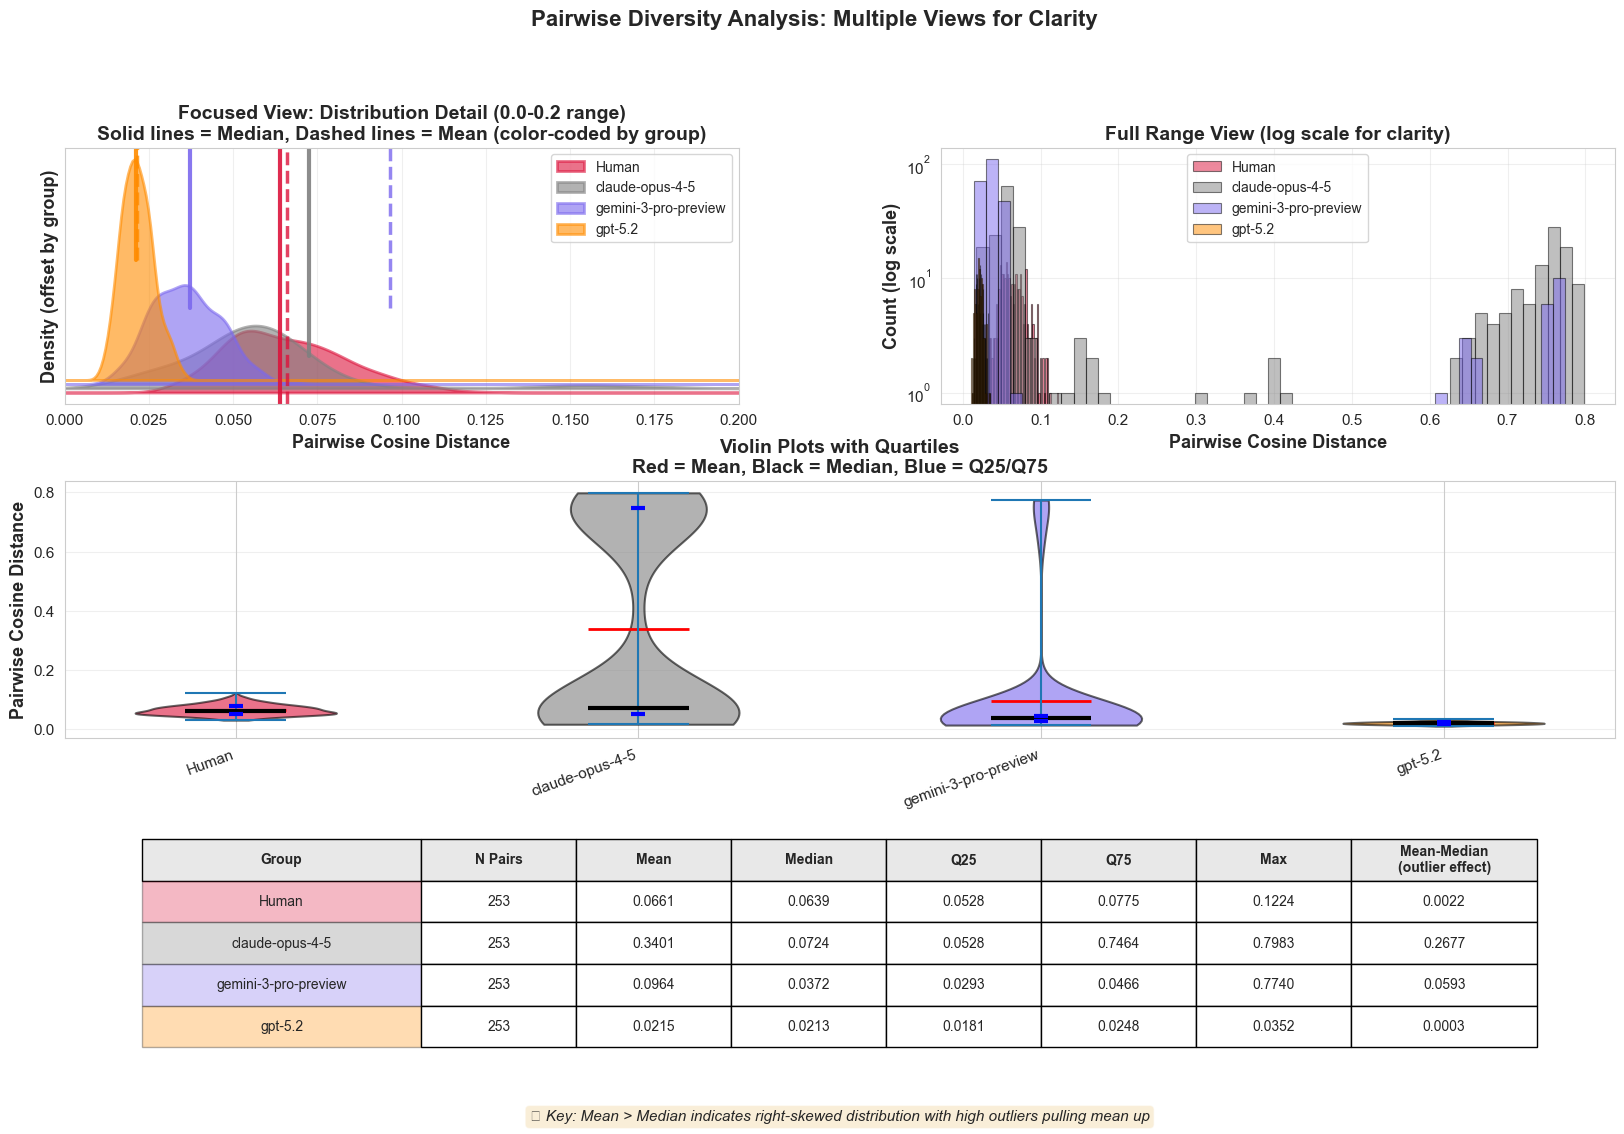

✓ Figure saved to: results/figures/pairwise_diversity_by_model.png

📊 Visualization improvements:
  1. Ridge plot with FOCUSED 0.0-0.2 range (where 90%+ of data is)
  2. Distinct colors: RED (Human - prominent!), Blue (Claude), Purple (Gemini), Orange (GPT)
  3. Log-scale histogram for full range context
  4. Violin plots with quartile markers
  5. Statistical summary table highlighting mean-median differences


In [15]:
# Visualization: Improved distribution comparison for all groups
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create a 2x2 grid for better readability
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-6': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

group_order = ['Human'] + [m for m in ai_models if len(model_pairwise[m]) > 0]

# PANEL 1 (Top Left): Ridge plot / Stacked distributions - FOCUSED VIEW (0.0-0.2)
ax1 = fig.add_subplot(gs[0, 0])
offset = 0
max_density = 0

for idx, group in enumerate(group_order):
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    # Only plot data in 0.0-0.2 range for clarity
    data_filtered = data[data <= 0.2]
    
    # Create density
    from scipy.stats import gaussian_kde
    if len(data_filtered) > 1:
        kde = gaussian_kde(data_filtered)
        x_range = np.linspace(0, 0.2, 300)
        density = kde(x_range)
        max_density = max(max_density, density.max())
        
        # Plot filled curve with offset
        ax1.fill_between(x_range, offset + density, offset, 
                         color=colors.get(group, 'gray'), alpha=0.6, 
                         edgecolor=colors.get(group, 'gray'), linewidth=2, label=group)
        
        # Add median line (solid, in group color)
        median_val = np.median(data)
        if median_val <= 0.2:
            ax1.axvline(median_val, ymin=offset/(len(group_order)*2), 
                       ymax=(offset + density.max())/(len(group_order)*2),
                       color=colors.get(group, 'gray'), linestyle='-', linewidth=3, alpha=0.9)
        
        # Add mean line (dashed, in group color)
        mean_val = data.mean()
        if mean_val <= 0.2:
            ax1.axvline(mean_val, ymin=offset/(len(group_order)*2), 
                       ymax=(offset + density.max())/(len(group_order)*2),
                       color=colors.get(group, 'gray'), linestyle='--', linewidth=2.5, alpha=0.8)
        
        offset += 1.5

ax1.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax1.set_ylabel('Density (offset by group)', fontsize=13, fontweight='bold')
ax1.set_title('Focused View: Distribution Detail (0.0-0.2 range)\nSolid lines = Median, Dashed lines = Mean (color-coded by group)', 
              fontsize=14, fontweight='bold')
ax1.set_xlim(0, 0.2)
ax1.set_yticks([])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3, axis='x')

# PANEL 2 (Top Right): Full range view with log scale on y-axis
ax2 = fig.add_subplot(gs[0, 1])
for group in group_order:
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    ax2.hist(data, bins=50, alpha=0.5, label=group, 
            color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)

ax2.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Full Range View (log scale for clarity)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# PANEL 3 (Middle): Violin plots with quartile annotations
ax3 = fig.add_subplot(gs[1, :])

box_data = []
for dist, label in [(human_pairwise, 'Human')] + [(model_pairwise[m], m) for m in ai_models if len(model_pairwise[m]) > 0]:
    for val in dist:
        box_data.append({'Distance': val, 'Group': label})

box_df = pd.DataFrame(box_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

# Create violin plot
parts = ax3.violinplot([box_df[box_df['Group']==g]['Distance'].values for g in group_order],
                       positions=range(len(group_order)),
                       showmeans=True, showmedians=True, showextrema=True)

# Color the violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Enhance median and mean lines
parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

# Add quartile markers
for idx, group in enumerate(group_order):
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    q25, q75 = np.percentile(data, [25, 75])
    ax3.scatter([idx, idx], [q25, q75], color='blue', s=100, zorder=3, marker='_', linewidths=3)

ax3.set_xticks(range(len(group_order)))
ax3.set_xticklabels(group_order, fontsize=11, rotation=20, ha='right')
ax3.set_ylabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax3.set_title('Violin Plots with Quartiles\nRed = Mean, Black = Median, Blue = Q25/Q75', 
              fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

# PANEL 4 (Bottom): Statistical summary table
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

# Create summary statistics
summary_data = []
for group in group_order:
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    summary_data.append([
        group,
        f"{len(data)}",
        f"{data.mean():.4f}",
        f"{np.median(data):.4f}",
        f"{np.percentile(data, 25):.4f}",
        f"{np.percentile(data, 75):.4f}",
        f"{data.max():.4f}",
        f"{data.mean() - np.median(data):.4f}"
    ])

# Create table
table = ax4.table(cellText=summary_data,
                 colLabels=['Group', 'N Pairs', 'Mean', 'Median', 'Q25', 'Q75', 'Max', 'Mean-Median\n(outlier effect)'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.18, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color code the header
for i in range(8):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

# Color code the groups
for i, group in enumerate(group_order):
    table[(i+1, 0)].set_facecolor(colors.get(group, 'gray'))
    table[(i+1, 0)].set_alpha(0.3)

ax4.text(0.5, -0.15, 
         '💡 Key: Mean > Median indicates right-skewed distribution with high outliers pulling mean up',
         ha='center', va='top', transform=ax4.transAxes, fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Pairwise Diversity Analysis: Multiple Views for Clarity', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('results/figures/baseline/pairwise_diversity_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/baseline/pairwise_diversity_by_model.png")
print("\n📊 Visualization improvements:")
print("  1. Ridge plot with FOCUSED 0.0-0.2 range (where 90%+ of data is)")
print("  2. Distinct colors: RED (Human - prominent!), Blue (Claude), Purple (Gemini), Orange (GPT)")
print("  3. Log-scale histogram for full range context")
print("  4. Violin plots with quartile markers")
print("  5. Statistical summary table highlighting mean-median differences")


---

## Analysis 1.2: Centroid Dispersion Metric

Measure how scattered proposals are from their group center.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [16]:
def compute_centroid_distances(embeddings):
    """
    Compute distances from each proposal to its group centroid.
    """
    # Compute centroid (mean embedding)
    centroid = embeddings.mean(axis=0, keepdims=True)
    
    # Compute cosine distances to centroid
    distances = cosine_distances(embeddings, centroid).flatten()
    
    return distances, centroid

# Compute centroid distances for all groups
print("="*85)
print("COMPUTING CENTROID DISPERSION FOR ALL GROUPS")
print("="*85)

# Overall groups
ai_centroid_dists, ai_centroid = compute_centroid_distances(ai_embeddings)
human_centroid_dists, human_centroid = compute_centroid_distances(human_embeddings)

# Individual AI models
model_centroid_dists = {}
model_centroids = {}

for model in ai_models:
    if len(model_embeddings_dict[model]) > 0:
        dists, centroid = compute_centroid_distances(model_embeddings_dict[model])
        model_centroid_dists[model] = dists
        model_centroids[model] = centroid

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10} {'Variance':<10}")
print("-"*90)

# Human baseline
print(f"{'Human':<35} {len(human_embeddings):<8} {human_centroid_dists.mean():<10.4f} {np.median(human_centroid_dists):<10.4f} {human_centroid_dists.std():<10.4f} {human_centroid_dists.var():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if model in model_centroid_dists:
        dists = model_centroid_dists[model]
        n_proposals = len(model_embeddings_dict[model])
        print(f"{model:<35} {n_proposals:<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.std():<10.4f} {dists.var():<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {ai_centroid_dists.mean():<10.4f} {np.median(ai_centroid_dists):<10.4f} {ai_centroid_dists.std():<10.4f} {ai_centroid_dists.var():<10.4f}")

print("="*90)
print("\n💡 INTERPRETATION:")
print("   - Higher variance = more dispersed proposals (higher diversity)")
print("   - Lower variance = proposals cluster tightly around center")
print("="*90)


COMPUTING CENTROID DISPERSION FOR ALL GROUPS

GROUP                               N        Mean       Median     Std        Variance  
------------------------------------------------------------------------------------------
Human                               23       0.0321     0.0294     0.0092     0.0001    

claude-opus-4-5                     23       0.1789     0.0736     0.1845     0.0340    
gemini-3-pro-preview                23       0.0473     0.0178     0.1348     0.0182    
gpt-5.2                             23       0.0104     0.0101     0.0023     0.0000    

All AI (combined)                   69       0.0894     0.0268     0.1836     0.0337    

💡 INTERPRETATION:
   - Higher variance = more dispersed proposals (higher diversity)
   - Lower variance = proposals cluster tightly around center


In [17]:
print("="*85)
print("STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in centroid distance (AI - Human).")

comparison_specs = [('All AI', ai_centroid_dists)] + [
    (model, model_centroid_dists[model])
    for model in ai_models
    if model in model_centroid_dists
]

centroid_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_centroid_dists, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    centroid_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE dispersed from center")
    else:
        print(f"  → Human proposals are MORE dispersed from center")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

centroid_df = pd.DataFrame(centroid_results)
centroid_df = apply_multiple_testing(centroid_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
centroid_comparison_results = centroid_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Centroid Dispersion with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in centroid_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more dispersed; Negative = Human more dispersed")


STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)
Primary estimand: mean difference in centroid distance (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 657, p-value: 2.2008e-01
Cliff's Delta:
  δ = -0.1720 (small effect)
  → Human proposals are MORE dispersed from center
Primary mean difference (AI - Human):
  Observed difference: 0.0573
  Bootstrap 95% CI: [0.0159, 0.1029]
  Permutation p-value: 0.1912

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 527, p-value: 8.6168e-09
Cliff's Delta:
  δ = 0.9924 (large effect)
  → claude-opus-4-5 proposals are MORE dispersed from center
Pri

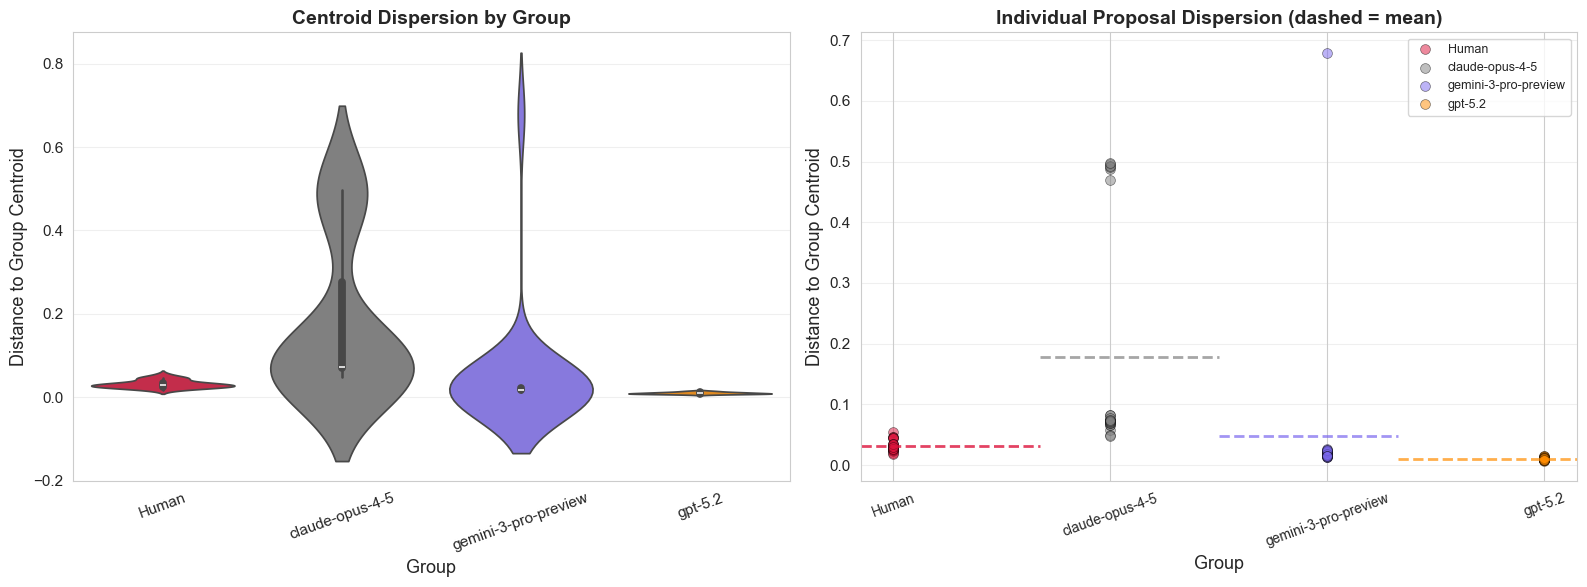

✓ Figure saved to: results/figures/centroid_dispersion_by_model.png


In [18]:
# Visualization: Centroid dispersion for all groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



# LEFT PANEL: Violin plots
violin_data = []
for dist, label in [(human_centroid_dists, 'Human')] + [(model_centroid_dists[m], m) for m in ai_models if m in model_centroid_dists]:
    for val in dist:
        violin_data.append({'Distance to Centroid': val, 'Group': label})

violin_df = pd.DataFrame(violin_data)
group_order = ['Human'] + [m for m in ai_models if m in model_centroid_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=violin_df, x='Group', y='Distance to Centroid', ax=axes[0], palette=palette_list, order=group_order)
axes[0].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[0].set_xlabel('Group', fontsize=13)
axes[0].set_title('Centroid Dispersion by Group', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

# RIGHT PANEL: Scatter plot showing individual proposals
offset = 0
x_positions = {}

# Human
x_positions['Human'] = 0
axes[1].scatter([0]*len(human_centroid_dists), human_centroid_dists, 
               alpha=0.5, label='Human', color=colors['Human'], s=50, edgecolors='black', linewidth=0.5)
axes[1].axhline(human_centroid_dists.mean(), xmin=0/len(group_order), xmax=1/len(group_order), 
               color=colors['Human'], linestyle='--', linewidth=2, alpha=0.8)

offset = 1
# Individual AI models
for i, model in enumerate([m for m in ai_models if m in model_centroid_dists]):
    x_positions[model] = offset
    axes[1].scatter([offset]*len(model_centroid_dists[model]), model_centroid_dists[model], 
                   alpha=0.5, label=model, color=colors.get(model, 'gray'), s=50, edgecolors='black', linewidth=0.5)
    axes[1].axhline(model_centroid_dists[model].mean(), 
                   xmin=offset/len(group_order), xmax=(offset+1)/len(group_order),
                   color=colors.get(model, 'gray'), linestyle='--', linewidth=2, alpha=0.7)
    offset += 1

axes[1].set_xticks(range(len(group_order)))
axes[1].set_xticklabels(group_order, rotation=20, fontsize=10)
axes[1].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[1].set_xlabel('Group', fontsize=13)
axes[1].set_title('Individual Proposal Dispersion (dashed = mean)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/figures/baseline/centroid_dispersion_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/baseline/centroid_dispersion_by_model.png")


---

## Analysis 1.3: Nearest-Neighbor Outlier Detection (Between Group)

Identify "lone wolf" ideas far from everything else.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [19]:
# Combine all embeddings for global nearest-neighbor analysis
all_embeddings = np.vstack([human_embeddings, ai_embeddings])
n_human = len(human_embeddings)
n_ai = len(ai_embeddings)

# Build per-row labels aligned to embedding order (avoid assuming contiguous blocks by model)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = [m for m in sorted(list(dict.fromkeys(ai_model_labels))) if m is not None]

# Compute full distance matrix
print("="*85)
print("COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
print("="*85)

all_distances = cosine_distances(all_embeddings)
np.fill_diagonal(all_distances, np.inf)
nn_distances = all_distances.min(axis=1)

# Split by group
human_nn_dists = nn_distances[labels == 'Human']
ai_nn_dists = nn_distances[labels != 'Human']

# Extract per-model NN distances using label masks
model_nn_dists = {m: nn_distances[labels == m] for m in ai_models_local}

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

print(f"{'Human':<35} {len(human_nn_dists):<8} {human_nn_dists.mean():<10.4f} {np.median(human_nn_dists):<10.4f} {human_nn_dists.min():<10.4f} {human_nn_dists.max():<10.4f}")
print()

for model in ai_models_local:
    dists = model_nn_dists[model]
    print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")

print()
print(f"{'All AI (combined)':<35} {len(ai_nn_dists):<8} {ai_nn_dists.mean():<10.4f} {np.median(ai_nn_dists):<10.4f} {ai_nn_dists.min():<10.4f} {ai_nn_dists.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher mean NN distance = more isolated proposals (outliers)")
print("   - Lower mean NN distance = proposals cluster together")
print("="*85)


COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.0372     0.0349     0.0236     0.0646    

claude-opus-4-5                     23       0.0563     0.0392     0.0144     0.3112    
gemini-3-pro-preview                23       0.0313     0.0230     0.0148     0.2322    
gpt-5.2                             23       0.0139     0.0138     0.0111     0.0191    

All AI (combined)                   69       0.0339     0.0191     0.0111     0.3112    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together


In [20]:
# Identify outliers (top 10% of NN distances)
threshold = np.percentile(nn_distances, 90)
outliers = nn_distances > threshold

human_outliers = int(outliers[labels == 'Human'].sum())
ai_outliers = int(outliers[labels != 'Human'].sum())

# Per-model outlier detection (do NOT slice by contiguous blocks)
model_outliers = {m: int(outliers[labels == m].sum()) for m in ai_models_local}

print("\n" + "="*85)
print("OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)")
print("="*85)
print(f"Threshold distance: {threshold:.4f}")
print()

print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
print("-"*85)

print(f"{'Human':<35} {human_outliers:<15} {n_human:<10} {human_outliers/n_human*100:<15.1f}%")
print()

for model in ai_models_local:
    n_model = int((labels == model).sum())
    print(f"{model:<35} {model_outliers[model]:<15} {n_model:<10} {model_outliers[model]/n_model*100:<15.1f}%")

print()
print(f"{'All AI (combined)':<35} {ai_outliers:<15} {n_ai:<10} {ai_outliers/n_ai*100:<15.1f}%")

print("="*85)



OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)
Threshold distance: 0.0488

GROUP                               Outliers        Total      Percentage     
-------------------------------------------------------------------------------------
Human                               3               23         13.0           %

claude-opus-4-5                     6               23         26.1           %
gemini-3-pro-preview                1               23         4.3            %
gpt-5.2                             0               23         0.0            %

All AI (combined)                   7               69         10.1           %


In [21]:
# Find nearest neighbor's group for each proposal
nn_indices = all_distances.argmin(axis=1)
nn_labels = labels[nn_indices]

# Determine if NN is from same or different group
human_nn_same_group = int((nn_labels[labels == 'Human'] == 'Human').sum())
human_nn_diff_group = int(n_human - human_nn_same_group)

ai_nn_same_group = int((nn_labels[labels != 'Human'] != 'Human').sum())
ai_nn_diff_group = int(n_ai - ai_nn_same_group)

# Per-model nearest neighbor group analysis (mask-based)
model_nn_analysis = {}
for model in ai_models_local:
    mask = labels == model
    total = int(mask.sum())
    nn_from_human = int((nn_labels[mask] == 'Human').sum())
    nn_from_same_model = int((nn_labels[mask] == model).sum())
    nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)

    model_nn_analysis[model] = {
        'from_human': nn_from_human,
        'from_same_model': nn_from_same_model,
        'from_other_ai': nn_from_other_ai,
        'total': total
    }

print("\n" + "="*85)
print("NEAREST NEIGHBOR GROUP ANALYSIS")
print("="*85)

print(f"\n{'Human proposals:':<50}")
print(f"  NN from same group (human): {human_nn_same_group} ({human_nn_same_group/n_human*100:.1f}%)")
print(f"  NN from different group (AI): {human_nn_diff_group} ({human_nn_diff_group/n_human*100:.1f}%)")

print(f"\n{'All AI proposals (combined):':<50}")
print(f"  NN from same group (AI): {ai_nn_same_group} ({ai_nn_same_group/n_ai*100:.1f}%)")
print(f"  NN from different group (human): {ai_nn_diff_group} ({ai_nn_diff_group/n_ai*100:.1f}%)")

print("\n" + "-"*85)
print("Per-Model NN Group Breakdown:")
print("-"*85)

for model in ai_models_local:
    data = model_nn_analysis[model]
    print(f"\n{model}:")
    print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
    print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
    print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

print("\n" + "="*85)
print("\n💡 INTERPRETATION:")
print("   - High 'NN from same model' = model produces similar proposals")
print("   - High 'NN from Human' = model proposals resemble human work")
print("="*85)



NEAREST NEIGHBOR GROUP ANALYSIS

Human proposals:                                  
  NN from same group (human): 10 (43.5%)
  NN from different group (AI): 13 (56.5%)

All AI proposals (combined):                      
  NN from same group (AI): 69 (100.0%)
  NN from different group (human): 0 (0.0%)

-------------------------------------------------------------------------------------
Per-Model NN Group Breakdown:
-------------------------------------------------------------------------------------

claude-opus-4-5:
  NN from Human: 0 (0.0%)
  NN from same model: 16 (69.6%)
  NN from other AI models: 7 (30.4%)

gemini-3-pro-preview:
  NN from Human: 0 (0.0%)
  NN from same model: 16 (69.6%)
  NN from other AI models: 7 (30.4%)

gpt-5.2:
  NN from Human: 0 (0.0%)
  NN from same model: 22 (95.7%)
  NN from other AI models: 1 (4.3%)


💡 INTERPRETATION:
   - High 'NN from same model' = model produces similar proposals
   - High 'NN from Human' = model proposals resemble human work


In [22]:
print("="*85)
print("STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in NN distance (AI - Human).")

comparison_specs = [('All AI', ai_nn_dists)] + [
    (model, model_nn_dists[model])
    for model in ai_models
    if model in model_nn_dists
]

nn_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_nn_dists, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    nn_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals have MORE unique/outlier ideas")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

nn_df = pd.DataFrame(nn_results)
nn_df = apply_multiple_testing(nn_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
nn_comparison_results = nn_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Nearest-Neighbor Distances with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in nn_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more outlier-prone; Negative = Human more outlier-prone")


STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)
Primary estimand: mean difference in NN distance (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 344, p-value: 5.1476e-05
Cliff's Delta:
  δ = -0.5665 (large effect)
  → Human proposals have MORE unique/outlier ideas
Primary mean difference (AI - Human):
  Observed difference: -0.0033
  Bootstrap 95% CI: [-0.0140, 0.0096]
  Permutation p-value: 0.8141

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 280, p-value: 7.4170e-01
Cliff's Delta:
  δ = 0.0586 (negligible effect)
  → claude-opus-4-5 proposals have MORE unique/outlier i

In [23]:
import numpy as np
import pandas as pd

print("\n" + "="*85)
print("UNADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers', 'threshold', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the unadjusted NN + outlier detection cells first.")
else:
    outlier_indices = np.where(outliers)[0]
    n_total = int(len(outliers))
    n_ai = int(n_total - n_human)

    # NN distances (unadjusted)
    nn_d = np.asarray(nn_distances) if 'nn_distances' in globals() else None

    # Prefer metadata saved alongside embeddings (aligned with embedding order)
    use_meta = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_meta:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df lookup.")
            use_meta = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_meta:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = int(idx - n_human)
            who = 'AI'
            if use_meta:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', 'AI')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



UNADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.0488
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
claude-opus-4-5         6
Human                   3
gemini-3-pro-preview    1


,global_index,who,model,nn_distance,title
0,89,AI,claude-opus-4-5,0.311175,Emergent Mechanics of Bacterial Microcompartments: Synthesizing Structural and Metabolic Data to Model Encapsulated Pathway Efficiency
1,48,AI,gemini-3-pro-preview,0.232178,The Emergence of Metabolic Channeling: Mapping Transient Metabolons via Integrated Interactomics
2,90,AI,claude-opus-4-5,0.113226,Emergent Receptor Clustering in Immune Synapses: Synthesizing Super-Resolution and Signaling Data to Model T Cell Activation Thresholds
3,85,AI,claude-opus-4-5,0.092681,Emergent Prion Strain Properties: Synthesizing Cryo-EM Structures with Clinical Data to Model How Fibril Architecture Determines Pathology
4,91,AI,claude-opus-4-5,0.092681,Emergent DNA Repair Pathway Choice: Synthesizing Damage Proteomics and Chromatin Data to Model Repair Mechanism Selection
5,82,AI,claude-opus-4-5,0.080993,"Emergent Cooperativity in Transcription Factor Clusters: Synthesizing ChIP-seq, Structural, and Imaging Data to Model Enhancer Activation"
6,86,AI,claude-opus-4-5,0.080993,Emergent Cell Polarity from Protein Localization Networks: Synthesizing Imaging and Interactome Data to Model Symmetry Breaking
7,0,Human,Human,0.064560,CYTOKINETIC BOTTLENECKS OF HEAT WAVES
8,3,Human,Human,0.053078,Synthesizing gene expression data to create an atlas of bacterial cell states
9,16,Human,Human,0.048998,Integrative Multi-Omics Synthesis to Identify Shared Molecular Mechanisms of Mammalian Hibernation


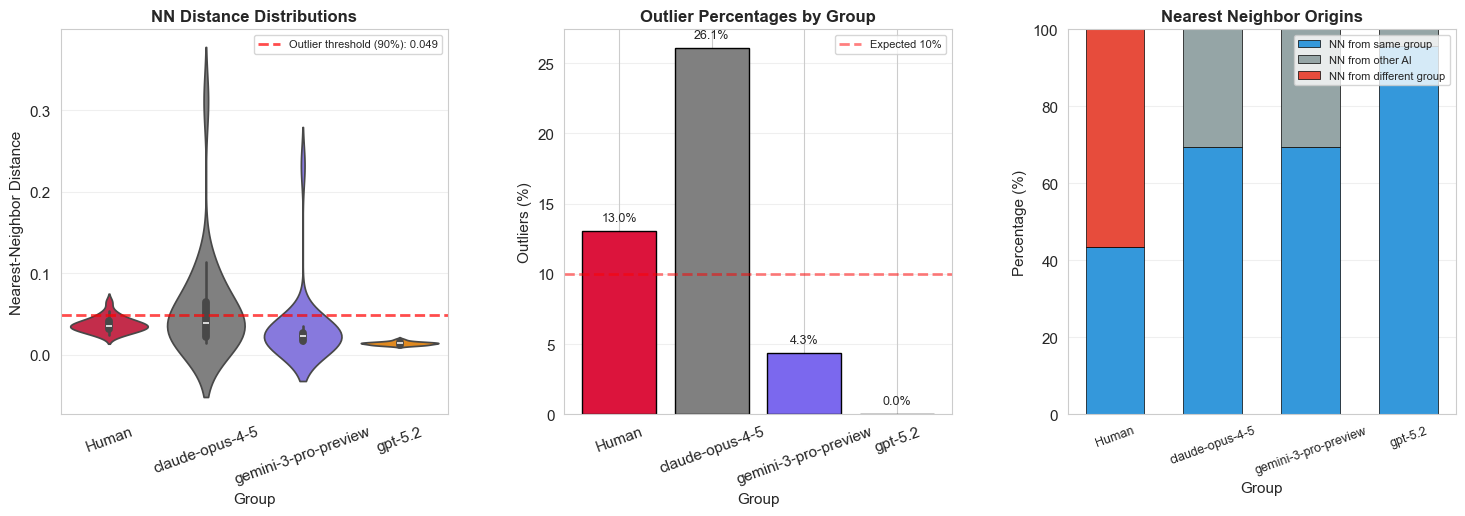

✓ Figure saved to: results/figures/nearest_neighbor_by_model.png


In [24]:
# Visualization: Nearest-neighbor analysis by group
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# # Color scheme
# colors = {
#     'Human': 'steelblue',
#     'claude-opus-4-6': '#E74C3C',
#     'gemini-3-pro-preview': '#9B59B6',
#     'gpt-5.2': '#F39C12',
#     'All AI': 'coral'
# }

# 1. NN distance distributions by group
ax1 = fig.add_subplot(gs[0, 0])
nn_data = []
for dist, label in [(human_nn_dists, 'Human')] + [(model_nn_dists[m], m) for m in ai_models if m in model_nn_dists]:
    for val in dist:
        nn_data.append({'NN Distance': val, 'Group': label})

nn_df = pd.DataFrame(nn_data)
group_order = ['Human'] + [m for m in ai_models if m in model_nn_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order)
ax1.axhline(threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold:.3f}')
ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
ax1.set_xlabel('Group', fontsize=11)
ax1.set_title('NN Distance Distributions', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# 2. Outlier counts by group
ax2 = fig.add_subplot(gs[0, 1])
outlier_data = []
outlier_data.append({'Group': 'Human', 'Outliers': human_outliers, 'Total': n_human, 'Percentage': human_outliers/n_human*100})

for model in ai_models:
    if model in model_outliers:
        n_model = len(model_embeddings_dict[model])
        outlier_data.append({
            'Group': model,
            'Outliers': model_outliers[model],
            'Total': n_model,
            'Percentage': model_outliers[model]/n_model*100
        })

outlier_df = pd.DataFrame(outlier_data)
bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors.get(g, 'gray') for g in outlier_df['Group']], 
               edgecolor='black', linewidth=1)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
ax2.set_ylabel('Outliers (%)', fontsize=11)
ax2.set_xlabel('Group', fontsize=11)
ax2.set_title('Outlier Percentages by Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, outlier_df['Percentage'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. NN Group Analysis - Stacked bar chart
ax3 = fig.add_subplot(gs[0, 2])

# Prepare data for stacked bars
groups = ['Human'] + [m for m in ai_models if m in model_nn_analysis]
nn_from_human_pcts = [human_nn_diff_group/n_human*100]  # For human, this is NN from AI
nn_from_same_pcts = [human_nn_same_group/n_human*100]  # For human, this is NN from human
nn_from_other_ai_pcts = [0]  # Human doesn't have this category

for model in [m for m in ai_models if m in model_nn_analysis]:
    data = model_nn_analysis[model]
    nn_from_human_pcts.append(data['from_human']/data['total']*100)
    nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
    nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

x_pos = np.arange(len(groups))
width = 0.6

# Adjust labels for Human
p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_xlabel('Group', fontsize=11)
ax3.set_title('Nearest Neighbor Origins', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(groups, rotation=20, fontsize=9)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('results/figures/baseline/nearest_neighbor_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/baseline/nearest_neighbor_by_model.png")


### The Key Insight: Location vs. Distance

NN Group Analysis (Which group is closest):
Tells us WHERE proposals are in semantic space
0% of GPT have human NN → GPT proposals are in "AI territory"
Outlier Detection (How far from nearest neighbor):
Tells us HOW ISOLATED proposals are
26.1% of GPT are outliers → Some GPT proposals are very FAR from everything
These Are Compatible! 


What's happening:
Most GPT proposals (74%) cluster together in AI region
Some GPT proposals (26%) are VERY far from this cluster
BUT even these outliers are still closer to other AI than to humans
The outliers are "weird AI proposals" not "human-like proposals"
The Numbers Tell the Story:
Outlier threshold: 0.0488
This is the NN distance that defines top 10% most isolated proposals
GPT has 6 proposals with NN distance > 0.0488
BUT:

These 6 GPT outliers, despite being far from everything...
Are STILL closer to some AI proposal than to any human
The distance to nearest AI < distance to nearest human

What This Reveals About Each Model:

Claude (0% outliers, 95.7% same-model NN):
Highly consistent
All proposals tightly clustered
Strong model signature
"Conservative diversity"

Gemini (4.3% outliers, 69.6% same-model NN):
Moderately consistent
Mostly similar, few outliers
Some cross-model similarity with GPT
"Controlled diversity"

GPT-5.2 (26.1% outliers, 69.6% same-model NN):
Inconsistent/erratic
Produces both clustered AND isolated proposals
High variance in output
"Chaotic diversity"

Human (13.0% outliers, 43.5% same-group NN):
Naturally dispersed
Moderate outlier rate
Most diverse pattern: nearest neighbors include both human AND AI
"Authentic diversity"

### The Critical Distinction:
AI Outliers ≠ Human-like
GPT's outliers are:
✅ Far from other GPT proposals
✅ Far from other AI proposals
✅ Still in "AI semantic territory"
❌ NOT close to human proposals

This means GPT occasionally generates strange/unusual AI-style proposals, not human-like proposals.

### Why This Matters:
GPT-5.2's high outlier rate reveals:
Lower reliability - output is less predictable
Not escaping AI patterns - outliers still have AI characteristics
Different kind of diversity - variance within constraints, not breaking free
Contrast with Human:
Lower outlier rate (13% vs 26%)
But 56.5% of humans are closer to AI than to other humans
Humans span semantic space, not cluster with outliers
More natural variation, less extreme deviations
Reconciled Interpretation:
Both results together tell us:

GPT-5.2:
"I'll give you 23 proposals"
"17 will be very similar to each other"
"6 will be weird and different"
"But they'll ALL sound like AI proposals"

Humans:
"We'll each write our own proposal"
"Some will be somewhat similar"
"Some will be quite different"
"They'll be scattered across possibility space"
"A few might accidentally resemble AI patterns"

Bottom Line:
The results perfectly align: GPT has the most outliers (erratic), but even its outliers stay in AI semantic space (constrained). This is variance without true diversity - like a jazz musician who sometimes plays way off-key, but never leaves the jazz genre! 🎷

### Embedding Space Visualization

Visualize all proposals in 2D space using UMAP dimensionality reduction to see:
- **Clustering patterns**: How proposals group together
- **Outliers**: Unique proposals far from others (highlighted in magenta)
- **Group separation**: How Human vs AI proposals distribute in semantic space
- **Model characteristics**: Whether different AI models produce distinctly clustered proposals

**Color coding**: Human proposals in bright red for easy identification, AI models in muted colors.


VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE

Reducing embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


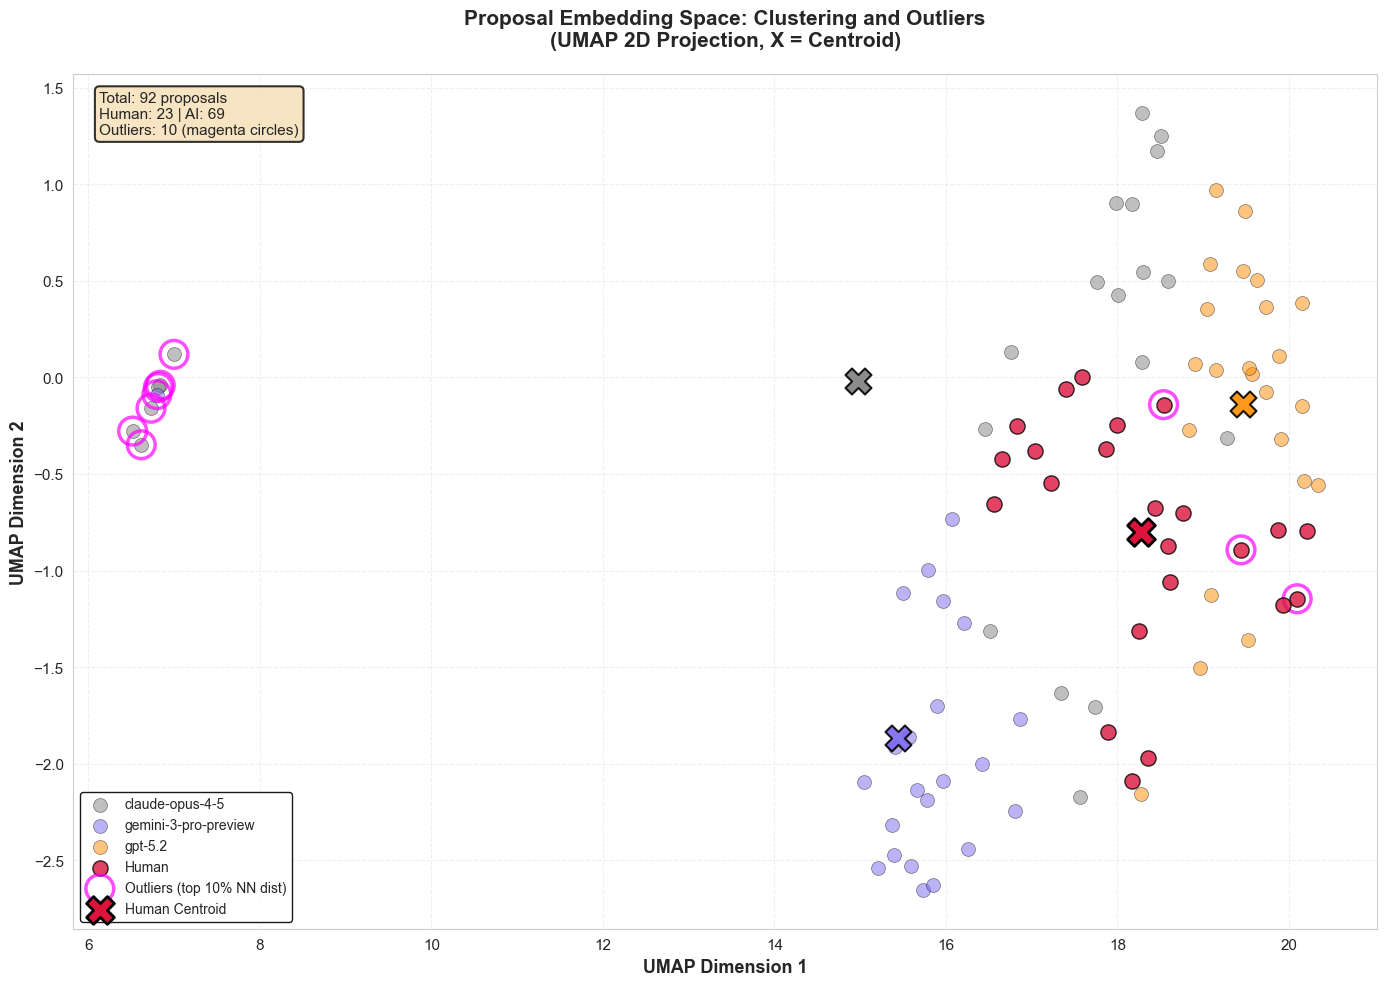


✓ Figure saved to: results/figures/embedding_space_2d.png

💡 INTERPRETATION:
   - Clusters = similar proposals
   - Outliers (magenta circles) = unique/distant proposals
   - X markers = group centroids
   - Distance between groups shows overall similarity


In [25]:


print("\n" + "="*85)
print("VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE")
print("="*85)

# Apply UMAP dimensionality reduction
print("\nReducing embeddings to 2D using UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# Combine all embeddings for UMAP
all_embeddings_umap = np.vstack([human_embeddings, ai_embeddings])
embeddings_2d = reducer.fit_transform(all_embeddings_umap)

# Split back into groups
human_2d = embeddings_2d[:n_human]
ai_2d = embeddings_2d[n_human:]

# Build labels aligned to embedding order (avoid assuming contiguous model blocks)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_umap = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

print(f"✓ UMAP completed: {len(embeddings_2d)} proposals reduced to 2D")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot AI models first (so human is on top) — mask-based by label
for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        pts = embeddings_2d[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Plot human proposals on top (bright red)
ax.scatter(human_2d[:, 0], human_2d[:, 1],
          c=colors['Human'],
          label='Human',
          s=120,
          alpha=0.8,
          edgecolors='black',
          linewidth=1.0,
          marker='o',
          zorder=10)  # Ensure human points are on top

# Highlight outliers with a circle
outlier_indices = np.where(outliers)[0]
outlier_coords = embeddings_2d[outlier_indices]

ax.scatter(outlier_coords[:, 0], outlier_coords[:, 1],
          s=400,
          facecolors='none',
          edgecolors='magenta',
          linewidth=2.5,
          alpha=0.7,
          label=f'Outliers (top 10% NN dist)',
          zorder=5)

# Calculate and plot centroids for each group
human_centroid_2d = human_2d.mean(axis=0)
ax.scatter(human_centroid_2d[0], human_centroid_2d[1],
          c=colors['Human'],
          s=400,
          marker='X',
          edgecolors='black',
          linewidth=2,
          alpha=1.0,
          zorder=15,
          label='Human Centroid')

for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        model_centroid_2d = embeddings_2d[mask].mean(axis=0)
        ax.scatter(model_centroid_2d[0], model_centroid_2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=12)

# Labels and formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Proposal Embedding Space: Clustering and Outliers\n(UMAP 2D Projection, X = Centroid)',
            fontsize=15, fontweight='bold', pad=20)

# Legend
ax.legend(loc='best', fontsize=10, framealpha=0.9, edgecolor='black')

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text annotation with key insights
textstr = f'Total: {len(embeddings_2d)} proposals\n'
textstr += f'Human: {n_human} | AI: {n_ai}\n'
textstr += f'Outliers: {len(outlier_indices)} (magenta circles)'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('results/figures/baseline/embedding_space_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/baseline/embedding_space_2d.png")
print("\n💡 INTERPRETATION:")
print("   - Clusters = similar proposals")
print("   - Outliers (magenta circles) = unique/distant proposals")
print("   - X markers = group centroids")
print("   - Distance between groups shows overall similarity")
print("="*85)



ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)

Reducing embeddings to 2D using t-SNE...
(This may take a minute...)


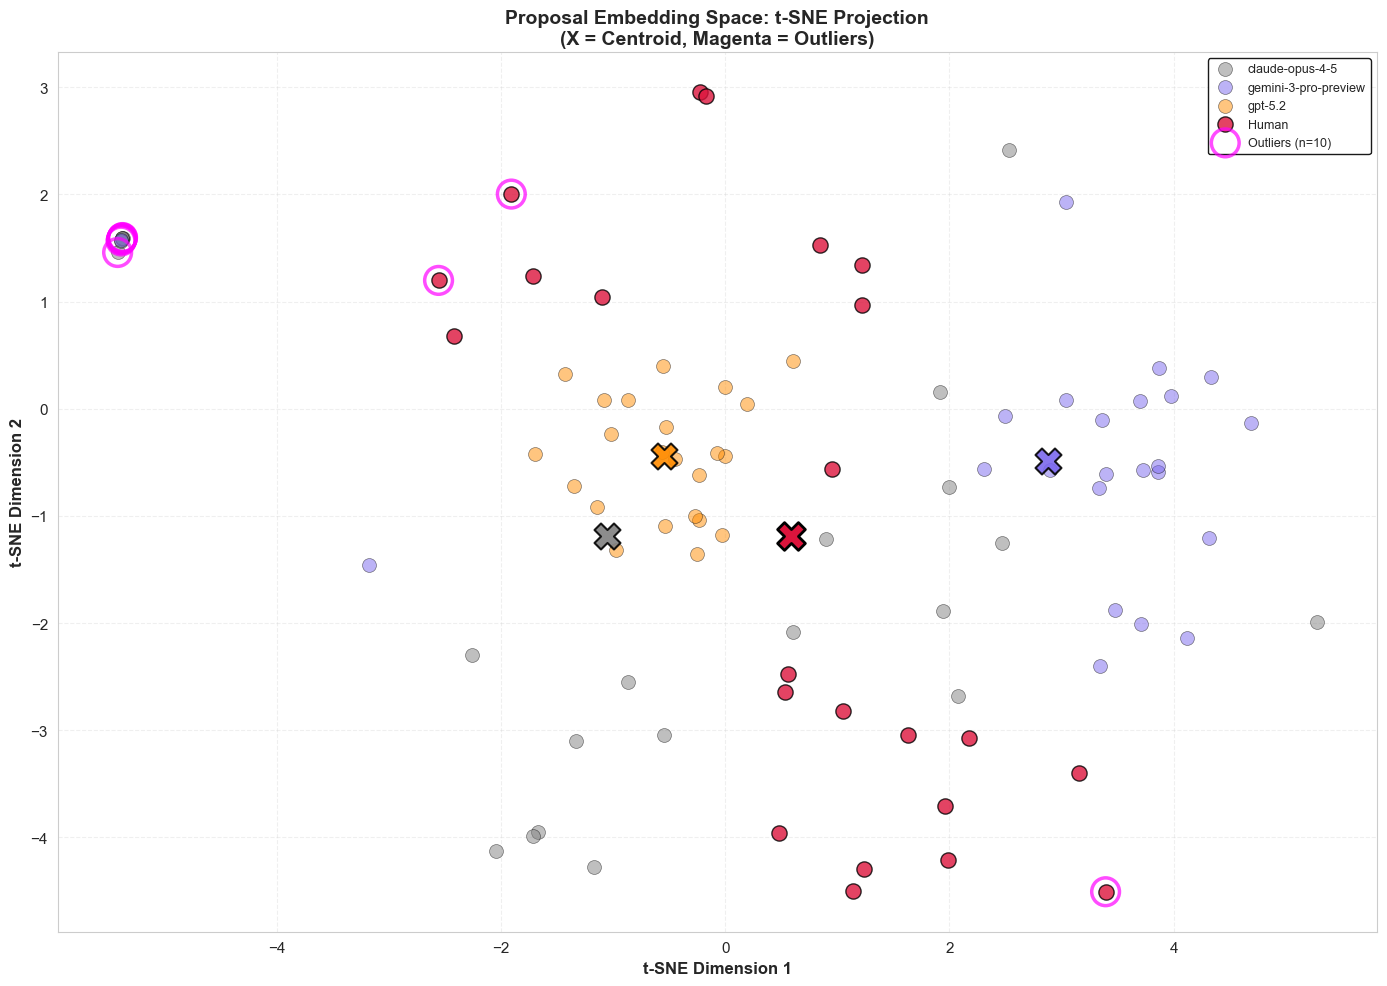


✓ Figure saved to: results/figures/embedding_space_tsne.png


In [26]:
# Alternative visualization: t-SNE (complementary to UMAP)
from sklearn.manifold import TSNE

print("\n" + "="*85)
print("ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)")
print("="*85)

# Build labels aligned to embedding order (same approach as UMAP cell)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_tsne = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

# Apply t-SNE dimensionality reduction
print("\nReducing embeddings to 2D using t-SNE...")
print("(This may take a minute...)")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0
)

embeddings_2d_tsne = tsne.fit_transform(all_embeddings_umap)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        pts = embeddings_2d_tsne[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Human
mask_h = labels_tsne == 'Human'
pts_h = embeddings_2d_tsne[mask_h]
ax.scatter(pts_h[:, 0], pts_h[:, 1],
           c=colors['Human'],
           label='Human',
           s=120,
           alpha=0.8,
           edgecolors='black',
           linewidth=1.0,
           marker='o',
           zorder=10)

# Highlight the same outliers (computed from NN distances)
outlier_indices = np.where(outliers)[0]
outlier_coords_plot = embeddings_2d_tsne[outlier_indices]
ax.scatter(outlier_coords_plot[:, 0], outlier_coords_plot[:, 1],
           s=400,
           facecolors='none',
           edgecolors='magenta',
           linewidth=2.5,
           alpha=0.7,
           label=f'Outliers (n={len(outlier_indices)})',
           zorder=12)

# Centroids
centroid_h = pts_h.mean(axis=0)
ax.scatter(centroid_h[0], centroid_h[1],
           c=colors['Human'],
           s=400,
           marker='X',
           edgecolors='black',
           linewidth=2,
           alpha=1.0,
           zorder=15)

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        c2d = embeddings_2d_tsne[mask].mean(axis=0)
        ax.scatter(c2d[0], c2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=14)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposal Embedding Space: t-SNE Projection\n(X = Centroid, Magenta = Outliers)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path = 'results/figures/baseline/embedding_space_tsne.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to: {out_path}")
print("="*85)


---

# PART II: NOVELTY

Can AI create more novel proposals than teams of human scientists?

We'll compare how far proposals are from existing literature (PubMed corpus).

## Step 1: Load Literature Corpus

Load the 350 PubMed abstracts from `data/literature/call-relevant-corpus.json`.

In [27]:
import json

# Load literature corpus
print("="*85)
print("LOADING LITERATURE CORPUS")
print("="*85)

with open('data/literature/call-relevant-corpus.json', 'r') as f:
    corpus_data = json.load(f)

articles = corpus_data['articles']
print(f"\n✓ Loaded {len(articles)} PubMed articles")
print(f"  Search queries: {len(corpus_data['search_queries'])}")

# Extract title and abstract for each article
corpus_texts = []
for article in articles:
    title = article.get('title', '')
    abstract = article.get('abstract', '')
    # Combine title and abstract (same format as we'll use for proposals)
    text = f"Title: {title}\n\nAbstract: {abstract}"
    corpus_texts.append(text)

print(f"\n✓ Prepared {len(corpus_texts)} literature texts")
print(f"  Average length: {np.mean([len(t) for t in corpus_texts]):.0f} characters")
print("="*85)


LOADING LITERATURE CORPUS

✓ Loaded 600 PubMed articles
  Search queries: 14

✓ Prepared 600 literature texts
  Average length: 1312 characters


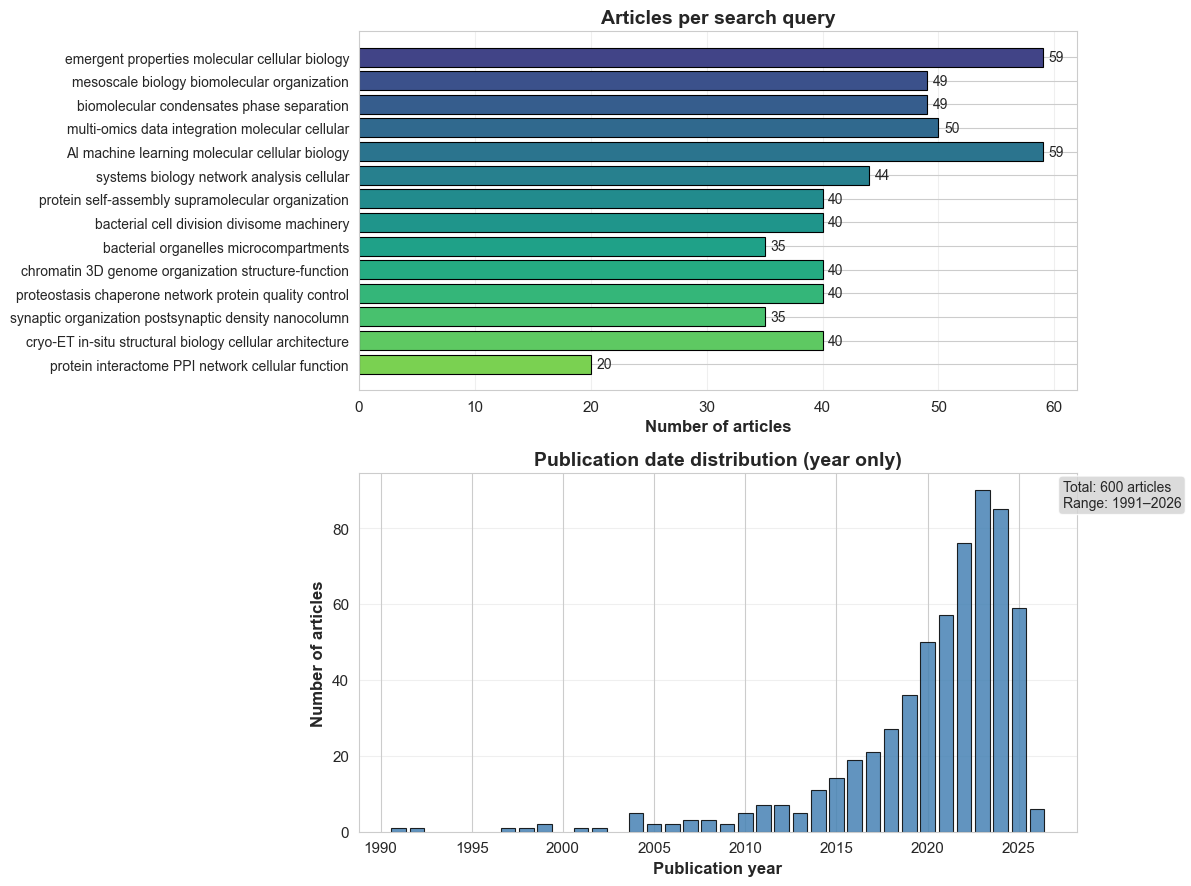

✓ Figure saved to: results/figures/literature_corpus_overview.png

SEARCH TERMS (QUERIES) USED PER CATEGORY

• emergent properties molecular cellular biology (n=59 articles):
  ("emergent properties" OR "emergence") AND ("molecular biology" OR "cellular biology" OR "cell biology")

• mesoscale biology biomolecular organization (n=49 articles):
  ("mesoscale" OR "mesoscopic") AND ("protein" OR "biomolecular" OR "cellular" OR "organelle")

• biomolecular condensates phase separation (n=49 articles):
  ("biomolecular condensates" OR "phase separation") AND ("cell biology" OR "molecular biology")

• multi-omics data integration molecular cellular (n=50 articles):
  ("multi-omics" OR "multiomics" OR "integrative omics") AND ("data integration" OR "data synthesis") AND ("molecular" OR "cellular")

• AI machine learning molecular cellular biology (n=59 articles):
  ("machine learning" OR "artificial intelligence" OR "deep learning") AND ("molecular biology" OR "cell biology" OR "proteomics" O

In [28]:
# Visualize literature corpus: articles per query + publication year distribution
import re

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- Panel 1: Articles per search query ---
ax1 = axes[0]
queries = corpus_data['search_queries']
labels = [q['label'] for q in queries]
counts = [q['new_unique_added'] for q in queries]
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(labels)))
bars = ax1.barh(range(len(labels)), counts, color=colors_bar, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=10, ha='right')
ax1.set_xlabel('Number of articles', fontsize=12, fontweight='bold')
ax1.set_title('Articles per search query', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for bar, c in zip(bars, counts):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(c), va='center', fontsize='10')

# --- Panel 2: Publication year distribution ---
ax2 = axes[1]
def parse_year(pub_date):
    if not pub_date or not isinstance(pub_date, str):
        return None
    m = re.match(r'(\d{4})', pub_date.strip())
    return int(m.group(1)) if m else None

years = [parse_year(a.get('publication_date')) for a in articles]
years = [y for y in years if y is not None]
year_counts = pd.Series(years).value_counts().sort_index()

ax2.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_xlabel('Publication year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of articles', fontsize=12, fontweight='bold')
ax2.set_title('Publication date distribution (year only)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
if years:
    ax2.text(0.98, 0.98, f'Total: {len(years)} articles\nRange: {min(years)}–{max(years)}', transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig('results/figures/baseline/literature_corpus_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figure saved to: results/figures/baseline/literature_corpus_overview.png')

# Print search terms (queries) used for each category
print('\n' + '='*85)
print('SEARCH TERMS (QUERIES) USED PER CATEGORY')
print('='*85)
for q in queries:
    print(f"\n• {q['label']} (n={q['new_unique_added']} articles):")
    print(f"  {q['query']}")
print('='*85)


## Step 2: Embed Literature Corpus 

Embed all 350 abstracts using BioLinkBERT-Large (same model used for proposals).

In [29]:
# Embed literature corpus using the same chunking approach
print("="*85)
print("EMBEDDING LITERATURE CORPUS")
print("="*85)
print("Using BioLinkBERT-Large with chunking (same as proposals)")
print()

# Check if embeddings already exist
literature_embeddings_file = Path('data/embeddings/literature/relevant_literature_embeddings.pkl')
literature_embeddings_file.parent.mkdir(parents=True, exist_ok=True)

if literature_embeddings_file.exists():
    print(f"✓ Loading cached literature embeddings from {literature_embeddings_file}")
    with open(literature_embeddings_file, 'rb') as f:
        literature_data = pickle.load(f)
        literature_embeddings = literature_data['embeddings']
    print(f"✓ Loaded {len(literature_embeddings)} embeddings")
else:
    print("Embedding literature corpus (this will take a few minutes)...")
    literature_embeddings = get_embeddings_with_chunking(corpus_texts)
    print(f"✓ Literature embeddings shape: {literature_embeddings.shape}")
    
    # Cache for future use
    with open(literature_embeddings_file, 'wb') as f:
        pickle.dump({
            'embeddings': literature_embeddings,
            'model_name': model_name,
            'timestamp': datetime.now().isoformat()
        }, f)
    print(f"✓ Cached embeddings to: {literature_embeddings_file}")

print("="*85)


EMBEDDING LITERATURE CORPUS
Using BioLinkBERT-Large with chunking (same as proposals)

✓ Loading cached literature embeddings from data/embeddings/literature/relevant_literature_embeddings.pkl
✓ Loaded 600 embeddings


## Step 3: Re-embed Proposals (Title + Abstract Only)

For fair comparison with literature (which only has abstracts), re-embed proposals using only title and abstract.

In [30]:
# Re-embed proposals using only title + abstract (for fair comparison with literature)
print("="*85)
print("RE-EMBEDDING PROPOSALS (TITLE + ABSTRACT ONLY)")
print("="*85)

# Create title+abstract text for AI proposals
ai_abstracts_only = []
for idx, row in ai_df.iterrows():
    title = row['title']
    abstract = row['abstract']
    text = f"Title: {title}\n\nAbstract: {abstract}"
    ai_abstracts_only.append(text)

# Create title+abstract text for Human proposals
human_abstracts_only = []
for idx, row in human_df.iterrows():
    title = row.get('proposal_title', row.get('title', ''))
    abstract = row.get('abstract', '')
    text = f"Title: {title}\n\nAbstract: {abstract}"
    human_abstracts_only.append(text)

print(f"\nPrepared {len(ai_abstracts_only)} AI abstracts")
print(f"Prepared {len(human_abstracts_only)} human abstracts")
print(f"Average length - AI: {np.mean([len(t) for t in ai_abstracts_only]):.0f} chars")
print(f"Average length - Human: {np.mean([len(t) for t in human_abstracts_only]):.0f} chars")

# Check if abstract-only embeddings already exist
abstract_embeddings_file = Path('data/embeddings/titles-abstracts/abstracts_embeddings_human_ai_baseline.pkl')
abstract_embeddings_file.parent.mkdir(parents=True, exist_ok=True)

if abstract_embeddings_file.exists():
    print(f"\n✓ Loading cached abstract embeddings from {abstract_embeddings_file}")
    with open(abstract_embeddings_file, 'rb') as f:
        abstract_data = pickle.load(f)
        ai_embeddings_abstract = abstract_data['ai_embeddings']
        human_embeddings_abstract = abstract_data['human_embeddings']
    print(f"✓ Loaded embeddings: AI {ai_embeddings_abstract.shape}, Human {human_embeddings_abstract.shape}")
else:
    print("\nEmbedding AI abstracts...")
    ai_embeddings_abstract = get_embeddings_with_chunking(ai_abstracts_only)
    print(f"✓ AI abstract embeddings shape: {ai_embeddings_abstract.shape}")
    
    print("\nEmbedding human abstracts...")
    human_embeddings_abstract = get_embeddings_with_chunking(human_abstracts_only)
    print(f"✓ Human abstract embeddings shape: {human_embeddings_abstract.shape}")
    
    # Cache for future use
    with open(abstract_embeddings_file, 'wb') as f:
        pickle.dump({
            'ai_embeddings': ai_embeddings_abstract,
            'human_embeddings': human_embeddings_abstract,
            'model_name': model_name,
            'timestamp': datetime.now().isoformat()
        }, f)
    print(f"\n✓ Cached embeddings to: {abstract_embeddings_file}")

print("="*85)


RE-EMBEDDING PROPOSALS (TITLE + ABSTRACT ONLY)

Prepared 69 AI abstracts
Prepared 23 human abstracts
Average length - AI: 2122 chars
Average length - Human: 1663 chars

✓ Loading cached abstract embeddings from data/embeddings/titles-abstracts/abstracts_embeddings_human_ai_baseline.pkl
✓ Loaded embeddings: AI (69, 1024), Human (23, 1024)


## Step 4: Compute Novelty Scores

For each proposal, find k=10 nearest neighbors in literature corpus and compute novelty score.

In [31]:
from sklearn.metrics.pairwise import cosine_distances

# Compute novelty scores
print("="*85)
print("COMPUTING NOVELTY SCORES")
print("="*85)
print("Novelty = Mean distance to 10 nearest neighbors in literature corpus")
print("Higher score = farther from existing work = more novel")
print()

k = 10  # Number of nearest neighbors

def compute_novelty_scores(proposal_embeddings, literature_embeddings, k=10):
    """
    Compute novelty score for each proposal as mean distance to k-NN in literature.
    
    Args:
        proposal_embeddings: Embeddings of proposals (n_proposals, embedding_dim)
        literature_embeddings: Embeddings of literature corpus (n_articles, embedding_dim)
        k: Number of nearest neighbors
        
    Returns:
        novelty_scores: Array of novelty scores (n_proposals,)
        nearest_neighbor_indices: Array of k-NN indices for each proposal (n_proposals, k)
    """
    # Compute distances from each proposal to all literature articles
    distances = cosine_distances(proposal_embeddings, literature_embeddings)
    
    # For each proposal, find k nearest neighbors
    nearest_neighbor_indices = np.argsort(distances, axis=1)[:, :k]
    
    # Novelty score = mean distance to k-NN
    novelty_scores = np.array([
        distances[i, nearest_neighbor_indices[i]].mean()
        for i in range(len(proposal_embeddings))
    ])
    
    return novelty_scores, nearest_neighbor_indices

# Compute novelty for AI proposals
print("Computing novelty scores for AI proposals...")
ai_novelty_scores, ai_nn_indices = compute_novelty_scores(
    ai_embeddings_abstract, literature_embeddings, k=k
)

# Compute novelty for Human proposals
print("Computing novelty scores for human proposals...")
human_novelty_scores, human_nn_indices = compute_novelty_scores(
    human_embeddings_abstract, literature_embeddings, k=k
)

# Split AI novelty by model (mask-based; do NOT assume contiguous blocks)
if 'ai_df' not in globals() or 'model' not in ai_df.columns:
    raise RuntimeError("ai_df with a 'model' column is required to split AI novelty scores by model")

ai_models = sorted(ai_df['model'].astype(str).unique().tolist())
ai_model_series = ai_df['model'].astype(str).values

model_novelty_scores = {m: ai_novelty_scores[ai_model_series == m] for m in ai_models}

# Display statistics
print(f"\n{'='*85}")
print("NOVELTY SCORE STATISTICS")
print(f"{'='*85}")
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

# Human
print(f"{'Human':<35} {len(human_novelty_scores):<8} {human_novelty_scores.mean():<10.4f} {np.median(human_novelty_scores):<10.4f} {human_novelty_scores.min():<10.4f} {human_novelty_scores.max():<10.4f}")

print()  # Blank line

# Individual AI models
for model in ai_models:
    if model in model_novelty_scores:
        scores = model_novelty_scores[model]
        print(f"{model:<35} {len(scores):<8} {scores.mean():<10.4f} {np.median(scores):<10.4f} {scores.min():<10.4f} {scores.max():<10.4f}")

print()  # Blank line

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_novelty_scores):<8} {ai_novelty_scores.mean():<10.4f} {np.median(ai_novelty_scores):<10.4f} {ai_novelty_scores.min():<10.4f} {ai_novelty_scores.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher novelty score = more distant from existing literature")
print("   - Lower novelty score = more similar to published work")
print("="*85)


COMPUTING NOVELTY SCORES
Novelty = Mean distance to 10 nearest neighbors in literature corpus
Higher score = farther from existing work = more novel

Computing novelty scores for AI proposals...
Computing novelty scores for human proposals...

NOVELTY SCORE STATISTICS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.1467     0.1493     0.0717     0.2423    

claude-opus-4-5                     23       0.1074     0.0900     0.0748     0.1904    
gemini-3-pro-preview                23       0.1062     0.1003     0.0570     0.1761    
gpt-5.2                             23       0.1263     0.0949     0.0840     0.2621    

All AI (combined)                   69       0.1133     0.0947     0.0570     0.2621    

💡 INTERPRETATION:
   - Higher novelty score = more distant from existing literature
   - Lower novelty scor

## Step 5: Statistical Tests for Novelty

Compare novelty scores between groups using statistical tests.

In [32]:
print("="*85)
print("STATISTICAL TESTS: Novelty Scores (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in novelty score (AI - Human).")

comparison_specs = [('All AI', ai_novelty_scores)] + [
    (model, model_novelty_scores[model])
    for model in ai_models
    if model in model_novelty_scores
]

novelty_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_novelty_scores, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    novelty_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE novel than human proposals")
    else:
        print(f"  → Human proposals are MORE novel than {group_name} proposals")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

novelty_df = pd.DataFrame(novelty_results)
novelty_df = apply_multiple_testing(novelty_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
novelty_comparison_results = novelty_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Novelty Scores with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in novelty_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more novel; Negative = Human more novel")


STATISTICAL TESTS: Novelty Scores (All Groups vs Human)
Primary estimand: mean difference in novelty score (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 532, p-value: 1.8601e-02
Cliff's Delta:
  δ = -0.3296 (small effect)
  → Human proposals are MORE novel than All AI proposals
Primary mean difference (AI - Human):
  Observed difference: -0.0334
  Bootstrap 95% CI: [-0.0576, -0.0091]
  Permutation p-value: 0.0053

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 158, p-value: 1.9873e-02
Cliff's Delta:
  δ = -0.4026 (medium effect)
  → Human proposals are MORE novel than claude-opus-4-5 propos

## Step 6: Visualize Novelty Results

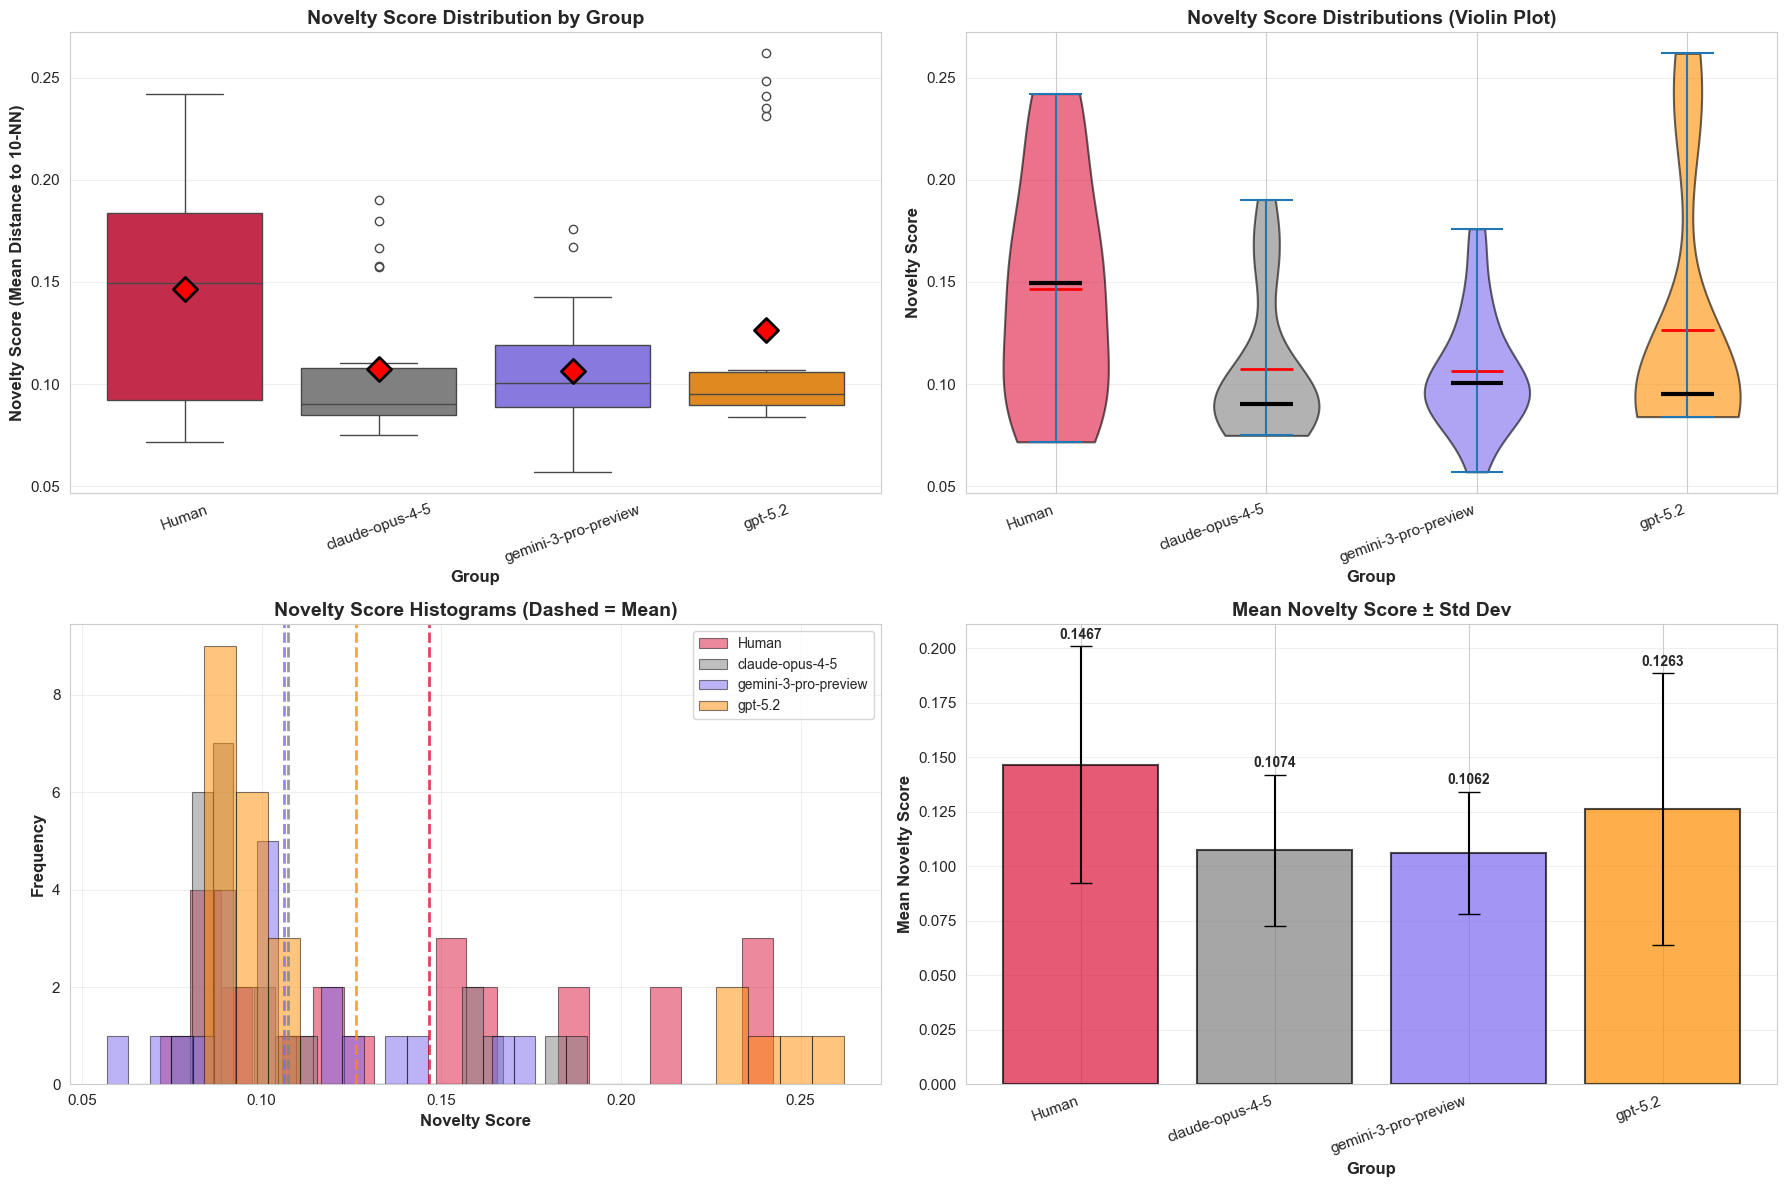


✓ Figure saved to: results/figures/novelty_analysis.png


In [33]:
# Visualization: Novelty scores by group
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

group_order = ['Human'] + [m for m in ai_models if m in model_novelty_scores]

# PANEL 1: Box plots comparing novelty scores
ax1 = axes[0, 0]
novelty_data = []
for group in group_order:
    if group == 'Human':
        scores = human_novelty_scores
    else:
        scores = model_novelty_scores[group]
    
    for score in scores:
        novelty_data.append({'Novelty Score': score, 'Group': group})

novelty_df = pd.DataFrame(novelty_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.boxplot(data=novelty_df, x='Group', y='Novelty Score', ax=ax1, palette=palette_list, order=group_order)
ax1.set_ylabel('Novelty Score (Mean Distance to 10-NN)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Group', fontsize=12, fontweight='bold')
ax1.set_title('Novelty Score Distribution by Group', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(alpha=0.3, axis='y')

# Add mean markers
for idx, group in enumerate(group_order):
    if group == 'Human':
        mean_val = human_novelty_scores.mean()
    else:
        mean_val = model_novelty_scores[group].mean()
    ax1.scatter(idx, mean_val, color='red', s=150, marker='D', zorder=10, edgecolors='black', linewidth=2)

# PANEL 2: Violin plots
ax2 = axes[0, 1]
parts = ax2.violinplot([novelty_df[novelty_df['Group']==g]['Novelty Score'].values for g in group_order],
                       positions=range(len(group_order)),
                       showmeans=True, showmedians=True, showextrema=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

ax2.set_xticks(range(len(group_order)))
ax2.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax2.set_ylabel('Novelty Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Group', fontsize=12, fontweight='bold')
ax2.set_title('Novelty Score Distributions (Violin Plot)', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# PANEL 3: Histogram of novelty scores
ax3 = axes[1, 0]
for group in group_order:
    if group == 'Human':
        scores = human_novelty_scores
    else:
        scores = model_novelty_scores[group]
    
    ax3.hist(scores, bins=20, alpha=0.5, label=group, 
            color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)
    ax3.axvline(scores.mean(), color=colors.get(group, 'gray'), 
               linestyle='--', linewidth=2, alpha=0.8)

ax3.set_xlabel('Novelty Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Novelty Score Histograms (Dashed = Mean)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# PANEL 4: Bar chart with error bars
ax4 = axes[1, 1]
means = []
stds = []
for group in group_order:
    if group == 'Human':
        scores = human_novelty_scores
    else:
        scores = model_novelty_scores[group]
    means.append(scores.mean())
    stds.append(scores.std())

bars = ax4.bar(range(len(group_order)), means, yerr=stds, 
              color=[colors.get(g, 'gray') for g in group_order],
              edgecolor='black', linewidth=1.5, alpha=0.7, capsize=8)
ax4.set_xticks(range(len(group_order)))
ax4.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax4.set_ylabel('Mean Novelty Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('Group', fontsize=12, fontweight='bold')
ax4.set_title('Mean Novelty Score ± Std Dev', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean_val, std_val) in enumerate(zip(means, stds)):
    ax4.text(i, mean_val + std_val + 0.002, f'{mean_val:.4f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/baseline/novelty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/baseline/novelty_analysis.png")


## Step 7: Visualize Proposals in Literature Context

Show where proposals fall relative to existing literature in embedding space.

VISUALIZING PROPOSALS IN LITERATURE CONTEXT

Total embeddings: 692
  Literature: 600
  Human proposals: 23
  AI proposals: 69

Reducing to 2D using UMAP...
✓ UMAP completed


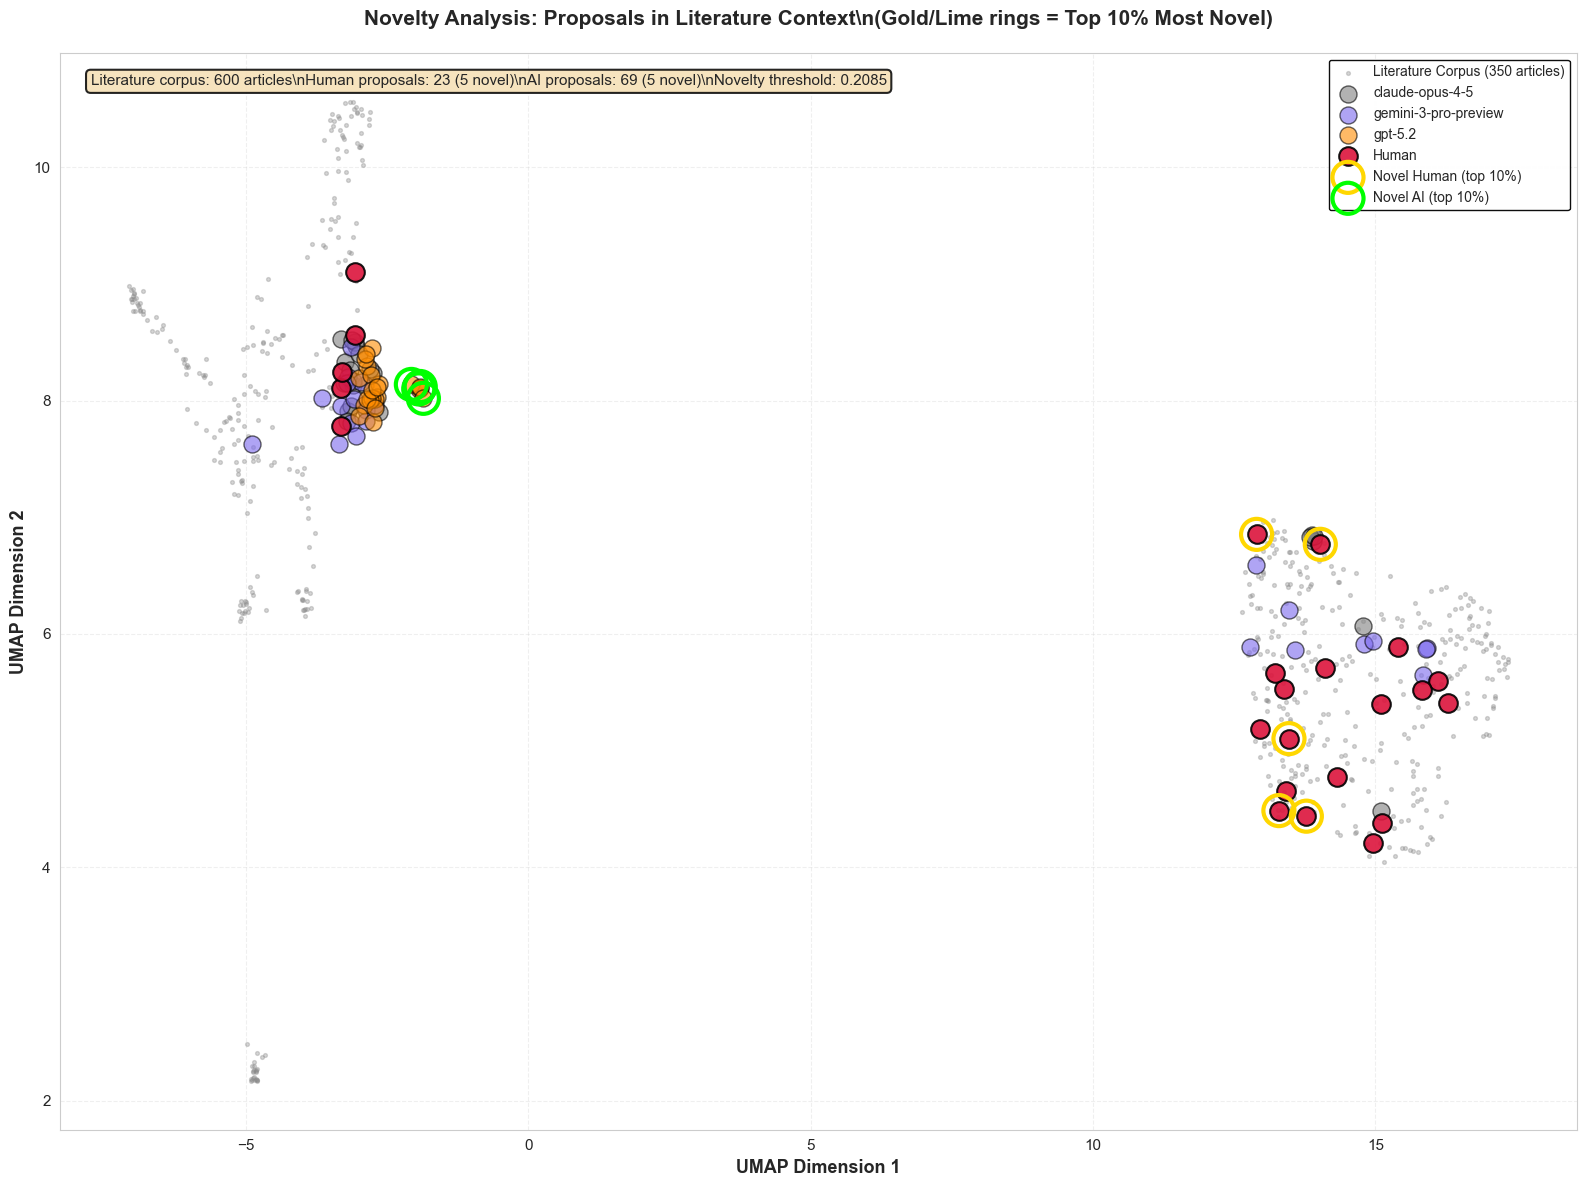


✓ Figure saved to: results/figures/novelty_embedding_space.png

💡 INTERPRETATION:
   - Gray dots = existing literature (context)
   - Colored points = proposals
   - Gold/Lime rings = top 10% most novel proposals
   - Proposals FAR from gray cloud = more novel
   - Proposals WITHIN gray cloud = building on existing work


In [34]:
import umap
# Visualization: Embedding space with literature context
print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE CONTEXT")
print("="*85)

# Combine all embeddings: literature + proposals
all_combined = np.vstack([literature_embeddings, human_embeddings_abstract, ai_embeddings_abstract])
n_lit = len(literature_embeddings)
n_human_abs = len(human_embeddings_abstract)
n_ai_abs = len(ai_embeddings_abstract)

print(f"\nTotal embeddings: {len(all_combined)}")
print(f"  Literature: {n_lit}")
print(f"  Human proposals: {n_human_abs}")
print(f"  AI proposals: {n_ai_abs}")

# Apply UMAP to combined embeddings
print("\nReducing to 2D using UMAP...")
reducer_novelty = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_novelty = reducer_novelty.fit_transform(all_combined)

# Split back
literature_2d = embeddings_2d_novelty[:n_lit]
human_2d_abs = embeddings_2d_novelty[n_lit:n_lit+n_human_abs]
ai_2d_abs = embeddings_2d_novelty[n_lit+n_human_abs:]

# Split AI by model (mask-based; do NOT assume contiguous blocks)
if 'ai_df' not in globals() or 'model' not in ai_df.columns:
    raise RuntimeError("ai_df with a 'model' column is required for per-model plotting in abstract space")

ai_model_series = ai_df['model'].astype(str).values

print(f"✓ UMAP completed")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

# Plot literature corpus first (as background context)
ax.scatter(literature_2d[:, 0], literature_2d[:, 1],
          c='#8A8A8A',
          label='Literature Corpus (350 articles)',
          s=30,
          alpha=0.35,
          marker='.',
          zorder=1)

# Plot AI models (mask-based)
for model in ai_models:
    mask = ai_model_series == str(model)
    if np.any(mask):
        pts = ai_2d_abs[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=150,
                   alpha=0.6,
                   edgecolors='black',
                   linewidth=1.0,
                   zorder=5)

# Plot human proposals on top (most prominent)
ax.scatter(human_2d_abs[:, 0], human_2d_abs[:, 1],
          c=colors['Human'],
          label='Human',
          s=180,
          alpha=0.9,
          edgecolors='black',
          linewidth=1.5,
          marker='o',
          zorder=10)

# Identify top 10% most novel proposals (highest novelty scores)
all_novelty_scores = np.concatenate([human_novelty_scores, ai_novelty_scores])
novelty_threshold = np.percentile(all_novelty_scores, 90)
novel_proposals = all_novelty_scores > novelty_threshold

# Split into human and AI novel proposals
novel_human = human_novelty_scores > novelty_threshold
novel_ai = ai_novelty_scores > novelty_threshold

# Highlight novel proposals
human_2d_novel = human_2d_abs[novel_human]
ai_2d_novel = ai_2d_abs[novel_ai]

if len(human_2d_novel) > 0:
    ax.scatter(human_2d_novel[:, 0], human_2d_novel[:, 1],
              s=500,
              facecolors='none',
              edgecolors='gold',
              linewidth=3,
              alpha=1.0,
              zorder=12,
              label=f'Novel Human (top 10%)')

if len(ai_2d_novel) > 0:
    ax.scatter(ai_2d_novel[:, 0], ai_2d_novel[:, 1],
              s=500,
              facecolors='none',
              edgecolors='lime',
              linewidth=3,
              alpha=1.0,
              zorder=12,
              label=f'Novel AI (top 10%)')

# Labels and formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Novelty Analysis: Proposals in Literature Context\\n(Gold/Lime rings = Top 10% Most Novel)',
            fontsize=15, fontweight='bold', pad=20)

# Legend
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text annotation
textstr = f'Literature corpus: {n_lit} articles\\n'
textstr += f'Human proposals: {n_human_abs} ({novel_human.sum()} novel)\\n'
textstr += f'AI proposals: {n_ai_abs} ({novel_ai.sum()} novel)\\n'
textstr += f'Novelty threshold: {novelty_threshold:.4f}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('results/figures/baseline/novelty_embedding_space.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/baseline/novelty_embedding_space.png")
print("\n💡 INTERPRETATION:")
print("   - Gray dots = existing literature (context)")
print("   - Colored points = proposals")
print("   - Gold/Lime rings = top 10% most novel proposals")
print("   - Proposals FAR from gray cloud = more novel")
print("   - Proposals WITHIN gray cloud = building on existing work")
print("="*85)


## Additional Analysis: Examine Nearest Neighbors in Literature

For the most and least novel proposals, identify which literature articles are closest.

In [35]:
# Examine most and least novel proposals
print("="*85)
print("EXAMINING MOST AND LEAST NOVEL PROPOSALS")
print("="*85)

# Find most novel human proposal
most_novel_human_idx = human_novelty_scores.argmax()
most_novel_human_score = human_novelty_scores[most_novel_human_idx]
most_novel_human_title = human_df.iloc[most_novel_human_idx]['proposal_title']

print(f"\n🏆 MOST NOVEL HUMAN PROPOSAL:")
print(f"  Title: {most_novel_human_title}")
print(f"  Novelty Score: {most_novel_human_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(human_nn_indices[most_novel_human_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([human_embeddings_abstract[most_novel_human_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find least novel human proposal
least_novel_human_idx = human_novelty_scores.argmin()
least_novel_human_score = human_novelty_scores[least_novel_human_idx]
least_novel_human_title = human_df.iloc[least_novel_human_idx]['proposal_title']

print(f"\n📚 LEAST NOVEL HUMAN PROPOSAL:")
print(f"  Title: {least_novel_human_title}")
print(f"  Novelty Score: {least_novel_human_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(human_nn_indices[least_novel_human_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([human_embeddings_abstract[least_novel_human_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find most novel AI proposal
most_novel_ai_idx = ai_novelty_scores.argmax()
most_novel_ai_score = ai_novelty_scores[most_novel_ai_idx]
most_novel_ai_title = ai_df.iloc[most_novel_ai_idx]['title']
most_novel_ai_model = ai_df.iloc[most_novel_ai_idx]['model']

print(f"\n🏆 MOST NOVEL AI PROPOSAL:")
print(f"  Model: {most_novel_ai_model}")
print(f"  Title: {most_novel_ai_title}")
print(f"  Novelty Score: {most_novel_ai_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(ai_nn_indices[most_novel_ai_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([ai_embeddings_abstract[most_novel_ai_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find least novel AI proposal
least_novel_ai_idx = ai_novelty_scores.argmin()
least_novel_ai_score = ai_novelty_scores[least_novel_ai_idx]
least_novel_ai_title = ai_df.iloc[least_novel_ai_idx]['title']
least_novel_ai_model = ai_df.iloc[least_novel_ai_idx]['model']

print(f"\n📚 LEAST NOVEL AI PROPOSAL:")
print(f"  Model: {least_novel_ai_model}")
print(f"  Title: {least_novel_ai_title}")
print(f"  Novelty Score: {least_novel_ai_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(ai_nn_indices[least_novel_ai_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([ai_embeddings_abstract[least_novel_ai_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

print("="*85)


EXAMINING MOST AND LEAST NOVEL PROPOSALS

🏆 MOST NOVEL HUMAN PROPOSAL:
  Title: Emergent Order Parameters of Allostery: An AI Framework for Predicting and Engineering Protein Regulation
  Novelty Score: 0.2423
  Nearest neighbors in literature:
    1. [35675815] A conceptual framework for understanding phase separation and addressing open qu...
       Distance: 0.2268, Published: 2022 Jun 16
    2. [36519968] Soft X-ray tomograms provide a structural basis for whole-cell modeling....
       Distance: 0.2299, Published: 2023 Jan
    3. [20808522] Plant protein-protein interaction network and interactome....
       Distance: 0.2324, Published: 2010
    4. [32385298] Valence-programmable nanoparticle architectures....
       Distance: 0.2411, Published: 2020 May 8
    5. [36318922] WNK kinases sense molecular crowding and rescue cell volume via phase separation...
       Distance: 0.2421, Published: 2022 Nov 23

📚 LEAST NOVEL HUMAN PROPOSAL:
  Title: Elucidating genome structure-function 

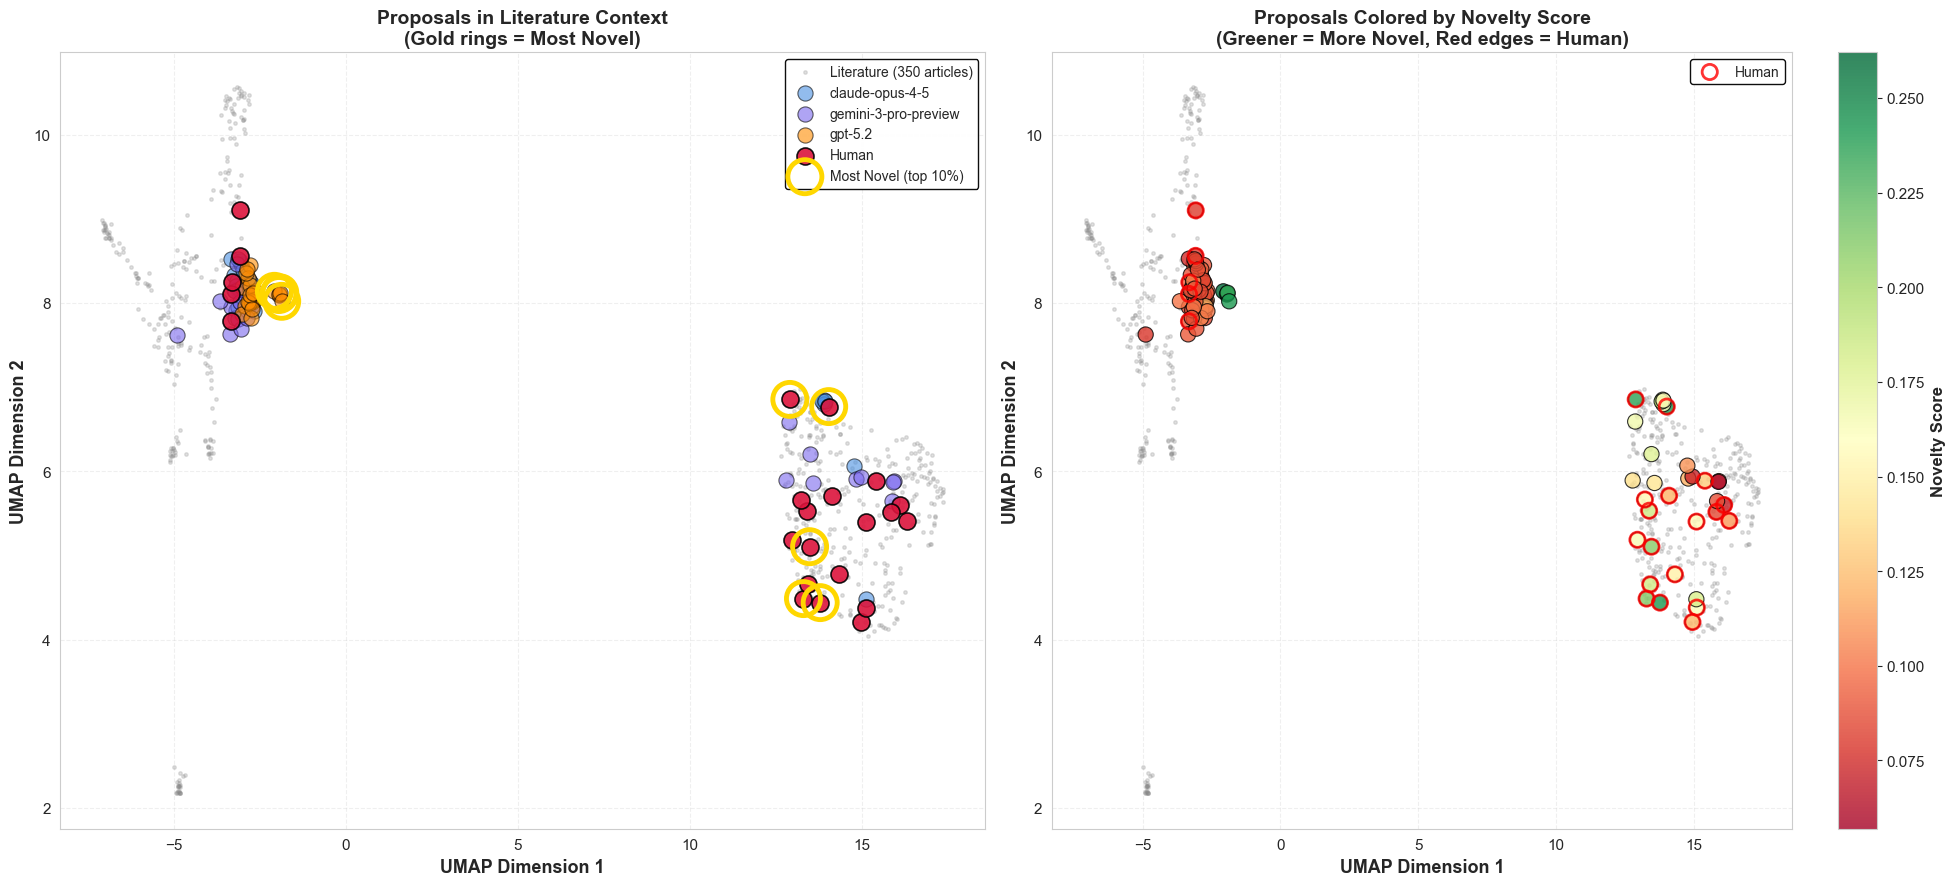


✓ Figure saved to: results/figures/novelty_embedding_space_detailed.png


In [36]:
# Create detailed 2D visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Ensure per-model 2D slices exist for AI abstracts
if 'ai_models' in globals() and ai_models:
    ai_models_local = list(ai_models)
else:
    ai_models_local = sorted(ai_df['model'].astype(str).unique().tolist())

ai_model_series = ai_df['model'].astype(str).values
model_2d_abs = {m: ai_2d_abs[ai_model_series == m] for m in ai_models_local}

# Color scheme
colors_nov = {
    'Human': '#DC143C',  # Crimson red
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

# PANEL 1: Full view with literature context
ax1 = axes[0]

# Literature (gray background)
ax1.scatter(literature_2d[:, 0], literature_2d[:, 1],
          c='#8A8A8A',
          label='Literature (350 articles)',
          s=25,
          alpha=0.25,
          marker='.',
          zorder=1)

# AI proposals
for model in ai_models_local:
    if model in model_2d_abs:
        ax1.scatter(model_2d_abs[model][:, 0], model_2d_abs[model][:, 1],
                  c=colors_nov.get(model, '#808080'),
                  label=model,
                  s=120,
                  alpha=0.6,
                  edgecolors='black',
                  linewidth=0.8,
                  zorder=5)

# Human proposals (most prominent)
ax1.scatter(human_2d_abs[:, 0], human_2d_abs[:, 1],
          c=colors_nov['Human'],
          label='Human',
          s=150,
          alpha=0.9,
          edgecolors='black',
          linewidth=1.2,
          marker='o',
          zorder=10)

# Highlight most novel proposals
all_2d_proposals = np.vstack([human_2d_abs, ai_2d_abs])
novel_proposals_2d = all_2d_proposals[novel_proposals]

ax1.scatter(novel_proposals_2d[:, 0], novel_proposals_2d[:, 1],
          s=600,
          facecolors='none',
          edgecolors='gold',
          linewidth=3.5,
          alpha=1.0,
          zorder=15,
          label=f'Most Novel (top 10%)')

ax1.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax1.set_title('Proposals in Literature Context\n(Gold rings = Most Novel)',
            fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax1.grid(True, alpha=0.3, linestyle='--')

# PANEL 2: Novelty score visualization (color-coded by score)
ax2 = axes[1]

# Literature (gray background)
ax2.scatter(literature_2d[:, 0], literature_2d[:, 1],
          c='#8A8A8A',
          s=25,
          alpha=0.25,
          marker='.',
          zorder=1)

# All proposals colored by novelty score
all_2d_proposals = np.vstack([human_2d_abs, ai_2d_abs])
all_novelty = np.concatenate([human_novelty_scores, ai_novelty_scores])

scatter = ax2.scatter(all_2d_proposals[:, 0], all_2d_proposals[:, 1],
                     c=all_novelty,
                     s=120,
                     alpha=0.8,
                     cmap='RdYlGn',
                     edgecolors='black',
                     linewidth=0.8,
                     zorder=5)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Novelty Score', fontsize=12, fontweight='bold')

# Highlight human vs AI with edge colors
ax2.scatter(human_2d_abs[:, 0], human_2d_abs[:, 1],
          s=120,
          facecolors='none',
          edgecolors='red',
          linewidth=2,
          alpha=0.8,
          zorder=8,
          label='Human')

ax2.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax2.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax2.set_title('Proposals Colored by Novelty Score\n(Greener = More Novel, Red edges = Human)',
            fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('results/figures/baseline/novelty_embedding_space_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/baseline/novelty_embedding_space_detailed.png")
print("="*85)


---

# PART III: THEMATIC AND CLUSTER ANALYSIS

Examine whether human and AI proposals cluster in distinct semantic regions and differ in thematic coverage.

**⚠️ Sample Size Note:** With n=23 human and n=69 AI proposals, we use conservative approaches with strong regularization and permutation-based validation.

## Analysis 3.1: Topic Modeling (LDA - Exploratory)

Use Latent Dirichlet Allocation with strong priors to identify thematic topics. LDA is more stable than BERTopic for small samples.

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

print("="*85)
print("TOPIC MODELING WITH LDA (EXPLORATORY)")
print("="*85)
print("Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.")

def _normalize_topic_text(text):
    text = str(text or "")
    text = re.sub(r'\b(title|abstract|background|methods?|research questions?|outcomes?|open science|budget)\s*:', ' ', text, flags=re.I)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

def _build_topic_text(row, is_ai=True):
    if is_ai:
        title = row.get('title', '')
        abstract = row.get('abstract', '')
    else:
        title = row.get('proposal_title', row.get('title', ''))
        abstract = row.get('abstract', '')
    return _normalize_topic_text(f"{title}. {abstract}")

ai_abstracts = [_build_topic_text(row, is_ai=True) for _, row in ai_df.iterrows()]
human_abstracts = [_build_topic_text(row, is_ai=False) for _, row in human_df.iterrows()]
all_abstracts = human_abstracts + ai_abstracts

source_labels = ['Human'] * len(human_abstracts) + ['AI'] * len(ai_abstracts)
model_labels = ['Human'] * len(human_abstracts) + ai_df['model'].tolist()

print()
print(f"✓ Prepared {len(all_abstracts)} topic-model texts")
print(f"  Human: {len(human_abstracts)}, AI: {len(ai_abstracts)}")

_unigram_probe = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=2, max_df=1.0, max_features=5000)
_unigram_X = _unigram_probe.fit_transform(all_abstracts)
_unigram_terms = _unigram_probe.get_feature_names_out()
_unigram_df = np.asarray((_unigram_X > 0).mean(axis=0)).ravel()

auto_domain_unigram_stopwords = set(_unigram_terms[_unigram_df >= 0.50])
manual_domain_unigram_stopwords = {
    'cell', 'cells', 'protein', 'proteins',
    'title', 'abstract', 'project', 'proposal', 'outcomes',
    'background', 'method', 'methods',
    'using', 'nup', '000', 'nan', 'fg', 'npc', 'ii', 'et'
}
domain_unigram_stopwords = auto_domain_unigram_stopwords | manual_domain_unigram_stopwords

_top_common_idx = np.argsort(_unigram_df)[-20:][::-1]
print()
print("Most common unigrams in corpus (doc frequency):")
for i in _top_common_idx:
    print(f"  {_unigram_terms[i]}: {_unigram_df[i]:.2f}")
print()
print(f"✓ Domain unigram stopwords (auto+manual): {len(domain_unigram_stopwords)}")

print()
print("Creating document-term matrix...")
vectorizer = CountVectorizer(max_features=2000, min_df=2, max_df=0.7, stop_words='english', ngram_range=(1, 2))
_doc_term_matrix_full = vectorizer.fit_transform(all_abstracts)
_feature_names_full = np.array(vectorizer.get_feature_names_out())

_unigram_mask = np.array([' ' not in t for t in _feature_names_full])
_drop_mask = _unigram_mask & np.isin(_feature_names_full, list(domain_unigram_stopwords))
_keep_mask = ~_drop_mask

doc_term_matrix = _doc_term_matrix_full[:, _keep_mask]
feature_names = _feature_names_full[_keep_mask]

print(f"✓ Document-term matrix: {doc_term_matrix.shape}")
print(f"  Documents: {doc_term_matrix.shape[0]}, Vocabulary: {doc_term_matrix.shape[1]}")
print(f"  Dropped domain unigrams: {_drop_mask.sum()} (kept bigrams intact)")

print()
print("Fitting LDA with conservative parameters...")
print("  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)")

n_topics = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=0.5,
    topic_word_prior=0.5,
    max_iter=100,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)
doc_topic_dist = lda_model.fit_transform(doc_term_matrix)

print("✓ LDA fitted")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"  Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")

def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

topics = display_topics(lda_model, feature_names, n_top_words=10)

print()
print("="*85)
print("TOP 10 WORDS PER TOPIC")
print("="*85)
for i, topic_words in enumerate(topics):
    print()
    print(f"Topic {i+1}: {', '.join(topic_words)}")

doc_topic_df = pd.DataFrame(doc_topic_dist, columns=[f'Topic_{i+1}' for i in range(n_topics)])
doc_topic_df['source'] = source_labels
doc_topic_df['model'] = model_labels
doc_topic_df['group'] = ['Human' if s == 'Human' else 'AI' for s in source_labels]

doc_topic_df['dominant_topic'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].idxmax(axis=1)
doc_topic_df['dominant_topic_prob'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].max(axis=1)

print()
print("="*85)
print("DOCUMENT-TOPIC DISTRIBUTION SUMMARY")
print("="*85)
print("Mean topic probabilities per document:")
for i in range(n_topics):
    print(f"  Topic {i+1}: {doc_topic_df[f'Topic_{i+1}'].mean():.3f} ± {doc_topic_df[f'Topic_{i+1}'].std():.3f}")

print()
print("Dominant topic assignment:")
print(doc_topic_df['dominant_topic'].value_counts().sort_index())

print()
print("⚠️ LABEL AS EXPLORATORY - Small sample size limits topic stability")
print("="*85)


TOPIC MODELING WITH LDA (EXPLORATORY)
Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.

✓ Prepared 92 topic-model texts
  Human: 23, AI: 69

Most common unigrams in corpus (doc frequency):
  data: 0.89
  emergent: 0.83
  synthesize: 0.76
  mesoscale: 0.76
  datasets: 0.75
  project: 0.64
  protein: 0.63
  models: 0.61
  cell: 0.61
  synthesis: 0.59
  structural: 0.57
  include: 0.55
  analysis: 0.54
  expected: 0.54
  requires: 0.53
  insights: 0.51
  single: 0.49
  computational: 0.48
  specific: 0.47
  learning: 0.46

✓ Domain unigram stopwords (auto+manual): 33

Creating document-term matrix...
✓ Document-term matrix: (92, 1977)
  Documents: 92, Vocabulary: 1977
  Dropped domain unigrams: 23 (kept bigrams intact)

Fitting LDA with conservative parameters...
  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)
✓ LDA fitted
  Perplexity: 1332.58
  Log-likelihood: -117348.39

TOP 10 WORDS PER TOPIC

Topic 1: imaging, open, membrane, prote

In [38]:
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency

print("="*85)
print("TOPIC STABILITY VALIDATION")
print("="*85)
print("Running LDA with 10 different random seeds to assess stability (with topic alignment)...")

n_stability_runs = 10
n_top_words = 10
stability_topics = []
stability_topic_dists = []

for seed in range(n_stability_runs):
    lda_temp = LatentDirichletAllocation(
        n_components=n_topics,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=seed,
        n_jobs=-1
    )
    lda_temp.fit(doc_term_matrix)

    topic_word = lda_temp.components_.astype(float)
    topic_word = topic_word / topic_word.sum(axis=1, keepdims=True)

    topics_temp = display_topics(lda_temp, feature_names, n_top_words=n_top_words)
    stability_topics.append(topics_temp)
    stability_topic_dists.append(topic_word)

print(f"✓ Completed {n_stability_runs} stability runs")

ref_words_by_topic = [set(ws) for ws in stability_topics[0]]
ref_dist = stability_topic_dists[0]

def _cosine_sim_matrix(A, B, eps=1e-12):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return A @ B.T

per_topic_overlap_all = [[] for _ in range(n_topics)]
per_topic_cos_all = [[] for _ in range(n_topics)]

print()
print("Topic stability (aligned to reference run):")
for run_idx in range(1, n_stability_runs):
    run_dist = stability_topic_dists[run_idx]
    sim = _cosine_sim_matrix(run_dist, ref_dist)

    row_ind, col_ind = linear_sum_assignment(-sim)

    aligned_words = [None] * n_topics
    aligned_cos = np.zeros(n_topics, dtype=float)
    for r_topic, ref_topic in zip(row_ind, col_ind):
        aligned_words[ref_topic] = set(stability_topics[run_idx][r_topic])
        aligned_cos[ref_topic] = sim[r_topic, ref_topic]

    overlaps = []
    for k in range(n_topics):
        overlap = len(ref_words_by_topic[k] & aligned_words[k]) / max(1, len(ref_words_by_topic[k]))
        overlaps.append(overlap)
        per_topic_overlap_all[k].append(overlap)
        per_topic_cos_all[k].append(aligned_cos[k])

    print(f"  Run {run_idx}: mean top-{n_top_words} overlap={np.mean(overlaps):.1%}, mean cosine={np.mean(aligned_cos):.3f}")

print()
print("Per-topic stability (mean across aligned runs):")
for k in range(n_topics):
    print(
        f"  Topic {k+1}: {np.mean(per_topic_overlap_all[k]):.1%} ± {np.std(per_topic_overlap_all[k]):.1%} top-{n_top_words} overlap, "
        f"{np.mean(per_topic_cos_all[k]):.3f} ± {np.std(per_topic_cos_all[k]):.3f} cosine"
    )

print()
print("="*85)
print("TOPIC COUNT SENSITIVITY (k = 4..8)")
print("="*85)

sensitivity_rows = []
for k in [4, 5, 6, 7, 8]:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=42,
        n_jobs=-1
    )
    dt_k = lda_k.fit_transform(doc_term_matrix)
    dominant_k = pd.Series(dt_k.argmax(axis=1)).map(lambda x: f'Topic_{x+1}')
    cont_k = pd.crosstab(dominant_k, pd.Series(source_labels, name='group'))
    chi2_k, p_k, _, _ = chi2_contingency(cont_k)

    sensitivity_rows.append({
        'k': k,
        'perplexity': float(lda_k.perplexity(doc_term_matrix)),
        'log_likelihood': float(lda_k.score(doc_term_matrix)),
        'chi2': float(chi2_k),
        'chi2_p': float(p_k),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("💡 If overlap/cosine are still low AFTER alignment, that reflects true instability.")
print("💡 k-sensitivity helps verify conclusions are not artifacts of a single topic count.")
print("="*85)


TOPIC STABILITY VALIDATION
Running LDA with 10 different random seeds to assess stability (with topic alignment)...
✓ Completed 10 stability runs

Topic stability (aligned to reference run):
  Run 1: mean top-10 overlap=46.0%, mean cosine=0.825
  Run 2: mean top-10 overlap=54.0%, mean cosine=0.786
  Run 3: mean top-10 overlap=60.0%, mean cosine=0.837
  Run 4: mean top-10 overlap=56.0%, mean cosine=0.867
  Run 5: mean top-10 overlap=68.0%, mean cosine=0.899
  Run 6: mean top-10 overlap=58.0%, mean cosine=0.813
  Run 7: mean top-10 overlap=40.0%, mean cosine=0.792
  Run 8: mean top-10 overlap=52.0%, mean cosine=0.794
  Run 9: mean top-10 overlap=54.0%, mean cosine=0.816

Per-topic stability (mean across aligned runs):
  Topic 1: 24.4% ± 17.1% top-10 overlap, 0.613 ± 0.104 cosine
  Topic 2: 71.1% ± 20.8% top-10 overlap, 0.954 ± 0.052 cosine
  Topic 3: 26.7% ± 11.5% top-10 overlap, 0.688 ± 0.055 cosine
  Topic 4: 68.9% ± 13.7% top-10 overlap, 0.922 ± 0.063 cosine
  Topic 5: 80.0% ± 4.7% to

## Analysis 3.2: Topic Distribution Comparison

Test whether topic distributions differ between human and AI proposals using permutation tests and Fisher's exact tests.

In [39]:
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

print("="*85)
print("TOPIC DISTRIBUTION COMPARISON")
print("="*85)

# Create contingency table: topics × source
contingency_table = pd.crosstab(doc_topic_df['dominant_topic'], doc_topic_df['group'])
print("\nContingency table (dominant topic × source):")
print(contingency_table)
print(f"\nRow percentages:")
print(pd.crosstab(doc_topic_df['dominant_topic'], doc_topic_df['group'], normalize='index').round(3))

# Permutation test for overall distribution difference
print("\n" + "-"*85)
print("PERMUTATION TEST: Overall topic distribution difference")
print("-"*85)

def compute_chi_square_stat(contingency):
    """Compute chi-square statistic from contingency table"""
    return chi2_contingency(contingency)[0]

observed_chi2 = compute_chi_square_stat(contingency_table)
print(f"Observed chi-square statistic: {observed_chi2:.4f}")

# Permutation test
n_permutations = 10000
perm_chi2_stats = []

for _ in range(n_permutations):
    # Shuffle source labels
    shuffled_labels = np.random.permutation(doc_topic_df['group'].values)
    perm_contingency = pd.crosstab(doc_topic_df['dominant_topic'], shuffled_labels)
    perm_chi2 = compute_chi_square_stat(perm_contingency)
    perm_chi2_stats.append(perm_chi2)

perm_chi2_stats = np.array(perm_chi2_stats)
p_value_perm = np.mean(perm_chi2_stats >= observed_chi2)

print(f"\nPermutation test results ({n_permutations:,} permutations):")
print(f"  Null mean chi-square: {perm_chi2_stats.mean():.4f} ± {perm_chi2_stats.std():.4f}")
print(f"  Observed chi-square: {observed_chi2:.4f}")
print(f"  p-value: {p_value_perm:.4f}")

if p_value_perm < 0.05:
    print(f"  → Significant difference in topic distributions (p < 0.05)")
else:
    print(f"  → No significant difference in topic distributions (p ≥ 0.05)")

# Per-topic Fisher's exact tests
print("\n" + "-"*85)
print("PER-TOPIC TESTS: Fisher's Exact (Human vs. All AI)")
print("-"*85)

fisher_results = []

for topic in contingency_table.index:
    # Create 2×2 table for this topic
    topic_yes = contingency_table.loc[topic, :]
    topic_no = contingency_table.drop(topic).sum(axis=0)
    
    table_2x2 = np.array([
        [topic_yes['Human'], topic_yes['AI']],
        [topic_no['Human'], topic_no['AI']]
    ])
    
    odds_ratio, p_value = fisher_exact(table_2x2)
    
    # Calculate percentages
    human_pct = topic_yes['Human'] / contingency_table['Human'].sum() * 100
    ai_pct = topic_yes['AI'] / contingency_table['AI'].sum() * 100
    
    fisher_results.append({
        'topic': topic,
        'human_count': topic_yes['Human'],
        'ai_count': topic_yes['AI'],
        'human_pct': human_pct,
        'ai_pct': ai_pct,
        'odds_ratio': odds_ratio,
        'p_value': p_value
    })

fisher_df = pd.DataFrame(fisher_results)

# Apply FDR correction (Benjamini-Hochberg at q=0.10 for exploratory)
fisher_df['p_value_fdr'] = multipletests(fisher_df['p_value'], method='fdr_bh', alpha=0.10)[1]

print(f"\n{'Topic':<12} {'Human %':<10} {'AI %':<10} {'OR':<8} {'p-value':<10} {'FDR q':<10} {'Result'}")
print("-"*85)

for _, row in fisher_df.iterrows():
    sig_mark = '***' if row['p_value_fdr'] < 0.01 else '**' if row['p_value_fdr'] < 0.05 else '*' if row['p_value_fdr'] < 0.10 else ''
    direction = 'Human↑' if row['odds_ratio'] > 1 else 'AI↑' if row['odds_ratio'] < 1 else 'Equal'
    
    print(f"{row['topic']:<12} {row['human_pct']:<10.1f} {row['ai_pct']:<10.1f} {row['odds_ratio']:<8.2f} "
          f"{row['p_value']:<10.4f} {row['p_value_fdr']:<10.4f} {direction} {sig_mark}")

print("\n*** p<0.01, ** p<0.05, * p<0.10 (FDR-corrected)")
print("OR > 1 = over-represented in human; OR < 1 = over-represented in AI")

print("="*85)


TOPIC DISTRIBUTION COMPARISON

Contingency table (dominant topic × source):
group           AI  Human
dominant_topic           
Topic_1         25      0
Topic_2          7      0
Topic_3          3     21
Topic_4         23      0
Topic_5         11      2

Row percentages:
group              AI  Human
dominant_topic              
Topic_1         1.000  0.000
Topic_2         1.000  0.000
Topic_3         0.125  0.875
Topic_4         1.000  0.000
Topic_5         0.846  0.154

-------------------------------------------------------------------------------------
PERMUTATION TEST: Overall topic distribution difference
-------------------------------------------------------------------------------------
Observed chi-square statistic: 68.9744

Permutation test results (10,000 permutations):
  Null mean chi-square: 4.0227 ± 2.7235
  Observed chi-square: 68.9744
  p-value: 0.0000
  → Significant difference in topic distributions (p < 0.05)

-----------------------------------------------------

### key question: does this mean “Humans and AI have totally different topics”?

Not necessarily. With topic models, this kind of perfect separation is a red flag that the topics may be picking up systematic stylistic / templating / preprocessing artifacts rather than genuine scientific themes.

Common causes:
* Single “methodology/meta” topic (your Topic 3 looked like “modeling/principles/properties…”) that Humans disproportionately use, while AI texts spread across more concrete assay/mechanism words—or vice versa.
* Distribution shift in writing style: AI tends to reuse certain phrasing patterns (“open”, “datasets”, “emergent”, etc.), and LDA can latch onto that as “topics.”
* Instability / label switching effects: if topics move around across seeds, “Topic_3” being the human bucket could be an artifact of one fit.
* Dominant-topic argmax is brittle: it throws away the mixture information and can exaggerate separation.

What low-level conclusion is safe here
Given this fitted model, dominant-topic assignment perfectly predicts Human vs AI in your sample. That’s what your contingency table and tests are measuring.

In [40]:
# Subsample validation to account for group size imbalance (23 human vs 69 AI)
print("="*85)
print("SUBSAMPLE VALIDATION (Accounting for 3:1 group size imbalance)")
print("="*85)
print("Subsampling AI to n=23, repeating 1000 times...")

n_subsamples = 1000
subsample_results = {topic: [] for topic in contingency_table.index}

for _ in range(n_subsamples):
    # Subsample AI to match human sample size
    ai_indices = doc_topic_df[doc_topic_df['group'] == 'AI'].index
    sampled_indices = np.random.choice(ai_indices, size=len(human_abstracts), replace=False)
    
    # Create balanced dataset
    balanced_df = pd.concat([
        doc_topic_df[doc_topic_df['group'] == 'Human'],
        doc_topic_df.loc[sampled_indices]
    ])
    
    # Test each topic
    for topic in contingency_table.index:
        human_has_topic = (balanced_df[balanced_df['group'] == 'Human']['dominant_topic'] == topic).sum()
        ai_has_topic = (balanced_df[balanced_df['group'] == 'AI']['dominant_topic'] == topic).sum()
        
        # 2×2 table
        table = np.array([
            [human_has_topic, len(human_abstracts) - human_has_topic],
            [ai_has_topic, len(human_abstracts) - ai_has_topic]
        ])
        
        _, p_val = fisher_exact(table)
        subsample_results[topic].append(p_val)

print("\nSubsample validation results:")
print(f"{'Topic':<12} {'Sig. in N subsamples':<25} {'Proportion':<12} {'Interpretation'}")
print("-"*85)

for topic in contingency_table.index:
    p_values = subsample_results[topic]
    n_significant = sum(np.array(p_values) < 0.05)
    proportion = n_significant / n_subsamples
    
    interpretation = "Robust" if proportion > 0.8 else "Moderate" if proportion > 0.5 else "Weak"
    print(f"{topic:<12} {n_significant}/{n_subsamples:<20} {proportion:<12.2%} {interpretation}")

print("\n💡 Proportion >80% = robust difference even with balanced sample sizes")
print("="*85)


SUBSAMPLE VALIDATION (Accounting for 3:1 group size imbalance)
Subsampling AI to n=23, repeating 1000 times...

Subsample validation results:
Topic        Sig. in N subsamples      Proportion   Interpretation
-------------------------------------------------------------------------------------
Topic_1      985/1000                 98.50%       Robust
Topic_2      30/1000                 3.00%        Weak
Topic_3      1000/1000                 100.00%      Robust
Topic_4      955/1000                 95.50%       Robust
Topic_5      0/1000                 0.00%        Weak

💡 Proportion >80% = robust difference even with balanced sample sizes


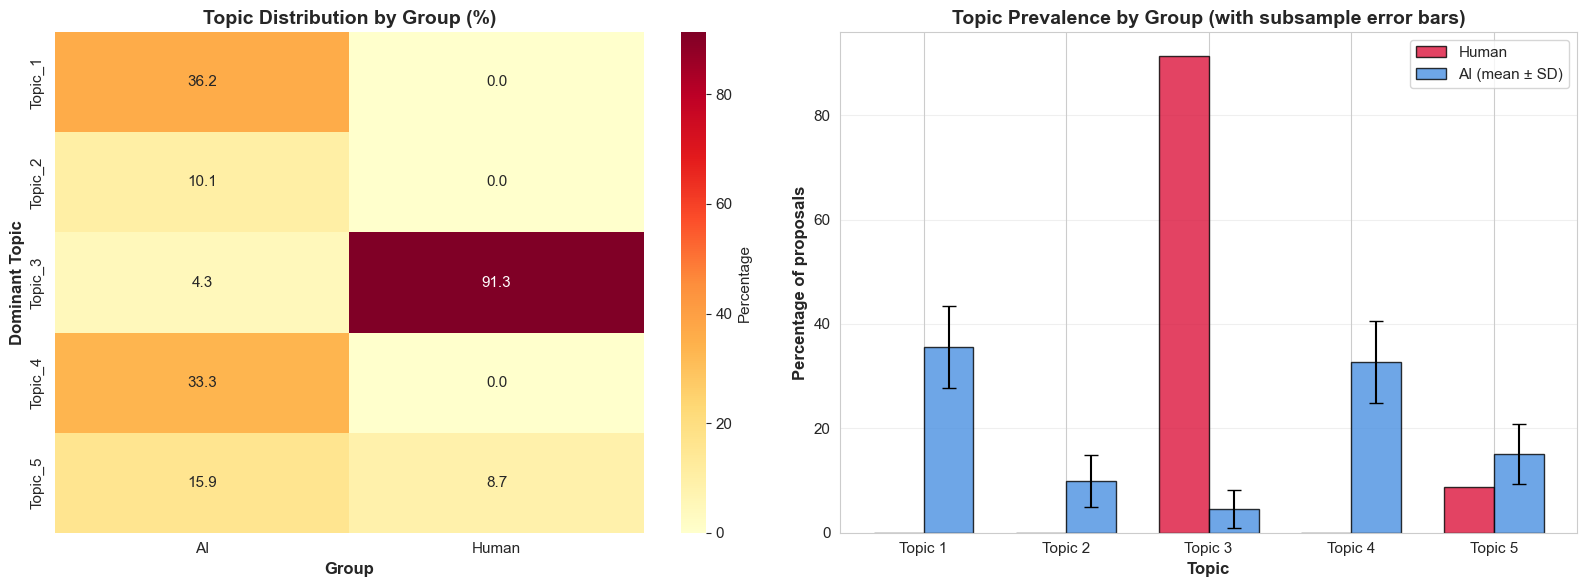

✓ Figure saved to: results/figures/topic_distribution_comparison.png


In [41]:
# Visualization: Topic distribution by group
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Heatmap of topic × source
ax1 = axes[0]
contingency_pct = pd.crosstab(doc_topic_df['dominant_topic'], doc_topic_df['group'], normalize='columns') * 100
sns.heatmap(contingency_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Percentage'})
ax1.set_title('Topic Distribution by Group (%)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Dominant Topic', fontsize=12, fontweight='bold')

# Panel 2: Bar plot with error bars from subsampling
ax2 = axes[1]
topic_labels = [f'Topic {i+1}' for i in range(n_topics)]
x = np.arange(len(topic_labels))
width = 0.35

# Human percentages
human_counts = contingency_table['Human']
human_pcts = (human_counts / human_counts.sum() * 100).values

# AI percentages with subsample SDs
ai_pcts_mean = []
ai_pcts_std = []

for topic in contingency_table.index:
    ai_subsample_pcts = []
    for _ in range(200):  # 200 subsamples for error bars
        ai_indices = doc_topic_df[doc_topic_df['group'] == 'AI'].index
        sampled = doc_topic_df.loc[np.random.choice(ai_indices, size=len(human_abstracts), replace=False)]
        pct = (sampled['dominant_topic'] == topic).sum() / len(human_abstracts) * 100
        ai_subsample_pcts.append(pct)
    ai_pcts_mean.append(np.mean(ai_subsample_pcts))
    ai_pcts_std.append(np.std(ai_subsample_pcts))

ax2.bar(x - width/2, human_pcts, width, label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
ax2.bar(x + width/2, ai_pcts_mean, width, yerr=ai_pcts_std, label='AI (mean ± SD)', 
        color='#4A90E2', alpha=0.8, edgecolor='black', capsize=5)

ax2.set_xlabel('Topic', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage of proposals', fontsize=12, fontweight='bold')
ax2.set_title('Topic Prevalence by Group (with subsample error bars)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(topic_labels)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/baseline/topic_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/baseline/topic_distribution_comparison.png")


## Analysis 3.3: Topic Coverage and Entropy

Examine breadth and evenness of topic coverage with sample size corrections.

In [42]:
from scipy.stats import entropy

print("="*85)
print("TOPIC COVERAGE AND ENTROPY ANALYSIS")
print("="*85)

threshold = 0.20

def count_topics_covered(doc_topic_probs, threshold=0.20):
    topic_cols = [col for col in doc_topic_probs.columns if col.startswith('Topic_')]
    topics_above_threshold = set()
    for col in topic_cols:
        if (doc_topic_probs[col] > threshold).any():
            topics_above_threshold.add(col)
    return len(topics_above_threshold)

human_doc_topics = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_doc_topics = doc_topic_df[doc_topic_df['group'] == 'AI']

human_coverage = count_topics_covered(human_doc_topics, threshold)
ai_coverage = count_topics_covered(ai_doc_topics, threshold)

print()
print(f"1. TOPIC COVERAGE (topics with at least one proposal >{threshold*100:.0f}% probability):")
print(f"  Human: {human_coverage}/{n_topics} topics")
print(f"  AI: {ai_coverage}/{n_topics} topics")

print()
print("2. EXCLUSIVE TOPICS:")

def get_exclusive_topics(group_df, other_df, threshold=0.20, min_count=5):
    topic_cols = [col for col in group_df.columns if col.startswith('Topic_')]
    exclusive = []
    for col in topic_cols:
        group_has = (group_df[col] > threshold).sum()
        other_has = (other_df[col] > threshold).sum()
        if group_has >= min_count and other_has == 0:
            exclusive.append(col)
    return exclusive

human_exclusive = get_exclusive_topics(human_doc_topics, ai_doc_topics, threshold, min_count=5)
ai_exclusive = get_exclusive_topics(ai_doc_topics, human_doc_topics, threshold, min_count=5)

print(f"  Human-exclusive topics (≥5 proposals, 0 in AI): {len(human_exclusive)}")
if human_exclusive:
    print(f"    {', '.join(human_exclusive)}")
print(f"  AI-exclusive topics (≥5 proposals, 0 in Human): {len(ai_exclusive)}")
if ai_exclusive:
    print(f"    {', '.join(ai_exclusive)}")

print()
print("  Permutation test for exclusive topics:")
n_perm = 10000
perm_human_exclusive_counts = []
perm_ai_exclusive_counts = []

for _ in range(n_perm):
    shuffled = doc_topic_df.copy()
    shuffled['group'] = np.random.permutation(shuffled['group'].values)

    human_perm = shuffled[shuffled['group'] == 'Human']
    ai_perm = shuffled[shuffled['group'] == 'AI']

    h_excl = len(get_exclusive_topics(human_perm, ai_perm, threshold, min_count=5))
    a_excl = len(get_exclusive_topics(ai_perm, human_perm, threshold, min_count=5))

    perm_human_exclusive_counts.append(h_excl)
    perm_ai_exclusive_counts.append(a_excl)

perm_human_exclusive_counts = np.array(perm_human_exclusive_counts)
perm_ai_exclusive_counts = np.array(perm_ai_exclusive_counts)

p_human = np.mean(perm_human_exclusive_counts >= len(human_exclusive))
p_ai = np.mean(perm_ai_exclusive_counts >= len(ai_exclusive))

print(f"    Human: {len(human_exclusive)} observed vs. {perm_human_exclusive_counts.mean():.2f} ± {perm_human_exclusive_counts.std():.2f} expected, p={p_human:.4f}")
print(f"    AI: {len(ai_exclusive)} observed vs. {perm_ai_exclusive_counts.mean():.2f} ± {perm_ai_exclusive_counts.std():.2f} expected, p={p_ai:.4f}")

print()
print("3. SHANNON ENTROPY (with Miller-Madow bias correction):")

def calculate_entropy_corrected(topic_distribution):
    topic_counts = topic_distribution.value_counts()
    h = entropy(topic_counts, base=2)
    k = len(topic_counts)
    n = topic_counts.sum()
    h_corrected = h + (k - 1) / (2 * n)
    h_max = np.log2(k) if k > 1 else 1
    h_normalized = h_corrected / h_max if h_max > 0 else 0
    return h_corrected, h_normalized

human_entropy, human_norm_entropy = calculate_entropy_corrected(human_doc_topics['dominant_topic'])
ai_entropy, ai_norm_entropy = calculate_entropy_corrected(ai_doc_topics['dominant_topic'])

print(f"  Human: H = {human_entropy:.4f}, H_normalized = {human_norm_entropy:.4f}")
print(f"  AI: H = {ai_entropy:.4f}, H_normalized = {ai_norm_entropy:.4f}")

print()
print(f"  Subsample validation (AI subsampled to n={len(human_abstracts)}, 1000 iterations):")
subsample_entropies = []
subsample_norm_entropies = []

for _ in range(1000):
    ai_indices = ai_doc_topics.index
    sampled = ai_doc_topics.loc[np.random.choice(ai_indices, size=len(human_abstracts), replace=False)]
    h, h_norm = calculate_entropy_corrected(sampled['dominant_topic'])
    subsample_entropies.append(h)
    subsample_norm_entropies.append(h_norm)

subsample_entropies = np.array(subsample_entropies)
subsample_norm_entropies = np.array(subsample_norm_entropies)

print(f"    AI (subsampled): H = {subsample_entropies.mean():.4f} ± {subsample_entropies.std():.4f}")
print(f"    AI (subsampled): H_normalized = {subsample_norm_entropies.mean():.4f} ± {subsample_norm_entropies.std():.4f}")

ai_sub_mean = subsample_entropies.mean()
diff = human_entropy - ai_sub_mean

p_lower = np.mean(subsample_entropies <= human_entropy)
p_upper = np.mean(subsample_entropies >= human_entropy)
p_two_sided = min(1.0, 2 * min(p_lower, p_upper))
p_one_sided = p_lower if human_entropy < ai_sub_mean else p_upper
p_entropy = p_two_sided

print()
print("  Comparison (subsample test):")
print(f"    Difference (Human - AI_subsample_mean): {diff:.4f}")
print(f"    p_one_sided (observed direction): {p_one_sided:.4f}")
print(f"    p_two_sided: {p_two_sided:.4f}")

if p_two_sided < 0.05:
    if human_entropy > ai_sub_mean:
        print("    → Human proposals have significantly HIGHER entropy (more even dominant-topic distribution)")
    else:
        print("    → AI proposals have significantly HIGHER entropy (more even dominant-topic distribution)")
else:
    print("    → No significant difference in entropy")

print()
print("💡 Higher entropy = more even spread across topics = higher thematic diversity")
print("="*85)


TOPIC COVERAGE AND ENTROPY ANALYSIS

1. TOPIC COVERAGE (topics with at least one proposal >20% probability):
  Human: 2/5 topics
  AI: 5/5 topics

2. EXCLUSIVE TOPICS:
  Human-exclusive topics (≥5 proposals, 0 in AI): 0
  AI-exclusive topics (≥5 proposals, 0 in Human): 3
    Topic_1, Topic_2, Topic_4

  Permutation test for exclusive topics:
    Human: 0 observed vs. 0.00 ± 0.00 expected, p=1.0000
    AI: 3 observed vs. 0.07 ± 0.26 expected, p=0.0000

3. SHANNON ENTROPY (with Miller-Madow bias correction):
  Human: H = 0.4480, H_normalized = 0.4480
  AI: H = 2.0419, H_normalized = 0.8794

  Subsample validation (AI subsampled to n=23, 1000 iterations):
    AI (subsampled): H = 1.9933 ± 0.1710
    AI (subsampled): H_normalized = 0.9038 ± 0.0531

  Comparison (subsample test):
    Difference (Human - AI_subsample_mean): -1.5453
    p_one_sided (observed direction): 0.0000
    p_two_sided: 0.0000
    → AI proposals have significantly HIGHER entropy (more even dominant-topic distribution)


## Analysis 3.4: Cluster Composition/Segregation Analysis

Examine whether human and AI proposals segregate into distinct clusters in embedding space using Gaussian Mixture Models.

In [43]:
from pathlib import Path

if BASELINE_EMBEDDINGS_FILE.exists():
    emb_path = BASELINE_EMBEDDINGS_FILE
else:
    candidate_paths = sorted(Path('data/embeddings/full_proposals').glob('proposal_embeddings*.pkl'))
    if not candidate_paths:
        candidate_paths = sorted(Path('data/embeddings').glob('proposal_embeddings*.pkl'))

    if not candidate_paths:
        raise FileNotFoundError("No embedding pickle found under data/embeddings/. Generate or place proposal_embeddings*.pkl first.")

    emb_path = candidate_paths[-1]

embeddings_data = retrieve_embeddings(emb_path)

ai_embeddings = embeddings_data['ai_embeddings']
human_embeddings = embeddings_data['human_embeddings']
ai_metadata = embeddings_data['ai_metadata']
human_metadata = embeddings_data['human_metadata']

print(f"✓ Loaded embeddings from: {emb_path}")
print(f"  AI: {ai_embeddings.shape}, Human: {human_embeddings.shape}")


✓ Loaded embeddings from: data/embeddings/full_proposals/proposal_embeddings_human_ai_baseline.pkl
  AI: (69, 1024), Human: (23, 1024)


CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION

Using embeddings: (92, 1024)
  Human: 23, AI: 69

Testing k = [3, 4, 5, 6, 7, 8]...

k     Silhouette   Davies-Bouldin   BIC         
--------------------------------------------------
3     0.1009       1.9845           6058609.70  
4     0.1197       2.1773           8416661.77  
5     0.1234       1.9119           10787636.03 
6     0.1145       1.7012           13165324.67 
7     0.1160       1.6928           15540335.04 
8     0.1131       1.8885           17915506.25 

✓ Best k by BIC (elbow method): 3
✓ Best k by Silhouette score: 5

→ Selected k = 3 (using BIC)


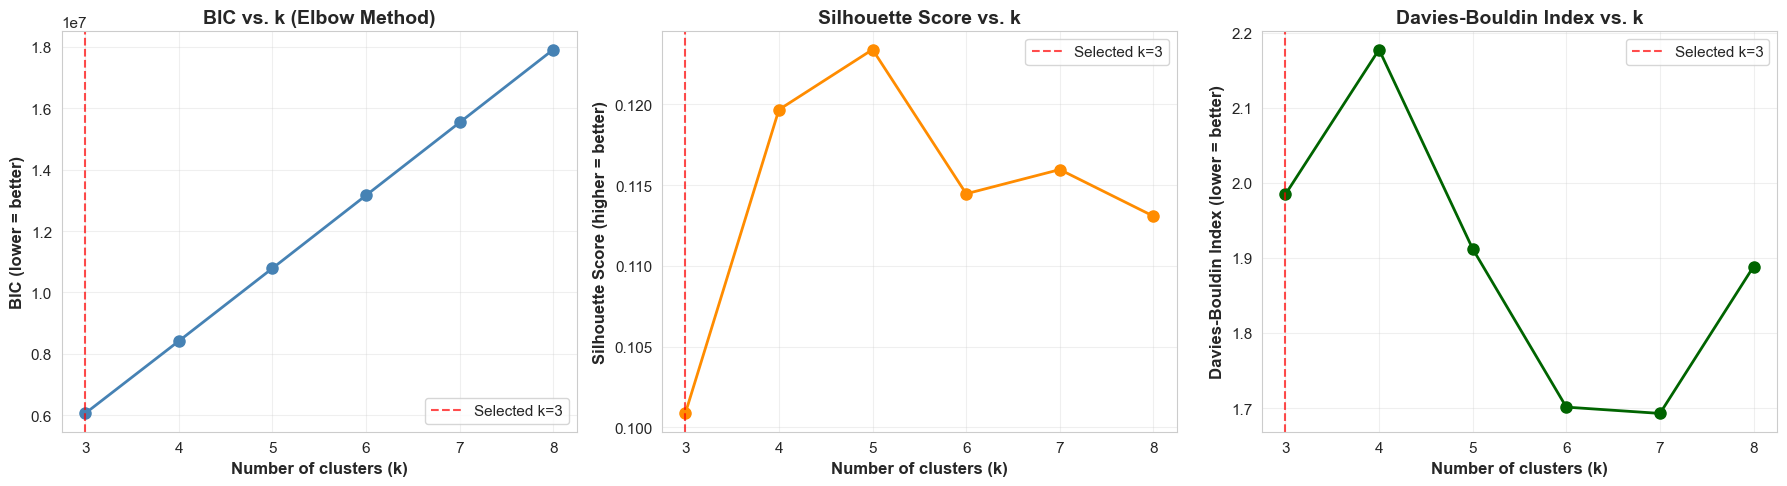

✓ Figure saved to: results/figures/cluster_k_selection.png


In [44]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, normalized_mutual_info_score, adjusted_rand_score

print("="*85)
print("CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION")
print("="*85)

# Use embeddings from diversity analysis (already computed)
all_embeddings_cluster = np.vstack([human_embeddings, ai_embeddings])
source_labels_cluster = np.array(['Human'] * len(human_embeddings) + ['AI'] * len(ai_embeddings))

print(f"\nUsing embeddings: {all_embeddings_cluster.shape}")
print(f"  Human: {len(human_embeddings)}, AI: {len(ai_embeddings)}")

# Test different values of k
k_values = [3, 4, 5, 6, 7, 8]
metrics_results = []

print(f"\nTesting k = {k_values}...")
print(f"\n{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<16} {'BIC':<12}")
print("-"*50)

for k in k_values:
    # Fit GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    cluster_labels = gmm.fit_predict(all_embeddings_cluster)
    
    # Compute metrics
    silhouette = silhouette_score(all_embeddings_cluster, cluster_labels)
    davies_bouldin = davies_bouldin_score(all_embeddings_cluster, cluster_labels)
    bic = gmm.bic(all_embeddings_cluster)
    
    metrics_results.append({
        'k': k,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'bic': bic
    })
    
    print(f"{k:<5} {silhouette:<12.4f} {davies_bouldin:<16.4f} {bic:<12.2f}")

metrics_df = pd.DataFrame(metrics_results)

# Select best k using BIC (lower is better)
best_k_bic = metrics_df.loc[metrics_df['bic'].idxmin(), 'k']
best_k_silhouette = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k']

print(f"\n✓ Best k by BIC (elbow method): {best_k_bic}")
print(f"✓ Best k by Silhouette score: {best_k_silhouette}")

# Use BIC as primary criterion
best_k = int(best_k_bic)
print(f"\n→ Selected k = {best_k} (using BIC)")

# Visualize selection metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: BIC
ax1 = axes[0]
ax1.plot(metrics_df['k'], metrics_df['bic'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax1.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('BIC (lower = better)', fontsize=12, fontweight='bold')
ax1.set_title('BIC vs. k (Elbow Method)', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Panel 2: Silhouette
ax2 = axes[1]
ax2.plot(metrics_df['k'], metrics_df['silhouette'], 'o-', linewidth=2, markersize=8, color='darkorange')
ax2.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax2.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

# Panel 3: Davies-Bouldin
ax3 = axes[2]
ax3.plot(metrics_df['k'], metrics_df['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='darkgreen')
ax3.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax3.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Davies-Bouldin Index (lower = better)', fontsize=12, fontweight='bold')
ax3.set_title('Davies-Bouldin Index vs. k', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig('results/figures/baseline/cluster_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/baseline/cluster_k_selection.png")
print("="*85)


In [45]:
print("="*85)
print(f"CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k={best_k}")
print("="*85)

# Fit final GMM with best k
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42,
    n_init=10
)

cluster_labels_final = gmm_final.fit_predict(all_embeddings_cluster)
cluster_probs_final = gmm_final.predict_proba(all_embeddings_cluster)

print(f"\n✓ Clustered {len(all_embeddings_cluster)} proposals into {best_k} clusters")
print(f"  Cluster sizes: {np.bincount(cluster_labels_final)}")

# Cluster composition analysis
print(f"\n" + "-"*85)
print("CLUSTER COMPOSITION ANALYSIS")
print("-"*85)

cluster_composition = []

for cluster_id in range(best_k):
    cluster_mask = cluster_labels_final == cluster_id
    cluster_sources = source_labels_cluster[cluster_mask]
    
    n_total = len(cluster_sources)
    n_human = (cluster_sources == 'Human').sum()
    n_ai = (cluster_sources == 'AI').sum()
    
    pct_human = n_human / n_total * 100 if n_total > 0 else 0
    pct_ai = n_ai / n_total * 100 if n_total > 0 else 0
    
    # Classify cluster dominance (baseline: 25% human, 75% AI)
    if pct_human > 60:
        dominance = 'Human-dominated'
    elif pct_human < 15:  # Less than expected given 25% baseline
        dominance = 'AI-dominated'
    else:
        dominance = 'Mixed'
    
    cluster_composition.append({
        'cluster': cluster_id,
        'total': n_total,
        'human': n_human,
        'ai': n_ai,
        'pct_human': pct_human,
        'pct_ai': pct_ai,
        'dominance': dominance
    })

composition_df = pd.DataFrame(cluster_composition)

print(f"\n{'Cluster':<10} {'Total':<8} {'Human':<8} {'AI':<8} {'%Human':<10} {'%AI':<10} {'Dominance'}")
print("-"*85)

for _, row in composition_df.iterrows():
    print(f"{row['cluster']:<10} {row['total']:<8} {row['human']:<8} {row['ai']:<8} "
          f"{row['pct_human']:<10.1f} {row['pct_ai']:<10.1f} {row['dominance']}")

print(f"\n{'Dominance':<20} {'Count'}")
print("-"*30)
dominance_counts = composition_df['dominance'].value_counts()
for dom, count in dominance_counts.items():
    print(f"{dom:<20} {count}")

print(f"\n💡 Baseline: 25% human, 75% AI")
print(f"   Human-dominated: >60% human")
print(f"   AI-dominated: <15% human")
print(f"   Mixed: 15-60% human")
print("="*85)


CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k=3

✓ Clustered 92 proposals into 3 clusters
  Cluster sizes: [27  7 58]

-------------------------------------------------------------------------------------
CLUSTER COMPOSITION ANALYSIS
-------------------------------------------------------------------------------------

Cluster    Total    Human    AI       %Human     %AI        Dominance
-------------------------------------------------------------------------------------
0          27       0        27       0.0        100.0      AI-dominated
1          7        0        7        0.0        100.0      AI-dominated
2          58       23       35       39.7       60.3       Mixed

Dominance            Count
------------------------------
AI-dominated         2
Mixed                1

💡 Baseline: 25% human, 75% AI
   Human-dominated: >60% human
   AI-dominated: <15% human
   Mixed: 15-60% human


In [46]:
print("="*85)
print("CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)")
print("="*85)

# Convert source labels to binary (0 = Human, 1 = AI)
source_binary = (source_labels_cluster == 'AI').astype(int)

# 1. Normalized Mutual Information (NMI)
nmi_observed = normalized_mutual_info_score(cluster_labels_final, source_binary)

print(f"\n1. NORMALIZED MUTUAL INFORMATION (NMI):")
print(f"   Observed NMI: {nmi_observed:.4f}")

# Permutation test for NMI
n_perm_seg = 10000
nmi_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    nmi_perm = normalized_mutual_info_score(cluster_labels_final, shuffled_sources)
    nmi_null.append(nmi_perm)

nmi_null = np.array(nmi_null)
p_nmi = np.mean(nmi_null >= nmi_observed)

print(f"   Null distribution: {nmi_null.mean():.4f} ± {nmi_null.std():.4f}")
print(f"   p-value: {p_nmi:.4f}")

if p_nmi < 0.05:
    print(f"   → Significant segregation: clusters predict source better than chance")
else:
    print(f"   → No significant segregation: clustering independent of source")

# 2. Adjusted Rand Index (ARI)
ari_observed = adjusted_rand_score(cluster_labels_final, source_binary)

print(f"\n2. ADJUSTED RAND INDEX (ARI):")
print(f"   Observed ARI: {ari_observed:.4f}")

# Permutation test for ARI
ari_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    ari_perm = adjusted_rand_score(cluster_labels_final, shuffled_sources)
    ari_null.append(ari_perm)

ari_null = np.array(ari_null)
p_ari = np.mean(ari_null >= ari_observed)

print(f"   Null distribution: {ari_null.mean():.4f} ± {ari_null.std():.4f}")
print(f"   p-value: {p_ari:.4f}")

if p_ari < 0.05:
    print(f"   → Significant agreement: cluster assignments correlate with source")
else:
    print(f"   → No significant agreement: random overlap")

# 3. Within-group vs. Between-group distances
print(f"\n3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:")

# Calculate pairwise distances
from sklearn.metrics.pairwise import cosine_distances

distances_all = cosine_distances(all_embeddings_cluster)

# Within-human distances
human_mask = source_labels_cluster == 'Human'
within_human_dists = distances_all[np.ix_(human_mask, human_mask)]
within_human_dists = within_human_dists[np.triu_indices_from(within_human_dists, k=1)]

# Within-AI distances
ai_mask = source_labels_cluster == 'AI'
within_ai_dists = distances_all[np.ix_(ai_mask, ai_mask)]
within_ai_dists = within_ai_dists[np.triu_indices_from(within_ai_dists, k=1)]

# Between human-AI distances
between_dists = distances_all[np.ix_(human_mask, ai_mask)].flatten()

print(f"   Within-human mean distance: {within_human_dists.mean():.4f} ± {within_human_dists.std():.4f}")
print(f"   Within-AI mean distance: {within_ai_dists.mean():.4f} ± {within_ai_dists.std():.4f}")
print(f"   Between human-AI mean distance: {between_dists.mean():.4f} ± {between_dists.std():.4f}")

# Ratio of between to within
within_mean = np.mean([within_human_dists.mean(), within_ai_dists.mean()])
between_within_ratio = between_dists.mean() / within_mean

print(f"\n   Between/Within ratio: {between_within_ratio:.4f}")

# Permutation test for between/within ratio
ratio_null = []

for _ in range(n_perm_seg):
    shuffled = np.random.permutation(source_labels_cluster)
    h_mask = shuffled == 'Human'
    a_mask = shuffled == 'AI'
    
    within_h = distances_all[np.ix_(h_mask, h_mask)]
    within_h = within_h[np.triu_indices_from(within_h, k=1)]
    
    within_a = distances_all[np.ix_(a_mask, a_mask)]
    within_a = within_a[np.triu_indices_from(within_a, k=1)]
    
    between = distances_all[np.ix_(h_mask, a_mask)].flatten()
    
    within_m = np.mean([within_h.mean(), within_a.mean()])
    ratio_perm = between.mean() / within_m
    ratio_null.append(ratio_perm)

ratio_null = np.array(ratio_null)
p_ratio = np.mean(ratio_null >= between_within_ratio)

print(f"   Null distribution: {ratio_null.mean():.4f} ± {ratio_null.std():.4f}")
print(f"   p-value: {p_ratio:.4f}")

if p_ratio < 0.05:
    if between_within_ratio > 1:
        print(f"   → Human and AI proposals are significantly MORE distant from each other than within groups")
    else:
        print(f"   → Human and AI proposals are significantly CLOSER to each other than within groups")
else:
    print(f"   → No significant difference in between vs. within-group distances")

print("\n" + "="*85)
print("INTERPRETATION SUMMARY")
print("="*85)

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions")
    print("  → They generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ INTEGRATION: Human and AI proposals intermixed in embedding space")
    print("  → Ideas are similar regardless of source")
else:
    print("✓ INTERMEDIATE: Some thematic clustering but not strictly by source")

print("="*85)


CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)

1. NORMALIZED MUTUAL INFORMATION (NMI):
   Observed NMI: 0.1972
   Null distribution: 0.0169 ± 0.0164
   p-value: 0.0000
   → Significant segregation: clusters predict source better than chance

2. ADJUSTED RAND INDEX (ARI):
   Observed ARI: -0.0353
   Null distribution: -0.0001 ± 0.0369
   p-value: 0.8642
   → No significant agreement: random overlap

3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:
   Within-human mean distance: 0.0661 ± 0.0175
   Within-AI mean distance: 0.1733 ± 0.2664
   Between human-AI mean distance: 0.1299 ± 0.1945

   Between/Within ratio: 1.0854
   Null distribution: 1.0008 ± 0.0224
   p-value: 0.0037
   → Human and AI proposals are significantly MORE distant from each other than within groups

INTERPRETATION SUMMARY
✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions
  → They generate different KINDS of ideas


CLUSTER ANALYSIS: STEP 4 - VISUALIZATION
Reducing to 2D with UMAP for visualization...
✓ UMAP projection complete: (92, 2)


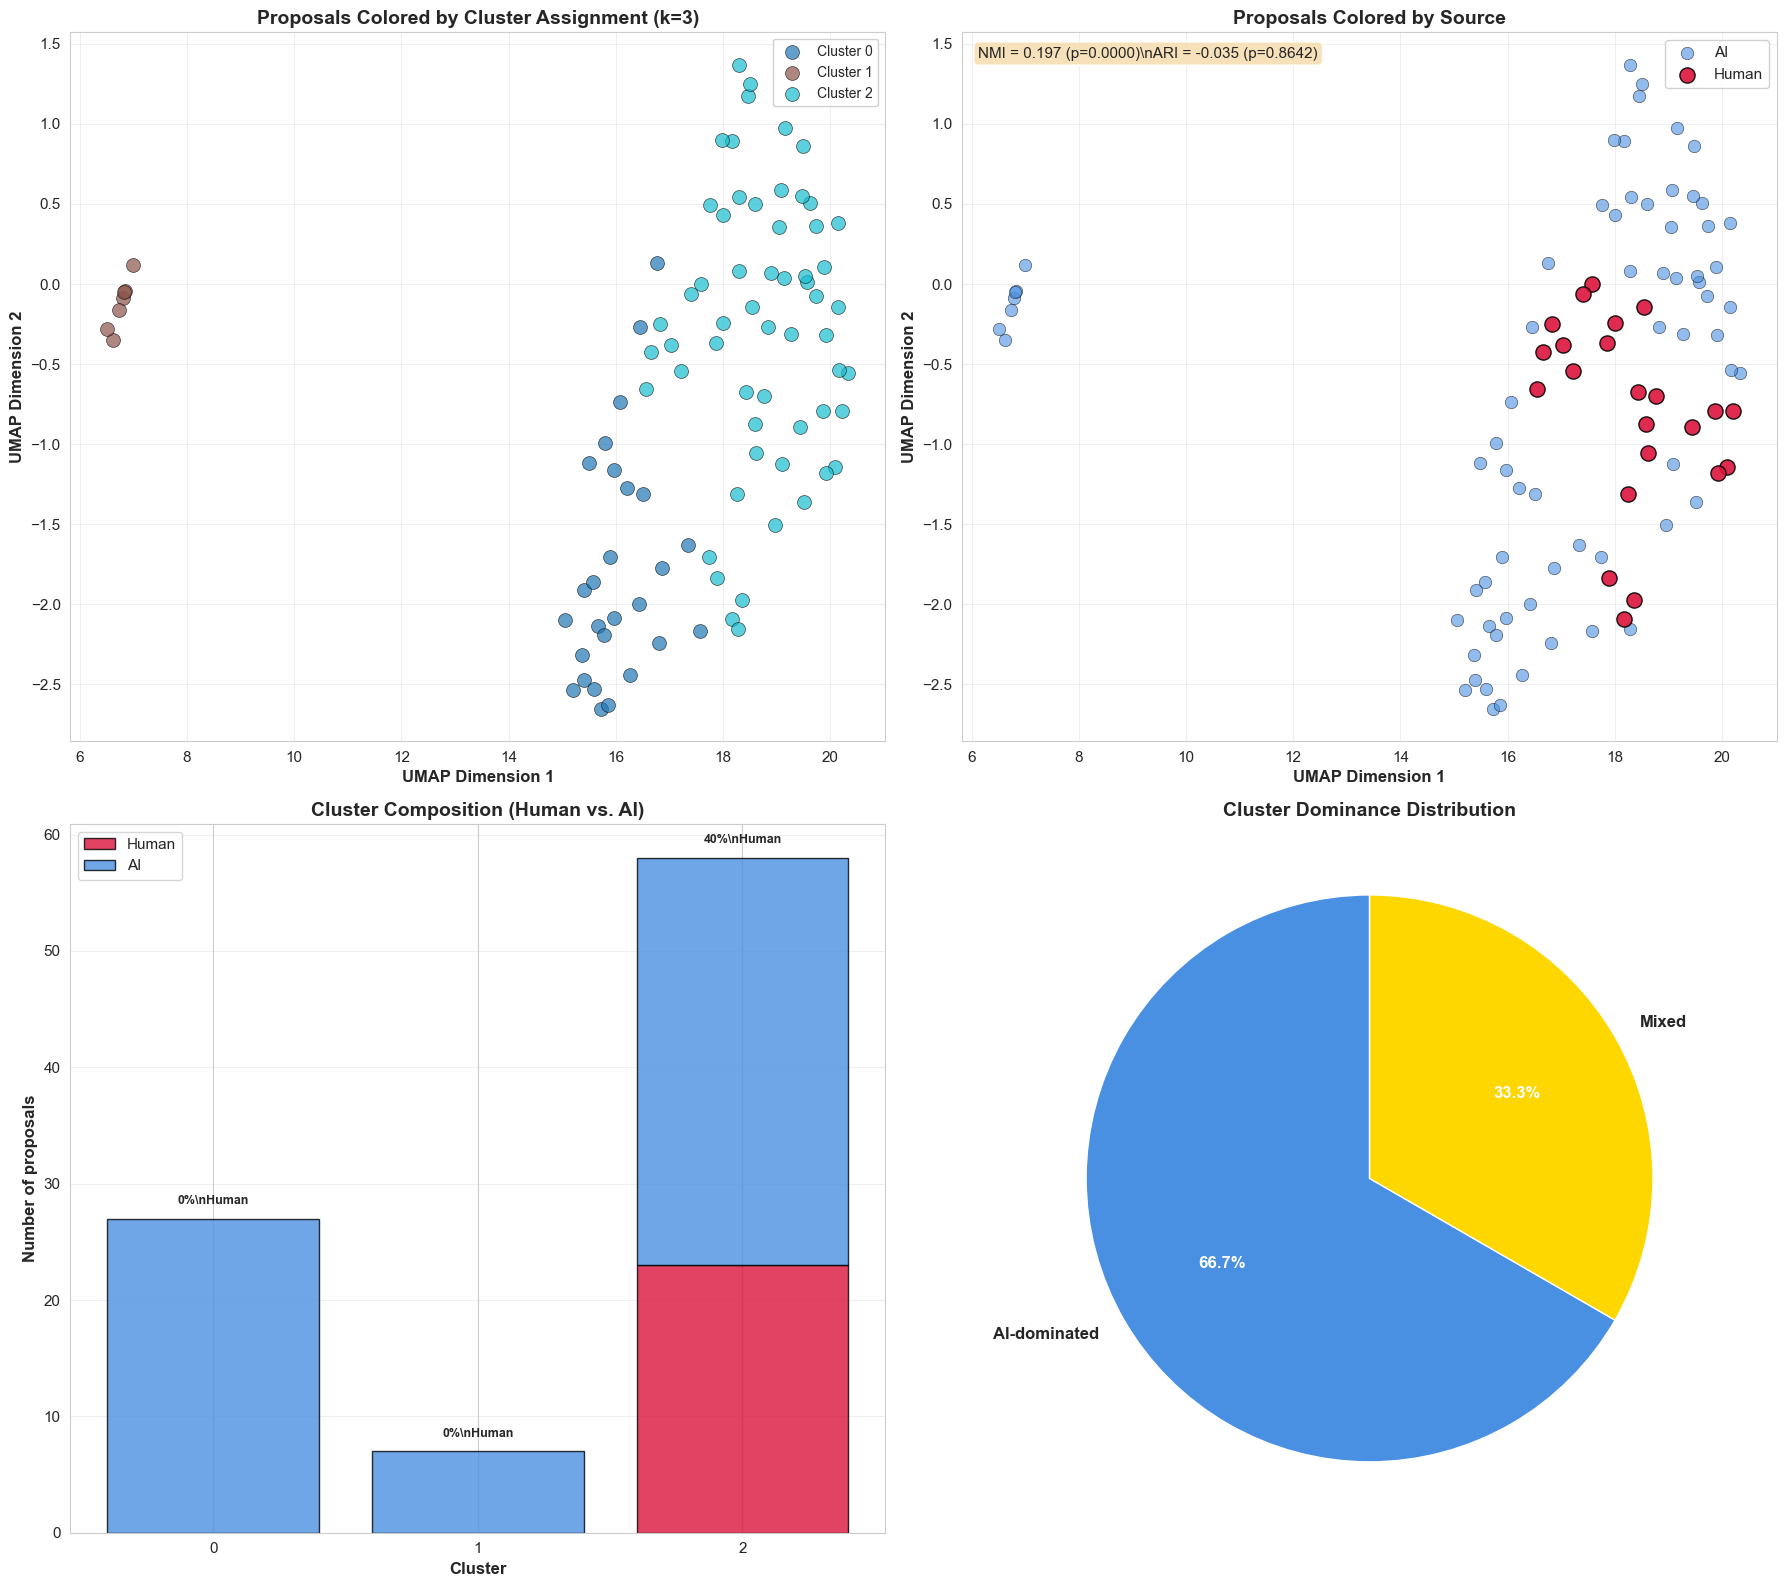

✓ Figure saved to: results/figures/cluster_analysis_visualization.png


In [47]:
import umap
# Visualization: Cluster analysis in 2D embedding space
print("="*85)
print("CLUSTER ANALYSIS: STEP 4 - VISUALIZATION")
print("="*85)

# Use existing UMAP projection from earlier analysis
# Apply UMAP if not already done for this combined set
print("Reducing to 2D with UMAP for visualization...")

reducer_cluster = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_cluster = reducer_cluster.fit_transform(all_embeddings_cluster)

print(f"✓ UMAP projection complete: {embeddings_2d_cluster.shape}")

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Color schemes
source_colors = {'Human': '#DC143C', 'AI': '#4A90E2'}
cluster_colors = plt.cm.tab10(np.linspace(0, 1, best_k))

# Panel 1: Colored by cluster assignment
ax1 = axes[0, 0]
for cluster_id in range(best_k):
    mask = cluster_labels_final == cluster_id
    ax1.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=[cluster_colors[cluster_id]], label=f'Cluster {cluster_id}',
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax1.set_title(f'Proposals Colored by Cluster Assignment (k={best_k})', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)

# Panel 2: Colored by source (Human vs. AI)
ax2 = axes[0, 1]
for source in ['AI', 'Human']:  # Plot AI first, Human on top
    mask = source_labels_cluster == source
    ax2.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=source_colors[source], label=source,
               s=120 if source == 'Human' else 80, 
               alpha=0.9 if source == 'Human' else 0.6,
               edgecolors='black', linewidth=1.0 if source == 'Human' else 0.5)

ax2.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax2.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax2.set_title('Proposals Colored by Source', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3)

# Add NMI and ARI as text
textstr = f'NMI = {nmi_observed:.3f} (p={p_nmi:.4f})\\nARI = {ari_observed:.3f} (p={p_ari:.4f})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Panel 3: Cluster composition (stacked bar chart)
ax3 = axes[1, 0]
cluster_ids = composition_df['cluster'].values
human_counts = composition_df['human'].values
ai_counts = composition_df['ai'].values

ax3.bar(cluster_ids, human_counts, label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
ax3.bar(cluster_ids, ai_counts, bottom=human_counts, label='AI', color='#4A90E2', alpha=0.8, edgecolor='black')

ax3.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of proposals', fontsize=12, fontweight='bold')
ax3.set_title('Cluster Composition (Human vs. AI)', fontsize=14, fontweight='bold')
ax3.set_xticks(cluster_ids)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, cluster_id in enumerate(cluster_ids):
    total = composition_df.loc[i, 'total']
    pct_h = composition_df.loc[i, 'pct_human']
    ax3.text(cluster_id, total + 1, f'{pct_h:.0f}%\\nHuman', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: Cluster dominance pie chart
ax4 = axes[1, 1]
dominance_counts = composition_df['dominance'].value_counts()
colors_pie = {'Human-dominated': '#DC143C', 'AI-dominated': '#4A90E2', 'Mixed': '#FFD700'}
pie_colors = [colors_pie.get(d, 'gray') for d in dominance_counts.index]

wedges, texts, autotexts = ax4.pie(dominance_counts.values, labels=dominance_counts.index, 
                                     autopct='%1.1f%%', startangle=90,
                                     colors=pie_colors, textprops={'fontsize': 12, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax4.set_title('Cluster Dominance Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/baseline/cluster_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/baseline/cluster_analysis_visualization.png")
print("="*85)


### PART III Summary

In [48]:
print("="*85)
print("ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY")
print("="*85)

if 'p_entropy' not in globals():
    p_entropy = p_two_sided if 'p_two_sided' in globals() else np.nan

print()
print("="*85)
print("1. TOPIC MODELING (LDA with n=5 topics)")
print("="*85)
print("  Model: Latent Dirichlet Allocation")
print("  Parameters: alpha=0.5, beta=0.5 (strong regularization)")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print("  Topics identified:")
for i, topic_words in enumerate(topics):
    print(f"    Topic {i+1}: {', '.join(topic_words[:5])}...")

print()
print("="*85)
print("2. TOPIC DISTRIBUTION COMPARISON")
print("="*85)
print("  Overall distribution test (permutation):")
print(f"    Chi-square: {observed_chi2:.4f}, p={p_value_perm:.4f}")
if p_value_perm < 0.05:
    print("    → Significant difference in topic distributions")
else:
    print("    → No significant difference in topic distributions")

print("  Per-topic tests (Fisher's exact with FDR correction):")
significant_topics = fisher_df[fisher_df['p_value_fdr'] < 0.10]
if len(significant_topics) > 0:
    print(f"    {len(significant_topics)} topics show significant over/under-representation:")
    for _, row in significant_topics.iterrows():
        direction = 'Human' if row['odds_ratio'] > 1 else 'AI'
        print(f"      {row['topic']}: OR={row['odds_ratio']:.2f}, p_fdr={row['p_value_fdr']:.4f} ({direction}↑)")
else:
    print("    No topics show significant over/under-representation (FDR q=0.10)")

print()
print("="*85)
print("3. TOPIC COVERAGE AND ENTROPY")
print("="*85)
print("  Coverage (topics with >20% probability):")
print(f"    Human: {human_coverage}/{n_topics} topics")
print(f"    AI: {ai_coverage}/{n_topics} topics")
print("  Exclusive topics (≥5 proposals):")
print(f"    Human-exclusive: {len(human_exclusive)} (p={p_human:.4f})")
print(f"    AI-exclusive: {len(ai_exclusive)} (p={p_ai:.4f})")
print("  Shannon entropy (Miller-Madow corrected):")
print(f"    Human: H={human_entropy:.4f}, H_norm={human_norm_entropy:.4f}")
print(f"    AI (subsampled): H={subsample_entropies.mean():.4f}±{subsample_entropies.std():.4f}")
print(f"    Difference (two-sided): p={p_entropy:.4f}")

print()
print("="*85)
print(f"4. CLUSTER ANALYSIS (GMM with k={best_k})")
print("="*85)
print("  Model selection:")
print(f"    Best k by BIC: {best_k}")
print(f"    Silhouette score: {metrics_df.loc[metrics_df['k']==best_k, 'silhouette'].values[0]:.4f}")
print("  Cluster composition:")
print(f"    Human-dominated clusters: {(composition_df['dominance']=='Human-dominated').sum()}")
print(f"    AI-dominated clusters: {(composition_df['dominance']=='AI-dominated').sum()}")
print(f"    Mixed clusters: {(composition_df['dominance']=='Mixed').sum()}")
print("  Segregation metrics:")
print(f"    NMI: {nmi_observed:.4f} (null: {nmi_null.mean():.4f}±{nmi_null.std():.4f}, p={p_nmi:.4f})")
print(f"    ARI: {ari_observed:.4f} (null: {ari_null.mean():.4f}±{ari_null.std():.4f}, p={p_ari:.4f})")
print(f"    Between/Within distance ratio: {between_within_ratio:.4f} (p={p_ratio:.4f})")

print()
print("="*85)
print("OVERALL INTERPRETATION")
print("="*85)
if p_value_perm < 0.05:
    print("✓ Topics: Human and AI differ in topic distributions")
else:
    print("✓ Topics: No significant difference in topic distributions")

if np.isfinite(p_entropy) and p_entropy < 0.05:
    if diff > 0:
        print("✓ Entropy: Human proposals show higher thematic diversity")
    else:
        print("✓ Entropy: AI proposals show higher thematic diversity")
else:
    print("✓ Entropy: Similar thematic diversity between groups")

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ Clustering: SEGREGATION - Human and AI occupy distinct semantic regions")
    print("  → Generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ Clustering: INTEGRATION - Human and AI ideas are intermixed")
    print("  → Similar ideas regardless of source")
else:
    print("✓ Clustering: INTERMEDIATE - Some thematic patterns but not strict segregation")

print()
print("⚠️  LIMITATIONS:")
print("  • Small sample size (n=23 human, n=69 AI)")
print("  • Topic modeling labeled as EXPLORATORY")
print("  • Results should be validated with larger samples")
print("  • Segregation may reflect prompt differences, not inherent ideation differences")

print()
print("="*85)
print("📊 FIGURES GENERATED:")
print("="*85)
print("  1. results/figures/baseline/cluster_k_selection.png")
print("  2. results/figures/baseline/topic_distribution_comparison.png")
print("  3. results/figures/baseline/cluster_analysis_visualization.png")
print("="*85)


ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY

1. TOPIC MODELING (LDA with n=5 topics)
  Model: Latent Dirichlet Allocation
  Parameters: alpha=0.5, beta=0.5 (strong regularization)
  Perplexity: 1332.58
  Topics identified:
    Topic 1: imaging, open, membrane, proteomics, composition...
    Topic 2: assembly, sequence, capsid, rna, viral...
    Topic 3: molecular, cellular, evolutionary, allosteric, bacterial...
    Topic 4: biology, properties, computational, integrating, interactions...
    Topic 5: chromatin, imaging, single, organization, repair...

2. TOPIC DISTRIBUTION COMPARISON
  Overall distribution test (permutation):
    Chi-square: 68.9744, p=0.0000
    → Significant difference in topic distributions
  Per-topic tests (Fisher's exact with FDR correction):
    3 topics show significant over/under-representation:
      Topic_1: OR=0.00, p_fdr=0.0007 (AI↑)
      Topic_3: OR=231.00, p_fdr=0.0000 (Human↑)
      Topic_4: OR=0.00, p_fdr=0.0010 (AI↑)

3. TOP

----------------------------
# PART IV Style Baseline

Before interpreting embedding distances, clustering segregation (NMI/ARI), or topic separation as “conceptual” differences, quantify how much **purely stylistic** signals can separate Human vs. AI. If a style-only model predicts source well, then a substantial portion of downstream “segregation/diversity” effects may be stylistic rather than conceptual.

### Exract stylistic features

In [49]:
# =============================================================================
# ANALYSIS 2.3.5–2.3.6: STYLE VS CONTENT (Baseline + Style-Controlled Sensitivity)
# Text scope: full proposals (full_text)
# =============================================================================

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ----------------------------
# Style feature extraction
# ----------------------------

_HEDGE_WORDS = {
    'may','might','could','can','suggest','suggests','suggested','potential','potentially',
    'likely','unlikely','possibly','possible','approximately','estimate','estimated',
    'hypothesize','hypothesis','we propose','we aim','we will','we plan'
}

def _tokenize_words(text: str):
    return re.findall(r"[A-Za-z']+", text.lower())

def _split_sentences(text: str):
    # lightweight sentence split for readability/stylistic counts
    sents = re.split(r"[.!?]+\s+|\n+", text.strip())
    return [s for s in (sent.strip() for sent in sents) if s]

def _count_syllables(word: str) -> int:
    # heuristic syllable counter (good enough for comparative readability proxies)
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    w = re.sub(r"e$", "", w)  # silent e
    groups = re.findall(r"[aeiouy]+", w)
    return max(1, len(groups))

def _flesch_kincaid(text: str):
    words = _tokenize_words(text)
    n_words = len(words)
    sents = _split_sentences(text)
    n_sents = len(sents)
    if n_words == 0 or n_sents == 0:
        return np.nan, np.nan
    syllables = sum(_count_syllables(w) for w in words)

    # Flesch Reading Ease & FK Grade Level (English)
    fre = 206.835 - 1.015 * (n_words / n_sents) - 84.6 * (syllables / n_words)
    fkgl = 0.39 * (n_words / n_sents) + 11.8 * (syllables / n_words) - 15.59
    return fre, fkgl

def extract_style_features(text: str) -> dict:
    text = text or ""
    words = _tokenize_words(text)
    n_words = len(words)
    n_chars = len(text)
    sents = _split_sentences(text)
    n_sents = len(sents)

    uniq = len(set(words)) if n_words else 0
    ttr = (uniq / n_words) if n_words else 0.0

    stop_ct = sum(1 for w in words if w in ENGLISH_STOP_WORDS)
    stop_rate = (stop_ct / n_words) if n_words else 0.0

    avg_word_len = (np.mean([len(w) for w in words]) if n_words else 0.0)
    avg_sent_len = (n_words / n_sents) if n_sents else 0.0

    # punctuation / formatting (normalized)
    punct = {
        'comma': text.count(','),
        'semicolon': text.count(';'),
        'colon': text.count(':'),
        'dash': text.count('-') + text.count('–') + text.count('—'),
        'paren': text.count('(') + text.count(')'),
        'quote': text.count('"') + text.count("'"),
        'newline': text.count('\n'),
        'bullet': len(re.findall(r"(^|\n)\s*[-*•]\s+", text))
    }
    punct_rate = {f"{k}_per_1k_chars": (v / max(1, n_chars)) * 1000.0 for k, v in punct.items()}

    # hedging / stance
    low = text.lower()
    hedge_hits = 0
    # count single-token hedges
    hedge_hits += sum(1 for w in words if w in _HEDGE_WORDS)
    # count a few multiword patterns
    hedge_hits += len(re.findall(r"\bwe\s+(propose|aim|plan|will)\b", low))
    hedge_rate = (hedge_hits / n_words) if n_words else 0.0

    # simple headers / sectioning markers (your full_text includes e.g., "Title:", "Abstract:")
    header_lines = 0
    for line in (ln.strip() for ln in text.splitlines()):
        if re.match(r"^[A-Z][A-Za-z0-9 /-]{1,40}:\s+", line):
            header_lines += 1
    header_rate = header_lines

    fre, fkgl = _flesch_kincaid(text)

    feats = {
        'n_words': n_words,
        'n_chars': n_chars,
        'n_sents': n_sents,
        'avg_word_len': avg_word_len,
        'avg_sent_len_words': avg_sent_len,
        'type_token_ratio': ttr,
        'stopword_rate': stop_rate,
        'hedge_rate': hedge_rate,
        'flesch_reading_ease': fre,
        'fk_grade_level': fkgl,
    }
    feats.update(punct_rate)
    return feats

# Build style feature table (full proposals)
human_texts_style = human_df['full_text'].fillna('').tolist()
ai_texts_style = ai_df['full_text'].fillna('').tolist()
all_texts_style = human_texts_style + ai_texts_style

style_rows = [extract_style_features(t) for t in all_texts_style]
style_df = pd.DataFrame(style_rows)
style_df['group'] = (['Human'] * len(human_texts_style)) + (['AI'] * len(ai_texts_style))
style_df['is_ai'] = (style_df['group'] == 'AI').astype(int)

print("="*85)
print("STYLE FEATURES: EXTRACTED")
print("="*85)
print(f"✓ Built style feature table: {style_df.shape[0]} docs × {style_df.shape[1]-2} features")
print(style_df.groupby('group')[['avg_sent_len_words','stopword_rate','hedge_rate','fk_grade_level']].mean().round(3))


STYLE FEATURES: EXTRACTED
✓ Built style feature table: 92 docs × 18 features
       avg_sent_len_words  stopword_rate  hedge_rate  fk_grade_level
group                                                               
AI                 17.728          0.271       0.012          17.147
Human              22.741          0.336       0.014          18.189


#### Visualization: Style feature distributions by group (Human vs each AI model)

**How to read:** Each subplot is one style feature.
- The **box** shows median (center line) and IQR (25th–75th percentile).
- The **black diamond** is the mean, and the **error bar** is ±1 standard deviation.

This makes it easy to compare **median vs mean** (skew/outliers) and overall spread across Human and each AI model.

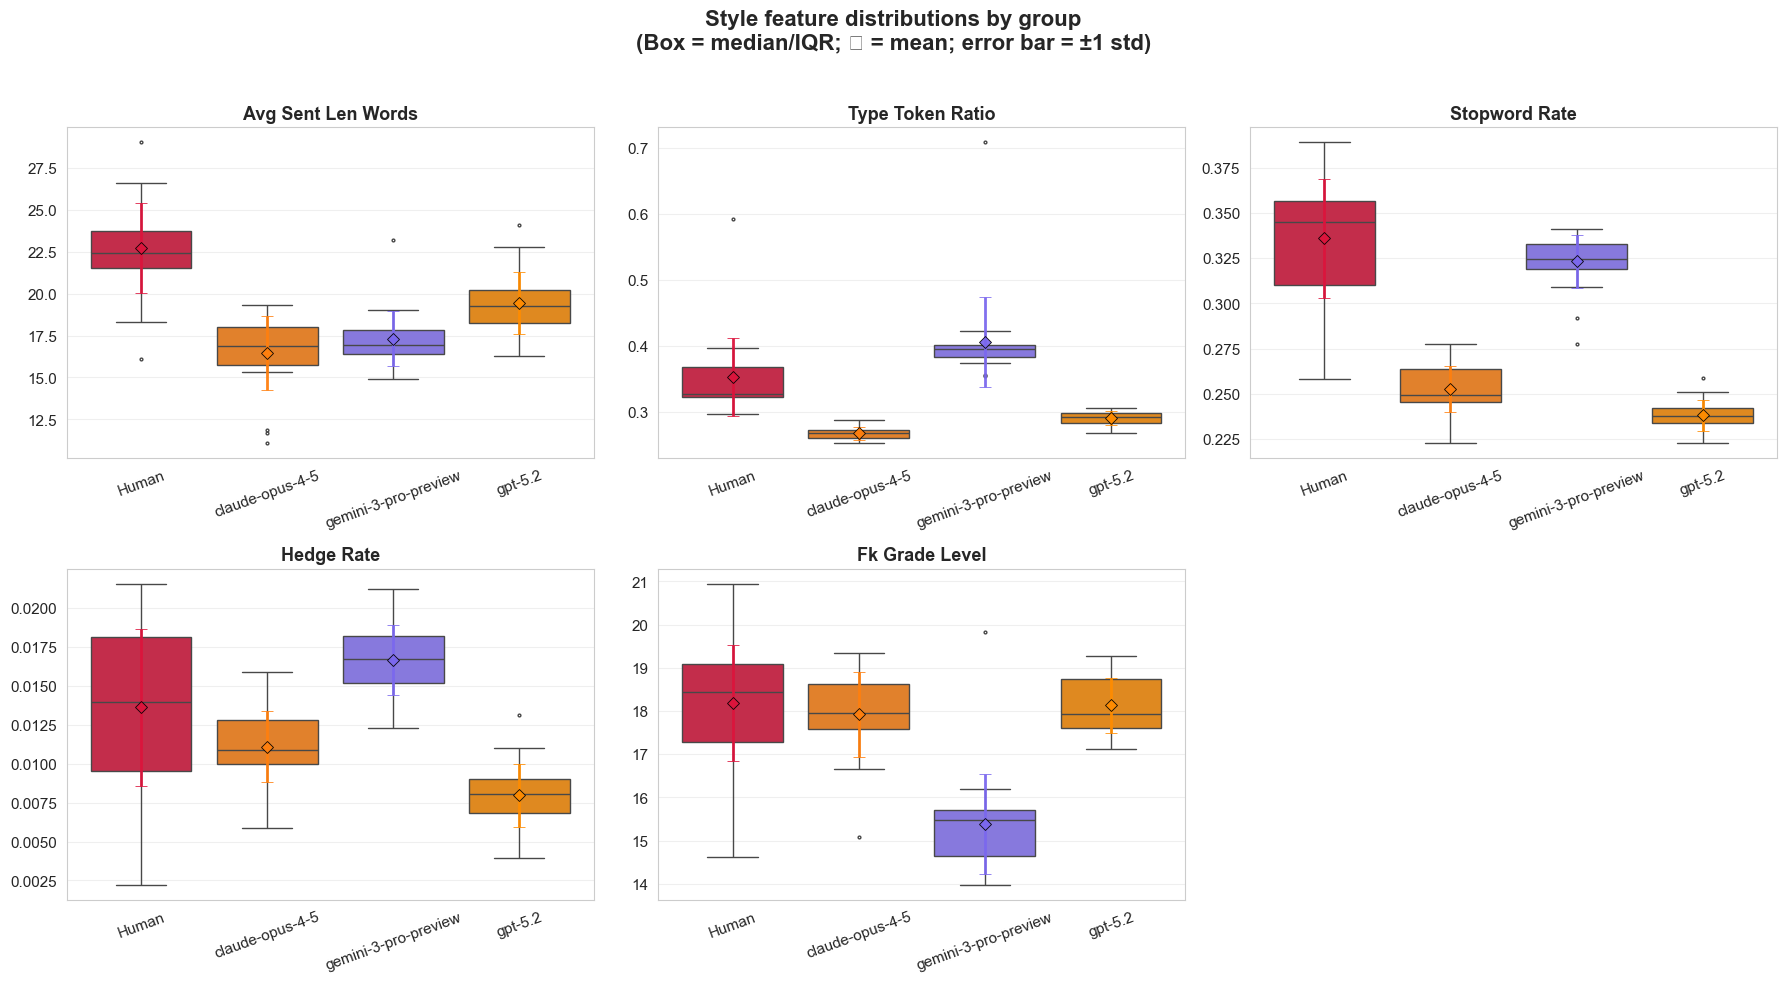

✓ Figure saved to: results/figures/style_features_by_model_boxplots.png

Summary (mean / median / std) by group:
                     avg_sent_len_words                type_token_ratio               stopword_rate               hedge_rate               fk_grade_level               
                                   mean  median    std             mean median    std          mean median    std       mean median    std           mean  median    std
group_model                                                                                                                                                             
Human                            22.741  22.448  2.667            0.353  0.328  0.060         0.336  0.345  0.033      0.014  0.014  0.005         18.189  18.429  1.347
claude-opus-4-5                  16.440  16.855  2.218            0.268  0.268  0.010         0.253  0.249  0.013      0.011  0.011  0.002         17.922  17.948  0.982
gemini-3-pro-preview             17.306  1

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots per feature across Human and each AI model
# Box = median/IQR, whiskers = spread, ◆ = mean, error bar = ±1 std

if 'style_df' not in globals():
    raise RuntimeError("style_df not found. Run the style feature extraction cell first.")
if 'ai_df' not in globals():
    raise RuntimeError("ai_df not found. Run the AI proposal loading cell first.")

# Reconstruct per-model labels aligned to style_df construction order: Human rows first, then AI rows
n_h = int((style_df['group'] == 'Human').sum()) if 'group' in style_df.columns else 0
if n_h == 0:
    n_h = len(human_df)

ai_model_labels = ai_df['model'].tolist()
expected_ai = len(style_df) - n_h
if len(ai_model_labels) != expected_ai:
    raise ValueError(
        f"Alignment error: style_df has {len(style_df)} rows with n_h={n_h}, expected {expected_ai} AI rows, "
        f"but ai_df['model'] has {len(ai_model_labels)} labels."
    )

style_plot = style_df.copy()
style_plot['group_model'] = (['Human'] * n_h) + ai_model_labels

# Compact, interpretable features for quick comparison
features_to_plot = [
    'avg_sent_len_words',
    'type_token_ratio',
    'stopword_rate',
    'hedge_rate',
    'fk_grade_level',
    'header_lines'
]
features_to_plot = [f for f in features_to_plot if f in style_plot.columns]

# Prepare long DF
long_df = style_plot[['group_model'] + features_to_plot].replace([np.inf, -np.inf], np.nan)
for f in features_to_plot:
    long_df[f] = long_df[f].fillna(long_df[f].median())
long_df = long_df.melt(id_vars='group_model', var_name='feature', value_name='value')

# Group order (Human first, then models)
if 'ai_models' in globals():
    group_order = ['Human'] + [m for m in ai_models if m in set(style_plot['group_model'])]
else:
    group_order = ['Human'] + sorted([m for m in style_plot['group_model'].unique() if m != 'Human'])

# Plot subplots
n_feat = len(features_to_plot)
ncols = 3
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

# Use consistent group colors if defined earlier in the notebook
if 'colors' in globals() and isinstance(colors, dict):
    colors_local = dict(colors)
else:
    colors_local = {}

# Ensure every group has a color (fallback for any missing keys)
for idx, g in enumerate(group_order):
    colors_local.setdefault(g, f"C{idx % 10}")

palette_dict = {g: colors_local[g] for g in group_order}

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    df_f = long_df[long_df['feature'] == feat]

    # Boxes colored by group
    sns.boxplot(
        data=df_f, x='group_model', y='value', order=group_order,
        ax=ax, palette=palette_dict, fliersize=2
    )

    # Overlay mean ± std as colored diamonds (matches group color)
    stats = df_f.groupby('group_model')['value'].agg(['mean', 'std']).reindex(group_order)
    for xpos, g in enumerate(group_order):
        if g not in stats.index or pd.isna(stats.loc[g, 'mean']):
            continue
        m = float(stats.loc[g, 'mean'])
        s = float(stats.loc[g, 'std']) if not pd.isna(stats.loc[g, 'std']) else 0.0
        ax.errorbar(
            xpos, m, yerr=s,
            fmt='D',
            color=colors_local[g], ecolor=colors_local[g],
            elinewidth=2, capsize=4,
            markersize=6,
            markeredgecolor='black', markeredgewidth=0.6,
            alpha=0.95,
            zorder=10
        )

    ax.set_title(feat.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Style feature distributions by group\n(Box = median/IQR; ◆ = mean; error bar = ±1 std)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

out_path = 'results/figures/baseline/style_features_by_model_boxplots.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")

# Print a compact table of mean/median/std
summary = style_plot.groupby('group_model')[features_to_plot].agg(['mean', 'median', 'std']).round(3)
print("\nSummary (mean / median / std) by group:")
print(summary.to_string())


### Analysis 2.3.5: Style-only baseline (can style predict source?)

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

print("="*85)
print("STYLE-ONLY BASELINE: HUMAN VS AI")
print("="*85)

feature_cols = [c for c in style_df.columns if c not in {'group','is_ai'}]
X = style_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = style_df['is_ai'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear', random_state=42)
)

auc_scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
bal_scores = cross_val_score(clf, X, y, cv=cv, scoring='balanced_accuracy')

print(f"CV AUROC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
print(f"CV balanced accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")

obs_score, perm_scores, p_value = permutation_test_score(
    clf, X, y, cv=cv, scoring='roc_auc', n_permutations=1000, n_jobs=-1, random_state=42
)

print()
print("Permutation test (AUROC, 1,000 label shuffles):")
print(f"  Observed AUROC: {obs_score:.3f}")
print(f"  Null mean AUROC: {perm_scores.mean():.3f} ± {perm_scores.std():.3f}")
print(f"  p-value: {p_value:.4f}")
print("  Note: Imputation now occurs INSIDE each CV fold (no leakage).")

if obs_score >= 0.80:
    print("  → Strong evidence that style alone separates Human vs AI.")
elif obs_score >= 0.60:
    print("  → Moderate evidence that style contributes to separation.")
else:
    print("  → Style-only separation is weak; downstream separation is less likely to be purely stylistic.")


STYLE-ONLY BASELINE: HUMAN VS AI
CV AUROC: 0.997 ± 0.006
CV balanced accuracy: 0.992 ± 0.015

Permutation test (AUROC, 1,000 label shuffles):
  Observed AUROC: 0.997
  Null mean AUROC: 0.505 ± 0.096
  p-value: 0.0010
  Note: Imputation now occurs INSIDE each CV fold (no leakage).
  → Strong evidence that style alone separates Human vs AI.


#### Visualization: Style-only baseline results (CV + permutation test)

**How to read:** Left panel shows cross-validation fold performance (each dot = one CV fold; box = distribution). Right panel shows the permutation-test *null* distribution of AUROC when Human/AI labels are shuffled; the vertical red line is the observed AUROC—if it sits far in the right tail, style alone separates groups beyond chance (small p-value).

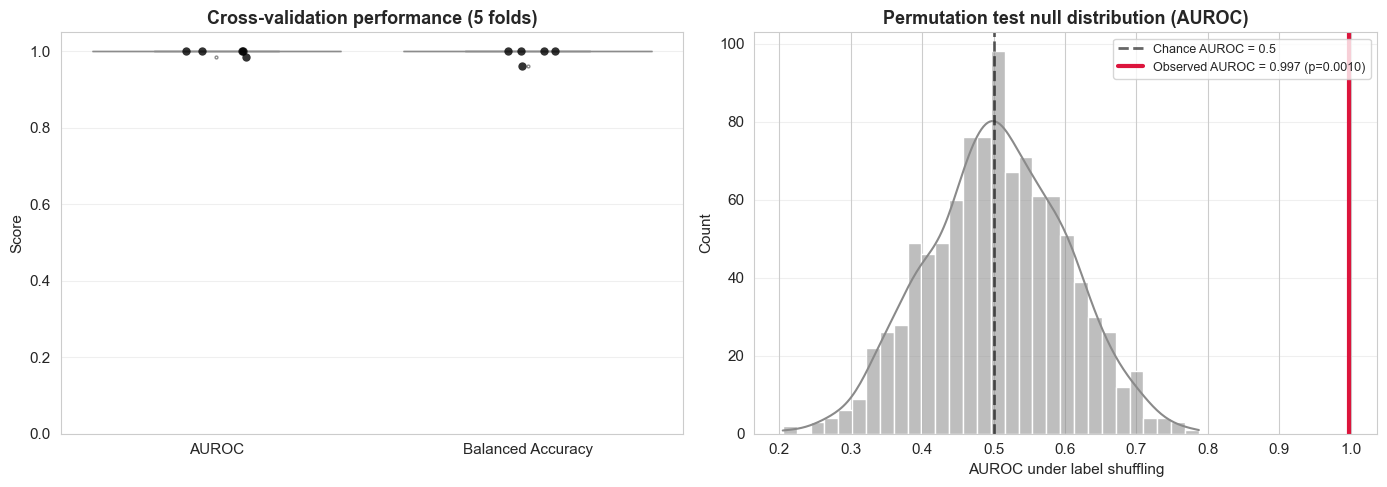

✓ Figure saved to: results/figures/style_only_baseline_viz.png

Interpretation:
- Left: tighter boxes/points = stable CV estimates; higher = better separation.
- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).


In [52]:
# Visualization for style-only baseline results
import matplotlib.pyplot as plt

# 1) CV fold distributions (AUROC + balanced accuracy)
cv_plot_df = pd.DataFrame({
    'Fold': np.arange(1, len(auc_scores) + 1),
    'AUROC': auc_scores,
    'Balanced Accuracy': bal_scores,
})
cv_long = cv_plot_df.melt(id_vars='Fold', var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV score distributions
ax = axes[0]
sns.boxplot(data=cv_long, x='Metric', y='Score', ax=ax, color='#DDE6F5', fliersize=2)
sns.stripplot(data=cv_long, x='Metric', y='Score', ax=ax, color='black', size=6, jitter=0.12, alpha=0.8)
ax.set_title('Cross-validation performance (5 folds)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Right: permutation null distribution
ax = axes[1]
sns.histplot(perm_scores, bins=30, kde=True, ax=ax, color='#8A8A8A', alpha=0.55)
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Chance AUROC = 0.5')
ax.axvline(obs_score, color='crimson', linestyle='-', linewidth=3,
           label=f'Observed AUROC = {obs_score:.3f} (p={p_value:.4f})')
ax.set_title('Permutation test null distribution (AUROC)', fontsize=13, fontweight='bold')
ax.set_xlabel('AUROC under label shuffling')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()

out_path = 'results/figures/baseline/style_only_baseline_viz.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")
print("\nInterpretation:")
print("- Left: tighter boxes/points = stable CV estimates; higher = better separation.")
print("- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).")


### Analysis 2.3.6A: Style-controlled sensitivity via residualization

In [53]:
from sklearn.metrics.pairwise import cosine_distances

print("="*85)
print("STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)")
print("="*85)

if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found in workspace variables (expected `human_embeddings` and `ai_embeddings`).")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    group = np.array([0] * len(E_h) + [1] * len(E_a))  # 0=Human, 1=AI

    # Style covariates (compact set)
    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    cov = StandardScaler().fit_transform(cov)

    # Outcomes from embeddings
    centroid_all = E.mean(axis=0, keepdims=True)
    dist_to_all = cosine_distances(E, centroid_all).ravel()

    centroid_h = E_h.mean(axis=0, keepdims=True)
    centroid_a = E_a.mean(axis=0, keepdims=True)
    dist_to_group = np.where(group == 0,
                             cosine_distances(E, centroid_h).ravel(),
                             cosine_distances(E, centroid_a).ravel())

    def _ols_group_coef(y, g, covariates):
        X = np.column_stack([np.ones(len(y)), g.astype(float), covariates])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta[1], beta

    def perm_test_group_coef(y, g, covariates, n_perm=5000, seed=42):
        rng = np.random.default_rng(seed)
        obs_coef, _ = _ols_group_coef(y, g, covariates)
        null = np.zeros(n_perm, dtype=float)
        for i in range(n_perm):
            g_perm = rng.permutation(g)
            null[i], _ = _ols_group_coef(y, g_perm, covariates)
        p_two = (np.mean(np.abs(null) >= abs(obs_coef)) + 1) / (n_perm + 1)
        return obs_coef, null, p_two

    def summarize_outcome(name, y):
        mean_h = float(np.mean(y[group == 0]))
        mean_a = float(np.mean(y[group == 1]))
        print(f"\nOutcome: {name}")
        print(f"  Unadjusted means: Human={mean_h:.4f}, AI={mean_a:.4f}, (AI-Human)={mean_a-mean_h:+.4f}")
        coef, null, p = perm_test_group_coef(y, group, cov, n_perm=5000, seed=42)
        print(f"  Style-adjusted group coef (AI indicator): {coef:+.6f}")
        print(f"  Permutation p (two-sided, 5,000 shuffles): {p:.4f}")

    summarize_outcome('Cosine distance to overall centroid', dist_to_all)
    summarize_outcome('Cosine distance to own-group centroid', dist_to_group)


STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)

Outcome: Cosine distance to overall centroid
  Unadjusted means: Human=0.0393, AI=0.0901, (AI-Human)=+0.0508
  Style-adjusted group coef (AI indicator): -0.059916
  Permutation p (two-sided, 5,000 shuffles): 0.0002

Outcome: Cosine distance to own-group centroid
  Unadjusted means: Human=0.0321, AI=0.0894, (AI-Human)=+0.0573
  Style-adjusted group coef (AI indicator): -0.054069
  Permutation p (two-sided, 5,000 shuffles): 0.0002


### Style-adjusted centroid dispersion (All Groups vs Human)


These tests repeat the same Mann–Whitney U, Cliff’s delta, and permutation test comparisons as the unadjusted centroid-dispersion section, but using **style-adjusted (residualized)** distances-to-own-group-centroid.

Compute each proposal’s distance-to-its-group-centroid (y_raw).
Fit a simple linear model: y_raw ~ (style features).
Subtract the model’s prediction from y_raw to get a residual.
Add back the overall mean (just to keep numbers on a similar scale).
Result: y_adj = “dispersion after removing what style can explain”.
Statistical tests on style-adjusted dispersion:
Same tests, just run on y_adj instead of y_raw.
So your MW / Cliff’s delta / permutation test become: “Are groups still different in dispersion after removing style effects?”

In [54]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("\n" + "="*85)
print("STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)")
print("="*85)

# ---- helpers (define if not already in notebook) ----
if 'cliffs_delta' not in globals():
    def cliffs_delta(x, y):
        """Cliff's delta: P(x>y) - P(x<y)."""
        x = np.asarray(x)
        y = np.asarray(y)
        gt = 0
        lt = 0
        for xi in x:
            gt += np.sum(xi > y)
            lt += np.sum(xi < y)
        return (gt - lt) / (len(x) * len(y))

if 'interpret_cliffs_delta' not in globals():
    def interpret_cliffs_delta(d):
        ad = abs(d)
        if ad < 0.147:
            return 'negligible'
        if ad < 0.33:
            return 'small'
        if ad < 0.474:
            return 'medium'
        return 'large'

def _perm_test_mean_diff(x, y, n_perm=10000, seed=42):
    """Two-sided permutation test on mean difference: mean(x)-mean(y).

    Named uniquely to avoid conflicts with any earlier `permutation_test()` defined elsewhere in the notebook.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    obs = float(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y])
    n_x = len(x)
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        null[i] = float(np.mean(perm[:n_x]) - np.mean(perm[n_x:]))
    p = (np.mean(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    return p, obs, null

# ---- compute y_adj robustly (don’t assume previous cell variables exist) ----
if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
elif 'ai_df' not in globals() or 'model_embeddings_dict' not in globals():
    print("⚠️ ai_df/model_embeddings_dict not found. Run the proposal loading/embedding setup cells first.")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    n_h, n_a = len(E_h), len(E_a)

    # Labels (Human first, then AI per-model)
    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"
    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Group order consistent with earlier analyses
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    # Raw distance-to-own-group-centroid
    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization on y_raw
    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()

    # Split adjusted distances
    human_adj = y_adj[labels == 'Human']
    ai_adj = y_adj[labels != 'Human']

    model_adj = {m: y_adj[labels == m] for m in group_order if m != 'Human'}

    # ---- tests ----
    adj_comparison_results = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]")
    print("-"*85)

    u_stat, p_mw = mannwhitneyu(ai_adj, human_adj, alternative='two-sided')
    d = cliffs_delta(ai_adj, human_adj)
    d_interp = interpret_cliffs_delta(d)
    p_perm, obs_diff, _ = _perm_test_mean_diff(ai_adj, human_adj, n_perm=10000, seed=42)

    print("\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat:,.0f}, p-value: {p_mw:.4e}")
    print("\nCliff's Delta:")
    print(f"  δ = {d:.4f} ({d_interp} effect)")
    if d > 0:
        print("  → All AI proposals are MORE dispersed from center (after style adjustment)")
    else:
        print("  → Human proposals are MORE dispersed from center (after style adjustment)")
    print("\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference (mean AI - mean Human): {obs_diff:.4f}, p-value: {p_perm:.4f}")

    adj_comparison_results.append({
        'group': 'All AI',
        'u_stat': u_stat,
        'p_value_mw': p_mw,
        'delta': d,
        'delta_interp': d_interp,
        'p_value_perm': p_perm
    })

    for model in group_order:
        if model == 'Human':
            continue
        vals = model_adj.get(model)
        if vals is None or len(vals) == 0:
            continue

        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human [STYLE-ADJUSTED]")
        print("-"*85)

        u_stat_m, p_mw_m = mannwhitneyu(vals, human_adj, alternative='two-sided')
        d_m = cliffs_delta(vals, human_adj)
        d_interp_m = interpret_cliffs_delta(d_m)
        p_perm_m, obs_diff_m, _ = _perm_test_mean_diff(vals, human_adj, n_perm=10000, seed=42)

        print("\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_m:,.0f}, p-value: {p_mw_m:.4e}")
        print("\nCliff's Delta:")
        print(f"  δ = {d_m:.4f} ({d_interp_m} effect)")
        if d_m > 0:
            print(f"  → {model} proposals are MORE dispersed from center (after style adjustment)")
        else:
            print("  → Human proposals are MORE dispersed from center (after style adjustment)")
        print("\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference (mean {model} - mean Human): {obs_diff_m:.4f}, p-value: {p_perm_m:.4f}")

        adj_comparison_results.append({
            'group': model,
            'u_stat': u_stat_m,
            'p_value_mw': p_mw_m,
            'delta': d_m,
            'delta_interp': d_interp_m,
            'p_value_perm': p_perm_m
        })

    # Summary table
    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - Style-adjusted Centroid Dispersion")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for r in adj_comparison_results:
        print(f"{r['group']:<30} {r['delta']:<12.4f} {r['delta_interp']:<20} {r['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed (style-adjusted)")
    print("="*85)



STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 451, p-value: 2.0437e-03

Cliff's Delta:
  δ = -0.4316 (medium effect)
  → Human proposals are MORE dispersed from center (after style adjustment)

Permutation Test (10,000 permutations):
  Observed difference (mean AI - mean Human): -0.0089, p-value: 0.0002

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 218, p-value: 3.1222e-01

Cliff's Delta:
  δ = -0.1758 (small effect)
  → Human proposals are MORE dispersed from center (after style 

CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)


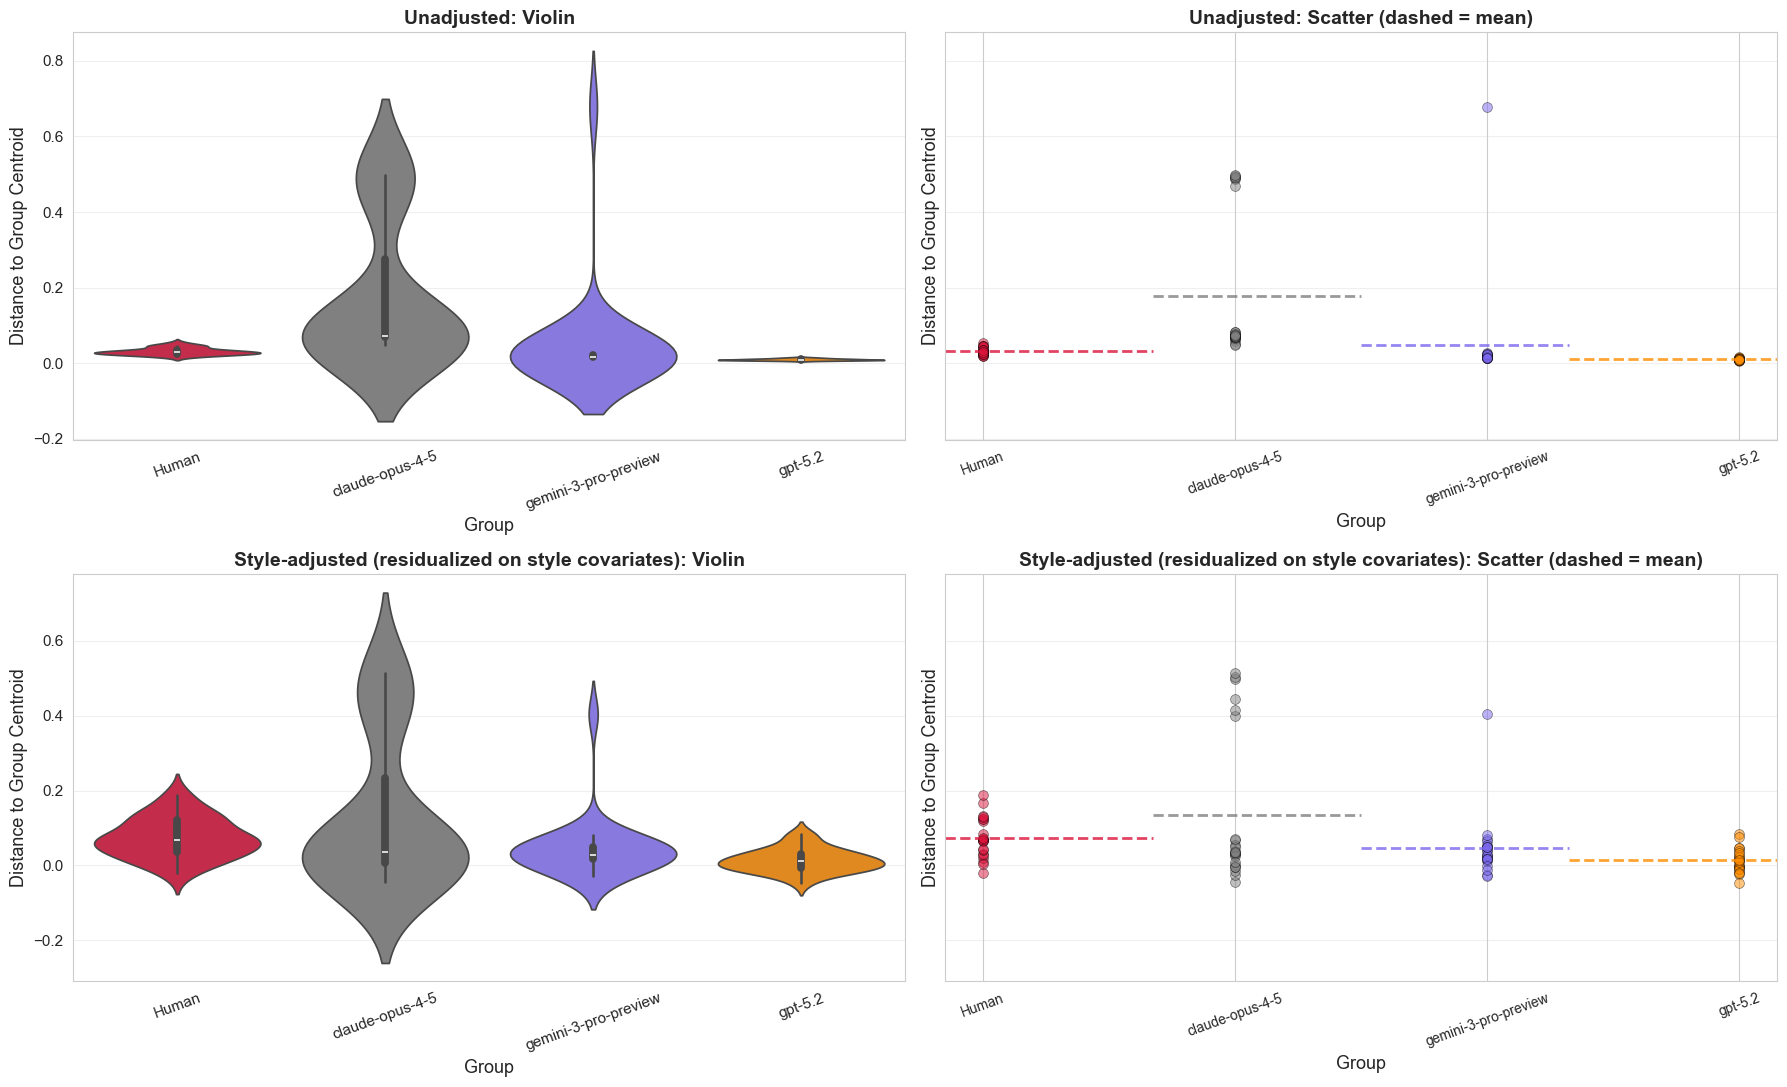

✓ Figure saved to: results/figures/centroid_dispersion_style_adjusted.png

Note: 'Style-adjusted' removes linear effects of selected style covariates (not group).


In [55]:
# ----------------------------
# Visualization: centroid dispersion before vs after style residualization
# ----------------------------

from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

print("="*85)
print("CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # Labels (Human first, then AI) — match the style_df construction order
    n_h = len(human_embeddings)
    n_a = len(ai_embeddings)

    # Prefer the notebook's model list if available; otherwise derive from ai_df
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())

    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"

    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Embeddings matrix
    E = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    # Compute distance-to-own-group-centroid for each proposal (Human + each AI model)
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization (remove linear effect of style covariates; keep scale comparable)
    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()  # residuals shifted back to original mean

    # Colors: reuse if present, else define a fallback
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = colors
    else:
        colors_local = {'Human': '#DC143C'}
        for i, m in enumerate(group_order[1:]):
            colors_local[m] = f"C{(i+1)%10}"

    def _plot_row(ax_violin, ax_scatter, y, row_title):
        # Build long DF
        plot_df = pd.DataFrame({'Group': labels, 'Distance to Centroid': y})

        palette_list = [colors_local.get(g, 'gray') for g in group_order]

        sns.violinplot(
            data=plot_df, x='Group', y='Distance to Centroid',
            order=group_order, palette=palette_list, ax=ax_violin
        )
        ax_violin.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_violin.set_xlabel('Group', fontsize=13)
        ax_violin.set_title(f'{row_title}: Violin', fontsize=14, fontweight='bold')
        ax_violin.tick_params(axis='x', rotation=20)
        ax_violin.grid(alpha=0.3, axis='y')

        # Scatter with per-group mean lines
        for xpos, g in enumerate(group_order):
            vals = plot_df.loc[plot_df['Group'] == g, 'Distance to Centroid'].values
            if len(vals) == 0:
                continue
            ax_scatter.scatter(
                [xpos] * len(vals), vals,
                alpha=0.5, color=colors_local.get(g, 'gray'),
                s=50, edgecolors='black', linewidth=0.5
            )
            ax_scatter.axhline(
                np.mean(vals),
                xmin=xpos/len(group_order), xmax=(xpos+1)/len(group_order),
                color=colors_local.get(g, 'gray'), linestyle='--', linewidth=2, alpha=0.8
            )

        ax_scatter.set_xticks(range(len(group_order)))
        ax_scatter.set_xticklabels(group_order, rotation=20, fontsize=10)
        ax_scatter.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_scatter.set_xlabel('Group', fontsize=13)
        ax_scatter.set_title(f'{row_title}: Scatter (dashed = mean)', fontsize=14, fontweight='bold')
        ax_scatter.grid(alpha=0.3, axis='y')

    fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharey='row')
    _plot_row(axes[0, 0], axes[0, 1], y_raw, 'Unadjusted')
    _plot_row(axes[1, 0], axes[1, 1], y_adj, 'Style-adjusted (residualized on style covariates)')

    plt.tight_layout()
    out_path = 'results/figures/baseline/centroid_dispersion_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Figure saved to: {out_path}")
    print("\nNote: 'Style-adjusted' removes linear effects of selected style covariates (not group).")


### Style-adjust nearest-neighbor (NN) distances by residualizing embeddings


This removes the *linear* contribution of selected style covariates from the embedding vectors (dimension-wise OLS), then recomputes cosine NN distances on the residual embeddings (renormalized).

STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)

COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.5553     0.6074     0.2211     0.7684    

claude-opus-4-5                     23       0.2888     0.2838     0.0792     0.5170    
gemini-3-pro-preview                23       0.4047     0.3988     0.1299     0.7255    
gpt-5.2                             23       0.4028     0.3858     0.2019     0.7147    

All AI (combined)                   69       0.3654     0.3724     0.0792     0.7255    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together
   - Distances are computed AFTER removing linear embedding variation explained by style covariates

O

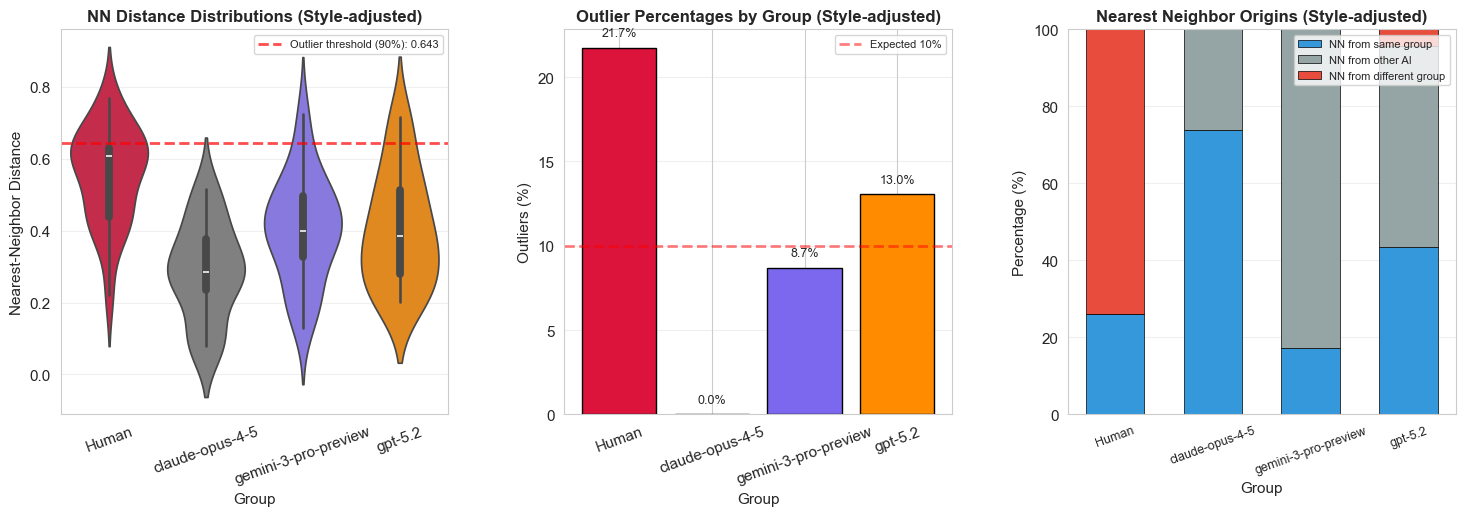


✓ Figure saved to: results/figures/nearest_neighbor_by_model_style_adjusted.png

Note: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.


In [56]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("="*85)
print("STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # ----------------------------
    # 0) Build per-row labels that match embedding order
    # ----------------------------
    n_human = len(human_embeddings)
    n_ai = len(ai_embeddings)

    if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
        ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
    elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
        print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
        ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
    else:
        raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

    labels = np.array((['Human'] * n_human) + ai_model_labels)

    # Stable group order
    if 'ai_models' in globals():
        ai_models_local = [m for m in list(ai_models) if m in set(ai_model_labels)]
    else:
        ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

    group_order = ['Human'] + ai_models_local

    # ----------------------------
    # 1) Build embedding matrix (Human first, then AI) and residualize on style
    # ----------------------------
    all_embeddings = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(X_cov)), X_cov])

    B, *_ = np.linalg.lstsq(X, all_embeddings, rcond=None)
    all_embeddings_resid = all_embeddings - (X @ B)
    all_embeddings_resid = all_embeddings_resid / (np.linalg.norm(all_embeddings_resid, axis=1, keepdims=True) + 1e-12)

    # ----------------------------
    # 2) Compute full distance matrix + NN distances (STYLE-ADJUSTED)
    # ----------------------------
    print("\n" + "="*85)
    print("COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
    print("="*85)

    all_distances_adj = cosine_distances(all_embeddings_resid)
    np.fill_diagonal(all_distances_adj, np.inf)
    nn_distances_adj = all_distances_adj.min(axis=1)

    # Group-wise NN distances
    human_nn_dists_adj = nn_distances_adj[labels == 'Human']
    ai_nn_dists_adj = nn_distances_adj[labels != 'Human']

    model_nn_dists_adj = {g: nn_distances_adj[labels == g] for g in ai_models_local}

    # Print statistics table
    print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
    print("-"*85)
    print(f"{'Human':<35} {len(human_nn_dists_adj):<8} {human_nn_dists_adj.mean():<10.4f} {np.median(human_nn_dists_adj):<10.4f} {human_nn_dists_adj.min():<10.4f} {human_nn_dists_adj.max():<10.4f}")
    print()
    for model in ai_models_local:
        dists = model_nn_dists_adj[model]
        print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")
    print()
    print(f"{'All AI (combined)':<35} {len(ai_nn_dists_adj):<8} {ai_nn_dists_adj.mean():<10.4f} {np.median(ai_nn_dists_adj):<10.4f} {ai_nn_dists_adj.min():<10.4f} {ai_nn_dists_adj.max():<10.4f}")

    print("="*85)
    print("\n💡 INTERPRETATION:")
    print("   - Higher mean NN distance = more isolated proposals (outliers)")
    print("   - Lower mean NN distance = proposals cluster together")
    print("   - Distances are computed AFTER removing linear embedding variation explained by style covariates")
    print("="*85)

    # ----------------------------
    # 3) Outlier detection (top 10% NN distances) - STYLE-ADJUSTED
    # ----------------------------
    threshold_adj = np.percentile(nn_distances_adj, 90)
    outliers_adj = nn_distances_adj > threshold_adj

    human_outliers_adj = int(outliers_adj[labels == 'Human'].sum())
    ai_outliers_adj = int(outliers_adj[labels != 'Human'].sum())
    model_outliers_adj = {g: int(outliers_adj[labels == g].sum()) for g in ai_models_local}

    print("\n" + "="*85)
    print("OUTLIER DETECTION (Top 10% NN distance) — STYLE-ADJUSTED")
    print("="*85)
    print(f"Threshold distance: {threshold_adj:.4f}")
    print()
    print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
    print("-"*85)
    print(f"{'Human':<35} {human_outliers_adj:<15} {n_human:<10} {human_outliers_adj/n_human*100:<15.1f}%")
    print()
    for model in ai_models_local:
        n_model = int((labels == model).sum())
        print(f"{model:<35} {model_outliers_adj[model]:<15} {n_model:<10} {model_outliers_adj[model]/n_model*100:<15.1f}%")
    print()
    print(f"{'All AI (combined)':<35} {ai_outliers_adj:<15} {n_ai:<10} {ai_outliers_adj/n_ai*100:<15.1f}%")
    print("="*85)

    # ----------------------------
    # 4) Nearest-neighbor origin analysis — STYLE-ADJUSTED
    # ----------------------------
    nn_indices_adj = all_distances_adj.argmin(axis=1)
    nn_labels_adj = labels[nn_indices_adj]

    human_nn_same_group_adj = int((nn_labels_adj[labels == 'Human'] == 'Human').sum())
    human_nn_diff_group_adj = int(n_human - human_nn_same_group_adj)

    ai_nn_same_group_adj = int((nn_labels_adj[labels != 'Human'] != 'Human').sum())
    ai_nn_diff_group_adj = int(n_ai - ai_nn_same_group_adj)

    model_nn_analysis_adj = {}
    for model in ai_models_local:
        mask = labels == model
        total = int(mask.sum())
        nn_from_human = int((nn_labels_adj[mask] == 'Human').sum())
        nn_from_same_model = int((nn_labels_adj[mask] == model).sum())
        nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)
        model_nn_analysis_adj[model] = {
            'from_human': nn_from_human,
            'from_same_model': nn_from_same_model,
            'from_other_ai': nn_from_other_ai,
            'total': total
        }

    print("\n" + "="*85)
    print("NEAREST NEIGHBOR GROUP ANALYSIS — STYLE-ADJUSTED")
    print("="*85)

    print(f"\n{'Human proposals:':<50}")
    print(f"  NN from same group (human): {human_nn_same_group_adj} ({human_nn_same_group_adj/n_human*100:.1f}%)")
    print(f"  NN from different group (AI): {human_nn_diff_group_adj} ({human_nn_diff_group_adj/n_human*100:.1f}%)")

    print(f"\n{'All AI proposals (combined):':<50}")
    print(f"  NN from same group (AI): {ai_nn_same_group_adj} ({ai_nn_same_group_adj/n_ai*100:.1f}%)")
    print(f"  NN from different group (human): {ai_nn_diff_group_adj} ({ai_nn_diff_group_adj/n_ai*100:.1f}%)")

    print("\n" + "-"*85)
    print("Per-Model NN Group Breakdown:")
    print("-"*85)

    for model in ai_models_local:
        data = model_nn_analysis_adj[model]
        print(f"\n{model}:")
        print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
        print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
        print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

    print("\n" + "="*85)
    print("\n💡 INTERPRETATION:")
    print("   - High 'NN from same model' = model produces similar proposals")
    print("   - High 'NN from Human' = model proposals resemble human work")
    print("   - All computed in style-adjusted residual embedding space")
    print("="*85)

    # ----------------------------
    # 5) Statistical tests vs Human (same tests) — STYLE-ADJUSTED
    # ----------------------------
    print("\n" + "="*85)
    print("STATISTICAL TESTS: NN Distances (All Groups vs Human) — STYLE-ADJUSTED")
    print("="*85)

    nn_comparison_results_adj = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human")
    print("-"*85)

    u_stat_nn, p_value_nn = mannwhitneyu(ai_nn_dists_adj, human_nn_dists_adj, alternative='two-sided')
    delta_nn = cliffs_delta(ai_nn_dists_adj, human_nn_dists_adj)
    delta_nn_interp = interpret_cliffs_delta(delta_nn)
    p_value_perm_nn, obs_diff_nn, _ = permutation_test(ai_nn_dists_adj, human_nn_dists_adj)

    print(f"\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat_nn:,.0f}, p-value: {p_value_nn:.4e}")
    print(f"\nCliff's Delta:")
    print(f"  δ = {delta_nn:.4f} ({delta_nn_interp} effect)")
    if delta_nn > 0:
        print(f"  → All AI proposals have MORE unique/outlier ideas (style-adjusted)")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
    print(f"\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference: {obs_diff_nn:.4f}, p-value: {p_value_perm_nn:.4f}")

    nn_comparison_results_adj.append({
        'group': 'All AI',
        'u_stat': u_stat_nn,
        'p_value_mw': p_value_nn,
        'delta': delta_nn,
        'delta_interp': delta_nn_interp,
        'p_value_perm': p_value_perm_nn
    })

    for model in ai_models_local:
        if model in model_nn_dists_adj:
            print("\n" + "-"*85)
            print(f"Comparison: {model} vs Human")
            print("-"*85)

            u_stat_model, p_value_mw_model = mannwhitneyu(model_nn_dists_adj[model], human_nn_dists_adj, alternative='two-sided')
            delta_model = cliffs_delta(model_nn_dists_adj[model], human_nn_dists_adj)
            delta_interp_model = interpret_cliffs_delta(delta_model)
            p_value_perm_model, obs_diff_model, _ = permutation_test(model_nn_dists_adj[model], human_nn_dists_adj)

            print(f"\nMann-Whitney U Test:")
            print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
            print(f"\nCliff's Delta:")
            print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
            if delta_model > 0:
                print(f"  → {model} proposals have MORE unique/outlier ideas (style-adjusted)")
            else:
                print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
            print(f"\nPermutation Test (10,000 permutations):")
            print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")

            nn_comparison_results_adj.append({
                'group': model,
                'u_stat': u_stat_model,
                'p_value_mw': p_value_mw_model,
                'delta': delta_model,
                'delta_interp': delta_interp_model,
                'p_value_perm': p_value_perm_model
            })

    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - NN Distances (Style-adjusted)")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for result in nn_comparison_results_adj:
        print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone (style-adjusted)")
    print("="*85)

    # ----------------------------
    # 6) Visualization (same 3-panel layout) — STYLE-ADJUSTED
    # ----------------------------
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

    # Colors (reuse global mapping)
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = dict(colors)
    else:
        colors_local = {'Human': 'steelblue'}

    # 1. NN distance distributions by group
    ax1 = fig.add_subplot(gs[0, 0])
    nn_data = []
    for dist, label in [(human_nn_dists_adj, 'Human')] + [(model_nn_dists_adj[m], m) for m in ai_models_local if m in model_nn_dists_adj]:
        for val in dist:
            nn_data.append({'NN Distance': val, 'Group': label})

    nn_df = pd.DataFrame(nn_data)
    group_order_viz = ['Human'] + [m for m in ai_models_local if m in model_nn_dists_adj]
    palette_list = [colors_local.get(g, 'gray') for g in group_order_viz]

    sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order_viz)
    ax1.axhline(threshold_adj, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold_adj:.3f}')
    ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
    ax1.set_xlabel('Group', fontsize=11)
    ax1.set_title('NN Distance Distributions (Style-adjusted)', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', rotation=20)
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3, axis='y')

    # 2. Outlier counts by group
    ax2 = fig.add_subplot(gs[0, 1])
    outlier_data = []
    outlier_data.append({'Group': 'Human', 'Outliers': human_outliers_adj, 'Total': n_human, 'Percentage': human_outliers_adj/n_human*100})
    for model in ai_models_local:
        if model in model_outliers_adj:
            n_model = len(model_embeddings_dict.get(model, []))
            outlier_data.append({'Group': model, 'Outliers': model_outliers_adj[model], 'Total': n_model, 'Percentage': model_outliers_adj[model]/n_model*100})

    outlier_df = pd.DataFrame(outlier_data)
    bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors_local.get(g, 'gray') for g in outlier_df['Group']], edgecolor='black', linewidth=1)
    ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
    ax2.set_ylabel('Outliers (%)', fontsize=11)
    ax2.set_xlabel('Group', fontsize=11)
    ax2.set_title('Outlier Percentages by Group (Style-adjusted)', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=20)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3, axis='y')

    for bar, pct in zip(bars, outlier_df['Percentage']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    # 3. NN origins (stacked bar)
    ax3 = fig.add_subplot(gs[0, 2])

    groups = ['Human'] + [m for m in ai_models_local if m in model_nn_analysis_adj]
    nn_from_human_pcts = [human_nn_diff_group_adj/n_human*100]
    nn_from_same_pcts = [human_nn_same_group_adj/n_human*100]
    nn_from_other_ai_pcts = [0]

    for model in [m for m in ai_models_local if m in model_nn_analysis_adj]:
        data = model_nn_analysis_adj[model]
        nn_from_human_pcts.append(data['from_human']/data['total']*100)
        nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
        nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

    x_pos = np.arange(len(groups))
    width = 0.6

    p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
    p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
    bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
    p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

    ax3.set_ylabel('Percentage (%)', fontsize=11)
    ax3.set_xlabel('Group', fontsize=11)
    ax3.set_title('Nearest Neighbor Origins (Style-adjusted)', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(groups, rotation=20, fontsize=9)
    ax3.legend(fontsize=8, loc='upper right')
    ax3.grid(alpha=0.3, axis='y')
    ax3.set_ylim([0, 100])

    plt.tight_layout()
    out_fig = 'results/figures/baseline/nearest_neighbor_by_model_style_adjusted.png'
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Figure saved to: {out_fig}")
    print("\nNote: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.")


### Visualization: Style-adjusted NN analysis in 2D (UMAP on residual embeddings)

This mirrors the unadjusted UMAP plot, but uses **style-residualized embeddings** (the same ones used to compute style-adjusted NN distances/outliers). It also prints a small diagnostic showing that style covariates have much weaker linear association with the embedding coordinates after residualization.

STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS

Style-adjustment diagnostic (lower is better):
  Mean |corr(style covariate, PC score)| (raw embeddings):  0.1802
  Mean |corr(style covariate, PC score)| (residual embeddings): 0.0503

Reducing residual embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


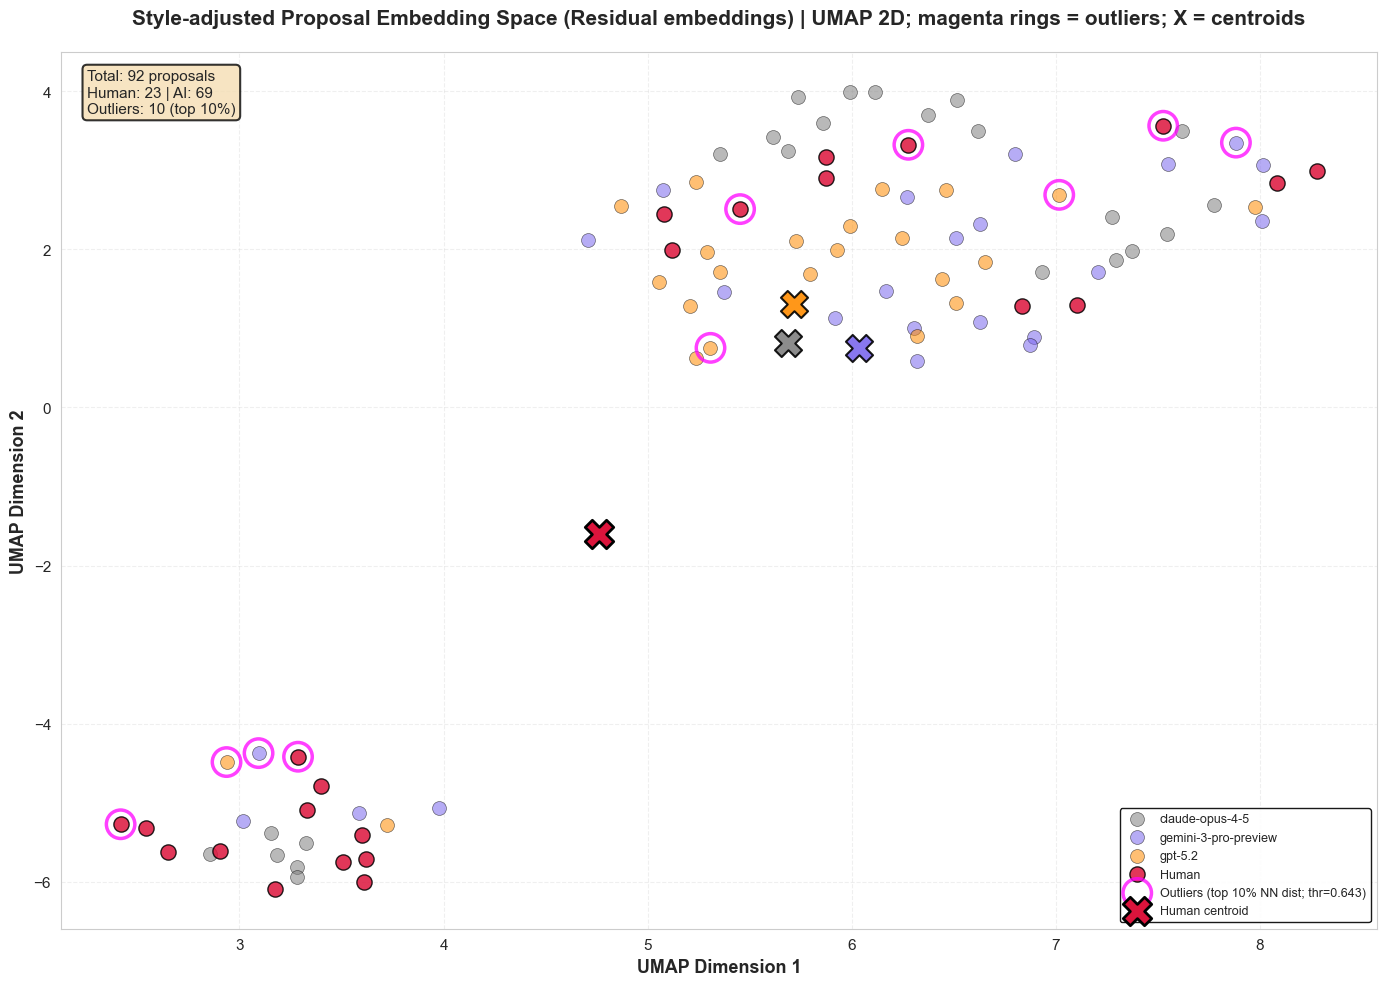


✓ Figure saved to: results/figures/embedding_space_2d_style_adjusted.png
💡 INTERPRETATION:
   - Clusters = similar proposals in style-adjusted residual space
   - Magenta rings = outliers by NN distance in residual space
   - X markers = group centroids in residual space


In [57]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("="*85)
print("STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS")
print("="*85)

required_vars = ['all_embeddings_resid', 'outliers_adj', 'threshold_adj', 'n_human', 'n_ai', 'ai_models_local', 'model_embeddings_dict', 'labels']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print(f"⚠️ Missing variables from prior style-adjusted NN cell: {missing}")
    print("Run the 'STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS' cell first.")
else:
    try:
        cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
        X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
        X_cov = StandardScaler().fit_transform(X_cov)

        E_raw = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])
        E_raw = E_raw / (np.linalg.norm(E_raw, axis=1, keepdims=True) + 1e-12)
        E_adj = np.asarray(all_embeddings_resid)

        pca = PCA(n_components=10, random_state=42)
        Z_raw = pca.fit_transform(E_raw)
        Z_adj = pca.fit_transform(E_adj)

        def _mean_abs_corr(Z, X):
            corrs = []
            for i in range(Z.shape[1]):
                zi = Z[:, i]
                for j in range(X.shape[1]):
                    xj = X[:, j]
                    c = np.corrcoef(zi, xj)[0, 1]
                    if np.isfinite(c):
                        corrs.append(abs(c))
            return float(np.mean(corrs)) if corrs else np.nan

        raw_corr = _mean_abs_corr(Z_raw, X_cov)
        adj_corr = _mean_abs_corr(Z_adj, X_cov)

        print()
        print("Style-adjustment diagnostic (lower is better):")
        print(f"  Mean |corr(style covariate, PC score)| (raw embeddings):  {raw_corr:.4f}")
        print(f"  Mean |corr(style covariate, PC score)| (residual embeddings): {adj_corr:.4f}")
    except Exception as e:
        print()
        print(f"⚠️ Diagnostic skipped due to error: {e}")

    print()
    print("Reducing residual embeddings to 2D using UMAP...")
    reducer_adj = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
    embeddings_2d_adj = reducer_adj.fit_transform(all_embeddings_resid)

    human_2d_adj = embeddings_2d_adj[:n_human]
    ai_2d_adj = embeddings_2d_adj[n_human:]
    model_2d_adj = {model: embeddings_2d_adj[labels == model] for model in ai_models_local}

    print(f"✓ UMAP completed: {len(embeddings_2d_adj)} proposals reduced to 2D")

    outlier_indices_adj = np.where(outliers_adj)[0]
    outlier_coords_adj = embeddings_2d_adj[outlier_indices_adj]

    colors_local = dict(colors) if 'colors' in globals() and isinstance(colors, dict) else {'Human': '#DC143C'}

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    for model in ai_models_local:
        mask = labels == model
        if mask.any():
            pts = embeddings_2d_adj[mask]
            ax.scatter(pts[:, 0], pts[:, 1], c=colors_local.get(model, '#808080'), label=model, s=100, alpha=0.55, edgecolors='black', linewidth=0.5)

    ax.scatter(human_2d_adj[:, 0], human_2d_adj[:, 1], c=colors_local.get('Human', '#DC143C'), label='Human', s=120, alpha=0.85, edgecolors='black', linewidth=1.0, marker='o', zorder=10)
    ax.scatter(outlier_coords_adj[:, 0], outlier_coords_adj[:, 1], s=420, facecolors='none', edgecolors='magenta', linewidth=2.5, alpha=0.75, label=f'Outliers (top 10% NN dist; thr={threshold_adj:.3f})', zorder=12)

    human_centroid_2d = human_2d_adj.mean(axis=0)
    ax.scatter(human_centroid_2d[0], human_centroid_2d[1], c=colors_local.get('Human', '#DC143C'), s=420, marker='X', edgecolors='black', linewidth=2, alpha=1.0, zorder=15, label='Human centroid')

    for model in ai_models_local:
        if model in model_2d_adj and len(model_2d_adj[model]) > 0:
            c2d = model_2d_adj[model].mean(axis=0)
            ax.scatter(c2d[0], c2d[1], c=colors_local.get(model, '#808080'), s=380, marker='X', edgecolors='black', linewidth=1.5, alpha=0.9, zorder=14)

    ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
    ax.set_title('Style-adjusted Proposal Embedding Space (Residual embeddings) | UMAP 2D; magenta rings = outliers; X = centroids', fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
    ax.grid(True, alpha=0.3, linestyle='--')

    textstr = '\n'.join([
        f'Total: {len(embeddings_2d_adj)} proposals',
        f'Human: {n_human} | AI: {n_ai}',
        f'Outliers: {len(outlier_indices_adj)} (top 10%)'
    ])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)

    plt.tight_layout()
    out_path = 'results/figures/baseline/embedding_space_2d_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print()
    print(f"✓ Figure saved to: {out_path}")
    print("💡 INTERPRETATION:")
    print("   - Clusters = similar proposals in style-adjusted residual space")
    print("   - Magenta rings = outliers by NN distance in residual space")
    print("   - X markers = group centroids in residual space")
    print("="*85)


#### Outlier proposals (style-adjusted NN)

Print the titles of proposals flagged as **outliers** in the style-adjusted NN analysis (top 10% NN distance), along with whether they are Human or which AI model generated them.

In [58]:
import pandas as pd
import numpy as np

print("\n" + "="*85)
print("STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers_adj', 'threshold_adj', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the style-adjusted NN analysis cell first.")
else:
    outlier_indices = np.where(outliers_adj)[0]
    n_total = int(len(outliers_adj))
    n_ai = int(n_total - n_human)

    # Get style-adjusted NN distances if available; otherwise recompute quickly
    if 'nn_distances_adj' in globals():
        nn_d = np.asarray(nn_distances_adj)
    elif 'all_distances_adj' in globals():
        nn_d = np.min(np.asarray(all_distances_adj), axis=1)
    elif 'all_embeddings_resid' in globals():
        from sklearn.metrics.pairwise import cosine_distances
        D = cosine_distances(np.asarray(all_embeddings_resid))
        np.fill_diagonal(D, np.inf)
        nn_d = D.min(axis=1)
    else:
        nn_d = None

    # Prefer metadata saved alongside embeddings (guaranteed to match embedding order)
    use_metadata = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_metadata:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df-based lookup.")
            use_metadata = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_metadata:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = idx - n_human
            who = 'AI'
            if use_metadata:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', '')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance_style_adj': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance_style_adj', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold_adj:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.6430
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
Human                   5
gpt-5.2                 3
gemini-3-pro-preview    2


,global_index,who,model,nn_distance_style_adj,title
0,18,Human,Human,0.768386,SynEvo: Discovering Evolutionary Principles of Molecular Organization through Cross-Species Data Synthesis
1,6,Human,Human,0.743506,Oceans of Disorder: Elucidating the Role of Disordered Proteins in Cellular Adaptation
2,55,AI,gemini-3-pro-preview,0.725530,Ribosome Collisions and the Emergence of Translational Quality Control
3,43,AI,gpt-5.2,0.714698,"Mesoscale Emergence in DNA Damage Repair Foci: Integrating Live Imaging, Proteomics, and 3D Genome Context"
4,42,AI,gpt-5.2,0.700080,Emergent Organelle Size Control via Mesoscale Substructure: Integrating Imaging Atlases and Omics to Explain Scaling Laws
5,10,Human,Human,0.693786,Searching the crosslinking mass spectrometry universe for new protein-protein interactions
6,7,Human,Human,0.680808,Multimodel single-cell frameworks for cell lines with extensive multi-omics data
7,23,AI,gpt-5.2,0.649434,A Cross-Cell-Type Atlas of Biomolecular Condensate Material States and Their Emergent Control of Gene Expression Noise
8,46,AI,gemini-3-pro-preview,0.649434,Deciphering the Sequence Grammar of Mesoscale Viscoelasticity in Biomolecular Condensates
9,17,Human,Human,0.644208,Revealing the Ontology of Allostery through Community-Scale Synthesis


# PART V: Review Score Prediction and Outlier Validation

## Overview

This section ports the review-score validation workflow from the rephrased comparison notebook into the baseline proposal notebook.

**Goals:**
1. Validate whether semantic and stylistic metrics predict AI review scores.
2. Test whether NN outliers and literature-most-novel proposals receive higher novelty-related review scores.
3. Export the intermediate analysis tables to CSV under `results/tables/baseline/` so downstream checks are file-based rather than kernel-state-dependent.


### Export baseline intermediate tables

Materialize the same CSV inputs used by the rephrased Part V workflow:
- `proposal_metadata.csv`
- `centroid_distances.csv`
- `nn_distances.csv`
- `style_features.csv`
- `novelty_scores_from_literature.csv`


In [59]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_distances


tables = BASELINE_TABLES_DIR
tables.mkdir(parents=True, exist_ok=True)

required_vars = [
    'human_metadata', 'ai_metadata',
    'human_centroid_dists', 'model_centroid_dists',
    'nn_distances', 'outliers', 'threshold', 'labels',
    'style_df', 'human_novelty_scores', 'ai_novelty_scores',
    'literature_embeddings', 'human_df', 'ai_df'
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(f"Run the earlier analysis cells before Part V. Missing variables: {missing}")

# 1) Proposal metadata
proposal_rows = (
    [{'title': rec.get('proposal_title', rec.get('title', '')), 'group': 'Human'} for rec in human_metadata]
    + [{'title': rec.get('title', rec.get('proposal_title', '')), 'group': rec.get('model', 'AI')} for rec in ai_metadata]
)
pd.DataFrame(proposal_rows).to_csv(tables / 'proposal_metadata.csv', index=False)
print(f"Saved proposal_metadata.csv ({len(proposal_rows)} rows)")

# 2) Centroid distances
centroid_rows = [
    {
        'title': rec.get('proposal_title', rec.get('title', '')),
        'group': 'Human',
        'centroid_dist': float(human_centroid_dists[i]),
    }
    for i, rec in enumerate(human_metadata)
]
model_counters = {str(rec.get('model', 'AI')): 0 for rec in ai_metadata}
for rec in ai_metadata:
    model = str(rec.get('model', 'AI'))
    idx = model_counters[model]
    dist_vals = model_centroid_dists.get(model, np.array([]))
    centroid_rows.append({
        'title': rec.get('title', rec.get('proposal_title', '')),
        'group': model,
        'centroid_dist': float(dist_vals[idx]) if idx < len(dist_vals) else np.nan,
    })
    model_counters[model] = idx + 1
pd.DataFrame(centroid_rows).to_csv(tables / 'centroid_distances.csv', index=False)
print(f"Saved centroid_distances.csv ({len(centroid_rows)} rows)")

# 3) NN distances + outlier flags
combined_metadata = list(human_metadata) + list(ai_metadata)
if len(combined_metadata) != len(nn_distances):
    raise RuntimeError(
        f"Metadata/NN mismatch: {len(combined_metadata)} metadata rows vs {len(nn_distances)} NN distances"
    )

nn_rows = []
for i, (rec, group_label) in enumerate(zip(combined_metadata, labels)):
    title = rec.get('proposal_title', rec.get('title', ''))
    nn_rows.append({
        'title': title,
        'group': str(group_label),
        'nn_dist': float(nn_distances[i]),
        'is_outlier': bool(outliers[i]),
        'threshold': float(threshold),
    })

nn_export = pd.DataFrame(nn_rows)
nn_export.to_csv(tables / 'nn_distances.csv', index=False)
print(f"Saved nn_distances.csv ({len(nn_export)} rows, threshold={threshold:.4f})")

# 4) Style features
style_titles = [rec.get('proposal_title', rec.get('title', '')) for rec in human_metadata] + [
    rec.get('title', rec.get('proposal_title', '')) for rec in ai_metadata
]
if len(style_df) != len(style_titles):
    raise RuntimeError(
        f"style_df/title mismatch: {len(style_df)} style rows vs {len(style_titles)} titles"
    )
style_export = style_df.copy()
style_export.insert(0, 'title', style_titles)
style_export['group'] = ['Human'] * len(human_metadata) + [str(rec.get('model', 'AI')) for rec in ai_metadata]
style_export.to_csv(tables / 'style_features.csv', index=False)
print(f"Saved style_features.csv ({len(style_export)} rows)")

# 5) Literature-normalized novelty scores
k_local = int(globals().get('k', 10))
lit_dist_matrix = cosine_distances(literature_embeddings, literature_embeddings)
np.fill_diagonal(lit_dist_matrix, np.inf)
lit_knn_indices = np.argsort(lit_dist_matrix, axis=1)[:, :k_local]
lit_baseline_knn = np.array([
    lit_dist_matrix[i, lit_knn_indices[i]].mean()
    for i in range(len(literature_embeddings))
])
lit_baseline_mean = float(lit_baseline_knn.mean())
lit_baseline_std = float(lit_baseline_knn.std())
if lit_baseline_std == 0:
    lit_baseline_std = 1.0

human_novelty_z = (np.asarray(human_novelty_scores) - lit_baseline_mean) / lit_baseline_std
ai_novelty_z = (np.asarray(ai_novelty_scores) - lit_baseline_mean) / lit_baseline_std
human_novelty_ratio = np.asarray(human_novelty_scores) / lit_baseline_mean
ai_novelty_ratio = np.asarray(ai_novelty_scores) / lit_baseline_mean

nov_rows = []
for i, row in human_df.reset_index(drop=True).iterrows():
    nov_rows.append({
        'title': row.get('proposal_title', row.get('title', '')),
        'group': 'Human',
        'raw_novelty': float(human_novelty_scores[i]),
        'novelty_z': float(human_novelty_z[i]),
        'novelty_ratio': float(human_novelty_ratio[i]),
    })
for i, row in ai_df.reset_index(drop=True).iterrows():
    nov_rows.append({
        'title': row.get('title', row.get('proposal_title', '')),
        'group': row.get('model', 'AI'),
        'raw_novelty': float(ai_novelty_scores[i]),
        'novelty_z': float(ai_novelty_z[i]),
        'novelty_ratio': float(ai_novelty_ratio[i]),
    })
nov_df = pd.DataFrame(nov_rows)
raw_thresh = np.percentile(nov_df['raw_novelty'], 90)
z_thresh = np.percentile(nov_df['novelty_z'], 90)
ratio_thresh = np.percentile(nov_df['novelty_ratio'], 90)
nov_df['is_most_novel_raw'] = nov_df['raw_novelty'] >= raw_thresh
nov_df['is_most_novel_z'] = nov_df['novelty_z'] >= z_thresh
nov_df['is_most_novel_ratio'] = nov_df['novelty_ratio'] >= ratio_thresh
nov_df.to_csv(tables / 'novelty_scores_from_literature.csv', index=False)
print(f"Saved novelty_scores_from_literature.csv ({len(nov_df)} rows)")
print(f"  Raw novelty threshold: {raw_thresh:.4f} -> {int(nov_df['is_most_novel_raw'].sum())} proposals")


Saved proposal_metadata.csv (92 rows)
Saved centroid_distances.csv (92 rows)
Saved nn_distances.csv (92 rows, threshold=0.2000)
Saved style_features.csv (92 rows)
Saved novelty_scores_from_literature.csv (92 rows)
  Raw novelty threshold: 0.2085 -> 10 proposals


### Load and flatten review scores


In [60]:
import json
import numpy as np
import pandas as pd
from pathlib import Path


tables = BASELINE_TABLES_DIR
review_dir = Path('data/reviews/ai_reviews')
review_files = sorted(review_dir.glob('ai_reviews_ncems_criteria_*.json'))
if not review_files:
    raise FileNotFoundError(f"No baseline review files found in {review_dir}")
review_path = review_files[-1]
print(f"Loading: {review_path.name}")

with open(review_path) as f:
    review_data = json.load(f)

print(f"Total review entries: {len(review_data['reviews'])}")
print(f"Evaluators: {review_data['evaluators']}")

rows = []
for entry in review_data['reviews']:
    title = entry.get('title', '')
    author = entry.get('author', '')
    evaluator = entry.get('evaluator', '')
    evals = entry.get('evaluations', {})
    criteria_scores = evals.get('evaluation', {}).get('criteria_scores', [])

    for cat in criteria_scores:
        for sub in cat.get('subcriteria', []):
            rows.append({
                'title': title,
                'author': author,
                'evaluator': evaluator,
                'category': cat['category'],
                'criterion': sub['criterion'],
                'score': sub['score'],
            })

reviews_df = pd.DataFrame(rows)
print(f"\nFlattened rows: {len(reviews_df)}")
print("Criteria:", reviews_df['criterion'].unique().tolist())
print("\nScore distribution:")
print(reviews_df.groupby('criterion')['score'].describe().round(2))


Loading: ai_reviews_ncems_criteria_20260223_153411.json
Total review entries: 276
Evaluators: ['gpt-5.2', 'gemini-3-pro-preview', 'claude-opus-4-5']

Flattened rows: 1932
Criteria: ['Relevance to Emergent Phenomena', 'Novelty & Significance', 'Rigor of Approach', 'Scope & Timeline', 'Synthesis Focus', 'Data Identification', 'Open Science Commitment']

Score distribution:
                                 count  mean   std  min  25%  50%  75%  max
criterion                                                                  
Data Identification              276.0  3.77  0.86  2.0  3.0  4.0  4.0  5.0
Novelty & Significance           276.0  4.21  0.48  3.0  4.0  4.0  4.0  5.0
Open Science Commitment          276.0  4.07  0.99  1.0  3.0  4.0  5.0  5.0
Relevance to Emergent Phenomena  276.0  4.68  0.75  1.0  5.0  5.0  5.0  5.0
Rigor of Approach                276.0  3.66  1.04  1.0  3.0  4.0  4.0  5.0
Scope & Timeline                 276.0  3.02  0.83  1.0  3.0  3.0  4.0  5.0
Synthesis Focus   

In [61]:
scores_avg = (
    reviews_df
    .groupby(['title', 'author', 'criterion'])['score']
    .mean()
    .reset_index()
    .rename(columns={'score': 'avg_score'})
)

scores_wide = scores_avg.pivot_table(
    index=['title', 'author'], columns='criterion', values='avg_score'
).reset_index()
scores_wide.columns.name = None
scores_wide.columns = [
    c.lower().replace(' ', '_').replace('&', 'and').replace('/', '_')
    for c in scores_wide.columns
]

print(scores_wide.shape)
print(scores_wide.columns.tolist())
scores_wide.to_csv((BASELINE_TABLES_DIR) / 'review_scores_wide.csv', index=False)
print("Saved review_scores_wide.csv")
scores_wide.head()


(92, 9)
['title', 'author', 'data_identification', 'novelty_and_significance', 'open_science_commitment', 'relevance_to_emergent_phenomena', 'rigor_of_approach', 'scope_and_timeline', 'synthesis_focus']
Saved review_scores_wide.csv


,title,author,data_identification,novelty_and_significance,open_science_commitment,relevance_to_emergent_phenomena,rigor_of_approach,scope_and_timeline,synthesis_focus
0,A Cross-Cell-Type Atlas of Biomolecular Conden...,gpt-5.2,4.333333,4.666667,4.666667,5.000000,4.333333,3.333333,5.000000
1,A Unified Framework for Analyses of Proteome T...,human-y2,3.333333,4.000000,4.333333,3.666667,4.333333,4.000000,5.000000
2,Autophagosome Biogenesis: Emergent Membrane Re...,gemini-3-pro-preview,4.333333,4.333333,4.333333,5.000000,4.000000,3.333333,5.000000
3,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,human-y1,3.000000,4.000000,2.000000,3.666667,3.333333,3.333333,4.666667
4,Chromatin Compartmentalization Dynamics: Synth...,claude-opus-4-5,4.000000,4.333333,4.666667,5.000000,4.333333,3.333333,5.000000


---
## Analysis 5.1: Metric-Score Correlation

For each review criterion, compute Spearman correlations with semantic and style metrics.


Matched proposals: 92 / 92
Score columns: ['data_identification', 'novelty_and_significance', 'open_science_commitment', 'relevance_to_emergent_phenomena', 'rigor_of_approach', 'scope_and_timeline', 'synthesis_focus']


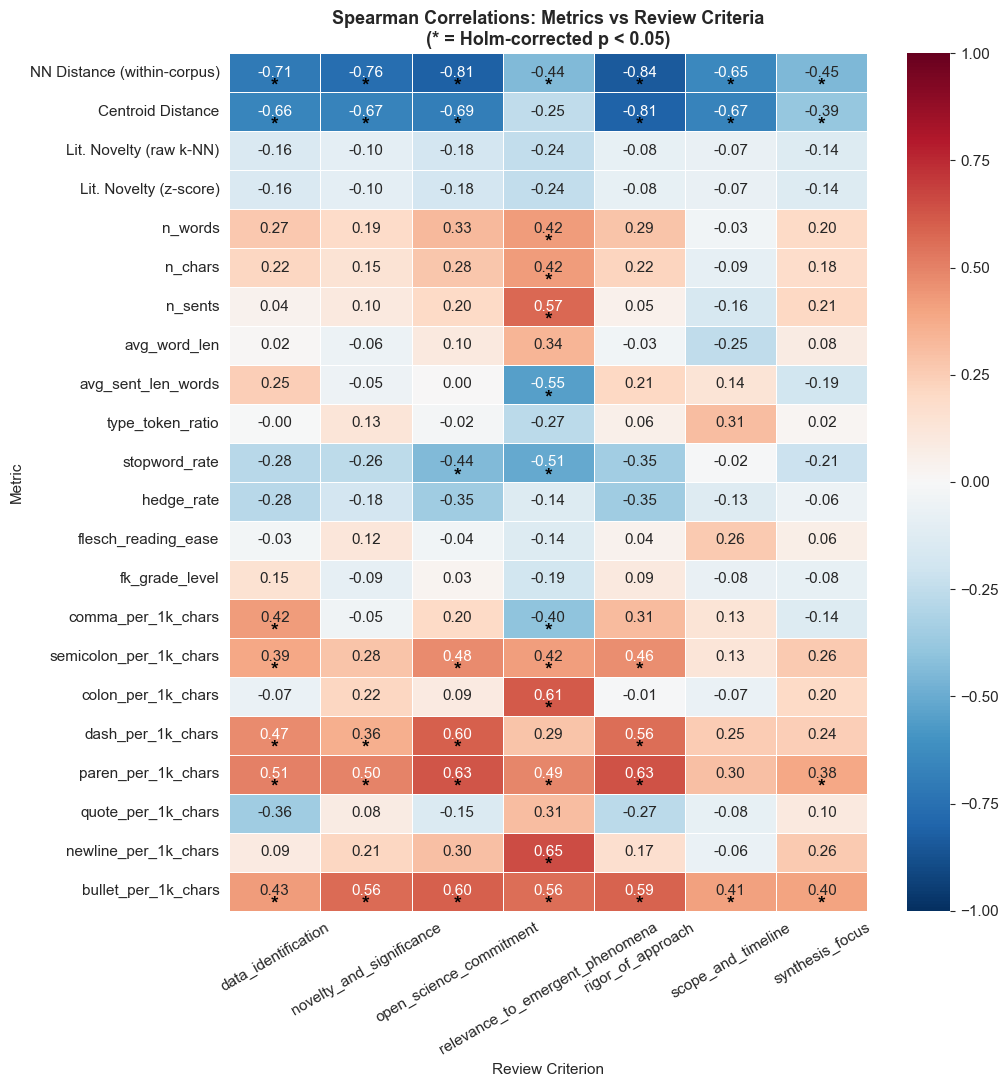

Saved results/figures/baseline/metric_score_correlation_heatmap.png

Top correlations (|r| > 0.2):
  NN Distance (within-corpus)         x data_identification                  r=-0.706*
  NN Distance (within-corpus)         x novelty_and_significance             r=-0.763*
  NN Distance (within-corpus)         x open_science_commitment              r=-0.815*
  NN Distance (within-corpus)         x relevance_to_emergent_phenomena      r=-0.443*
  NN Distance (within-corpus)         x rigor_of_approach                    r=-0.841*
  NN Distance (within-corpus)         x scope_and_timeline                   r=-0.648*
  NN Distance (within-corpus)         x synthesis_focus                      r=-0.453*
  Centroid Distance                   x data_identification                  r=-0.664*
  Centroid Distance                   x novelty_and_significance             r=-0.666*
  Centroid Distance                   x open_science_commitment              r=-0.692*
  Centroid Distance            

In [62]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path


tables = BASELINE_TABLES_DIR
figures = BASELINE_FIGURES_DIR
figures.mkdir(parents=True, exist_ok=True)

nn_df = pd.read_csv(tables / 'nn_distances.csv')
centroid_df = pd.read_csv(tables / 'centroid_distances.csv')
style_csv = pd.read_csv(tables / 'style_features.csv')
nov_df = pd.read_csv(tables / 'novelty_scores_from_literature.csv')

if 'scores_wide' not in globals():
    raise RuntimeError('Run the review-loading cells above first.')

def norm(s):
    return str(s).strip().lower()

for df in [nn_df, centroid_df, style_csv, nov_df, scores_wide]:
    df['title_norm'] = df['title'].map(norm)

feature_cols = [c for c in style_csv.columns if c not in {'title', 'group', 'is_ai', 'title_norm'}]
score_cols = [c for c in scores_wide.columns if c not in {'title', 'title_norm', 'author'}]

merged = (
    nn_df[['title_norm', 'group', 'nn_dist', 'is_outlier', 'threshold']]
    .merge(centroid_df[['title_norm', 'centroid_dist']], on='title_norm', how='left')
    .merge(nov_df[['title_norm', 'raw_novelty', 'novelty_z']], on='title_norm', how='left')
    .merge(style_csv[['title_norm'] + feature_cols], on='title_norm', how='left')
    .merge(scores_wide[['title_norm'] + score_cols], on='title_norm', how='inner')
)
print(f"Matched proposals: {len(merged)} / {len(nn_df)}")
print(f"Score columns: {score_cols}")

metric_features = ['nn_dist', 'centroid_dist', 'raw_novelty', 'novelty_z'] + feature_cols
corr_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)
pval_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)

for metric in metric_features:
    for score in score_cols:
        valid = merged[[metric, score]].dropna()
        if len(valid) < 5:
            corr_mat.loc[metric, score] = np.nan
            pval_mat.loc[metric, score] = np.nan
        else:
            r, p = stats.spearmanr(valid[metric], valid[score])
            corr_mat.loc[metric, score] = r
            pval_mat.loc[metric, score] = p

valid_rows = corr_mat.notna().any(axis=1)
corr_mat = corr_mat[valid_rows]
pval_mat = pval_mat[valid_rows]
metric_features = [m for m in metric_features if valid_rows[m]]

flat_p = pval_mat.values.flatten()
valid_mask = ~np.isnan(flat_p)
corrected = np.full_like(flat_p, np.nan)
if valid_mask.sum() > 0:
    _, corrected[valid_mask], _, _ = multipletests(flat_p[valid_mask], method='holm')
sig_mat = pd.DataFrame(corrected.reshape(pval_mat.shape) < 0.05, index=pval_mat.index, columns=pval_mat.columns)

row_labels = {
    'nn_dist': 'NN Distance (within-corpus)',
    'centroid_dist': 'Centroid Distance',
    'raw_novelty': 'Lit. Novelty (raw k-NN)',
    'novelty_z': 'Lit. Novelty (z-score)',
}

corr_display = corr_mat.copy()
corr_display.index = [row_labels.get(metric, metric) for metric in metric_features]

fig, ax = plt.subplots(figsize=(max(10, len(score_cols) * 1.5), max(8, len(metric_features) * 0.5)))
sns.heatmap(corr_display.astype(float), annot=True, fmt='.2f', center=0, cmap='RdBu_r', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
for i, metric in enumerate(metric_features):
    for j, score in enumerate(score_cols):
        if sig_mat.loc[metric, score]:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=14, fontweight='bold', color='black')
ax.set_title("Spearman Correlations: Metrics vs Review Criteria\n(* = Holm-corrected p < 0.05)", fontsize=13, fontweight='bold')
ax.set_xlabel('Review Criterion', fontsize=11)
ax.set_ylabel('Metric', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
out_path = figures / 'metric_score_correlation_heatmap.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {out_path}")

print("\nTop correlations (|r| > 0.2):")
for metric in metric_features:
    for score in score_cols:
        r = corr_mat.loc[metric, score]
        if pd.notna(r) and abs(r) > 0.2:
            sig = '*' if sig_mat.loc[metric, score] else ''
            print(f"  {row_labels.get(metric, metric):<35} x {score:<35}  r={r:+.3f}{sig}")


Human proposals: 23  |  AI proposals: 69


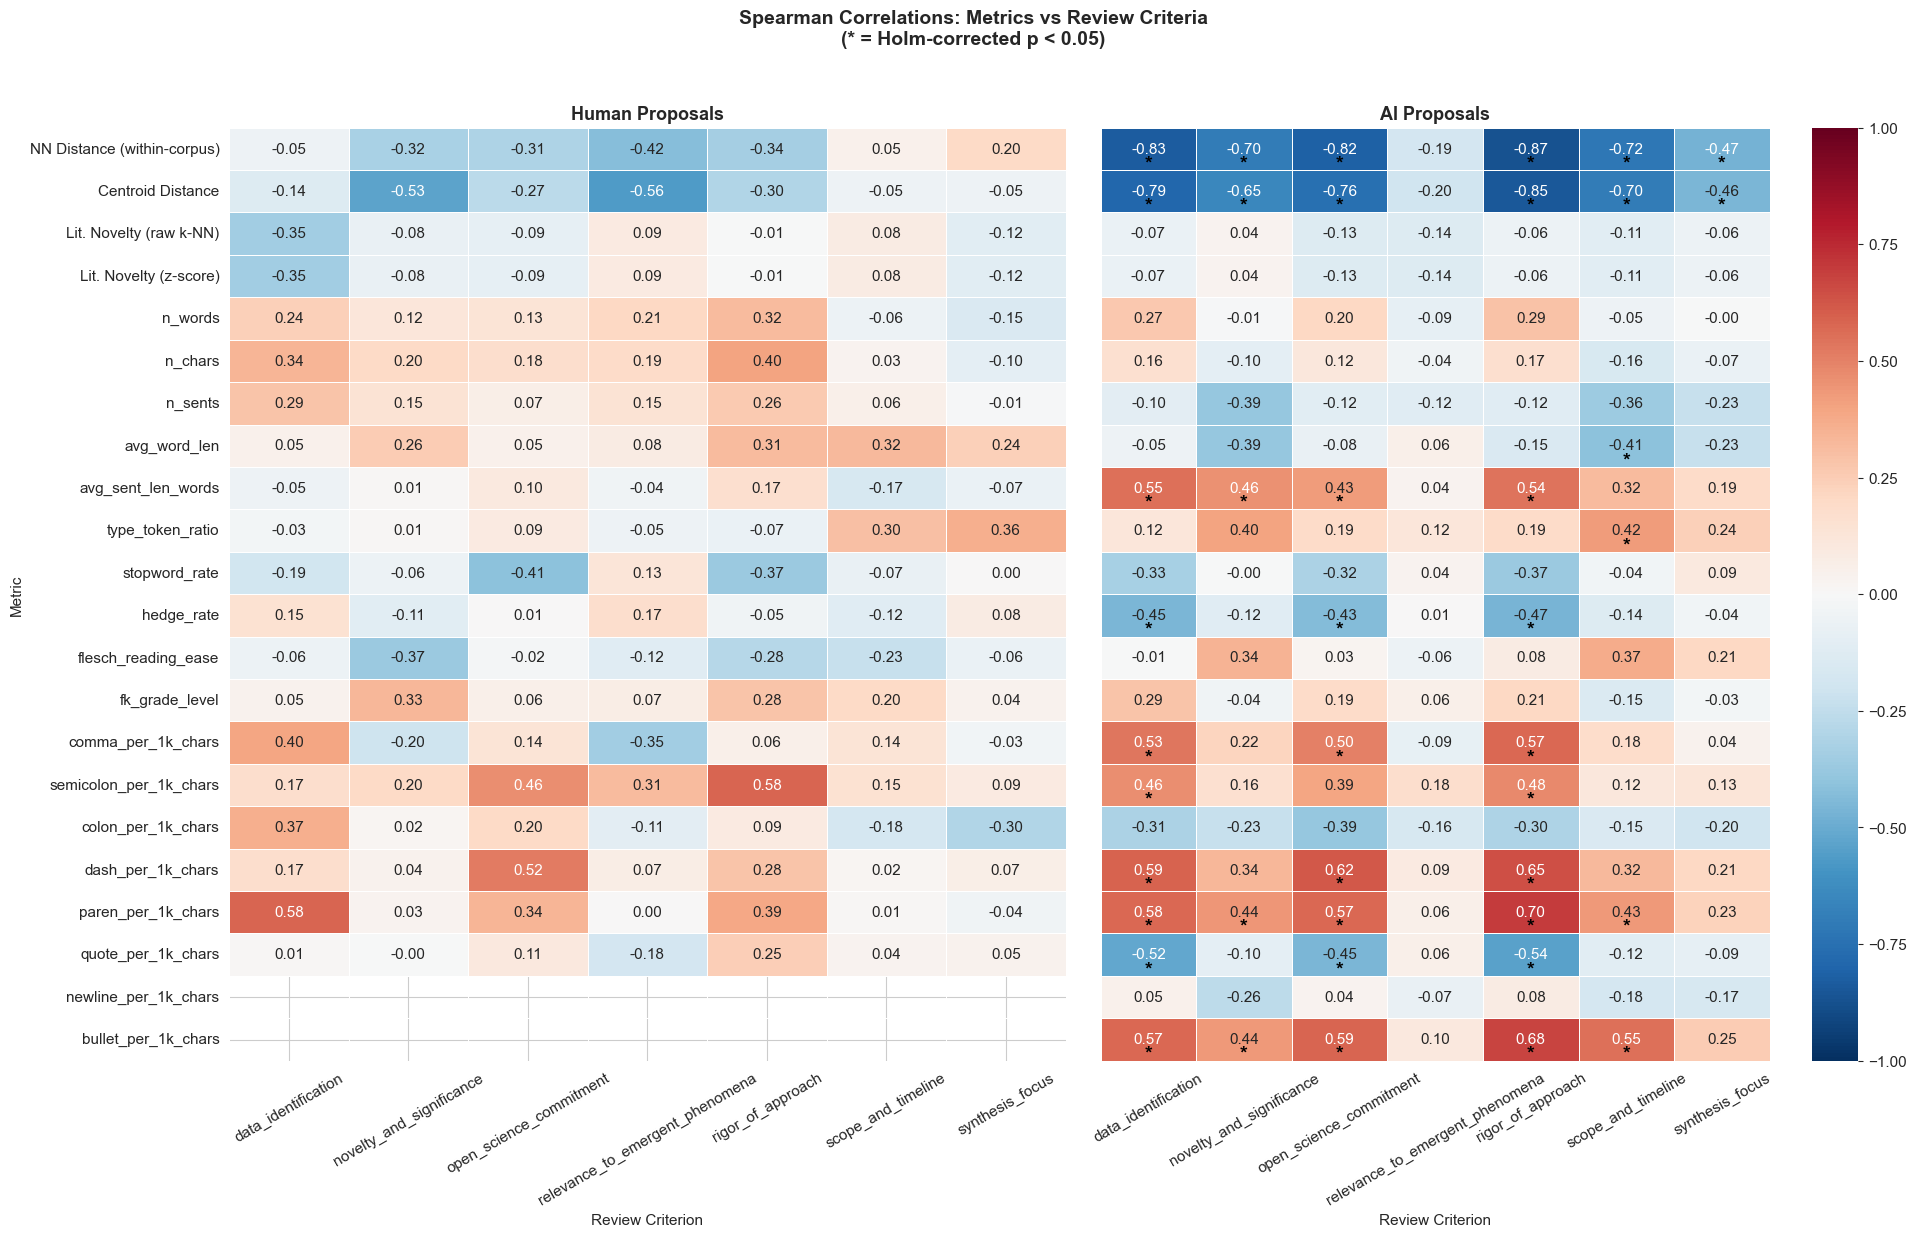

Saved results/figures/baseline/metric_score_correlation_heatmap_by_group.png


In [63]:
def compute_corr(subset, metric_features, score_cols):
    corr_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)
    pval_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)
    for metric in metric_features:
        for score in score_cols:
            valid = subset[[metric, score]].dropna()
            if len(valid) < 5:
                corr_mat.loc[metric, score] = np.nan
                pval_mat.loc[metric, score] = np.nan
            else:
                r, p = stats.spearmanr(valid[metric], valid[score])
                corr_mat.loc[metric, score] = r
                pval_mat.loc[metric, score] = p

    valid_rows = corr_mat.notna().any(axis=1)
    corr_mat = corr_mat[valid_rows]
    pval_mat = pval_mat[valid_rows]
    kept_feats = [metric for metric in metric_features if valid_rows[metric]]

    flat_p = pval_mat.values.flatten()
    valid_mask = ~np.isnan(flat_p)
    corrected = np.full_like(flat_p, np.nan)
    if valid_mask.sum() > 0:
        _, corrected[valid_mask], _, _ = multipletests(flat_p[valid_mask], method='holm')
    sig_mat = pd.DataFrame(corrected.reshape(pval_mat.shape) < 0.05, index=pval_mat.index, columns=pval_mat.columns)
    return corr_mat, sig_mat, kept_feats

metric_features_base = ['nn_dist', 'centroid_dist', 'raw_novelty', 'novelty_z'] + feature_cols
is_ai_df = style_csv[['title_norm', 'is_ai']].drop_duplicates('title_norm')
merged_split = merged.merge(is_ai_df, on='title_norm', how='left')

human_sub = merged_split[merged_split['is_ai'] == 0]
ai_sub = merged_split[merged_split['is_ai'] == 1]
print(f"Human proposals: {len(human_sub)}  |  AI proposals: {len(ai_sub)}")

corr_h, sig_h, feats_h = compute_corr(human_sub, metric_features_base, score_cols)
corr_a, sig_a, feats_a = compute_corr(ai_sub, metric_features_base, score_cols)

row_labels = {
    'nn_dist': 'NN Distance (within-corpus)',
    'centroid_dist': 'Centroid Distance',
    'raw_novelty': 'Lit. Novelty (raw k-NN)',
    'novelty_z': 'Lit. Novelty (z-score)',
}

def make_display(corr_mat, feats):
    display = corr_mat.copy()
    display.index = [row_labels.get(metric, metric) for metric in feats]
    return display

corr_h_disp = make_display(corr_h, feats_h)
corr_a_disp = make_display(corr_a, feats_a)
all_labels = list(dict.fromkeys([row_labels.get(metric, metric) for metric in metric_features_base if metric in feats_h or metric in feats_a]))
corr_h_disp = corr_h_disp.reindex(all_labels)
corr_a_disp = corr_a_disp.reindex(all_labels)

n_rows = len(all_labels)
n_cols = len(score_cols)
fig, axes = plt.subplots(1, 2, figsize=(max(18, n_cols * 2.8), max(6, n_rows * 0.55)), sharey=True)
heatmap_kw = dict(annot=True, fmt='.2f', center=0, cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)

for ax, corr_disp, sig_mat_local, feats, title in [
    (axes[0], corr_h_disp, sig_h, feats_h, 'Human Proposals'),
    (axes[1], corr_a_disp, sig_a, feats_a, 'AI Proposals'),
]:
    sns.heatmap(corr_disp.astype(float), ax=ax, **heatmap_kw, cbar=(ax is axes[1]))
    for metric in feats:
        label = row_labels.get(metric, metric)
        if label not in corr_disp.index:
            continue
        row_pos = list(corr_disp.index).index(label)
        for j, score in enumerate(score_cols):
            if score in sig_mat_local.columns and sig_mat_local.loc[metric, score]:
                ax.text(j + 0.5, row_pos + 0.85, '*', ha='center', va='center', fontsize=14, fontweight='bold', color='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Review Criterion', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Metric', fontsize=11)
axes[1].set_ylabel('')
fig.suptitle("Spearman Correlations: Metrics vs Review Criteria\n(* = Holm-corrected p < 0.05)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = (BASELINE_FIGURES_DIR / 'metric_score_correlation_heatmap_by_group.png')
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {out_path}")


---
## Analysis 5.2: Predictive Modeling of Review Scores

Fit Ridge models with permutation-tested cross-validated R² for style-only, embedding-only, literature-novelty-only, and combined feature sets.


In [64]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'merged' not in globals():
    raise RuntimeError("Run Analysis 5.1 first to build 'merged'.")

tables = BASELINE_TABLES_DIR
embedding_features = ['nn_dist', 'centroid_dist']
novelty_features = [c for c in ['raw_novelty', 'novelty_z'] if c in merged.columns]
non_feat = ({'title_norm', 'group', 'nn_dist', 'centroid_dist', 'raw_novelty', 'novelty_z', 'is_outlier', 'threshold', 'is_ai', 'is_most_novel_raw', 'is_most_novel_z'} | set(score_cols))
feature_cols_local = [c for c in merged.columns if c not in non_feat and pd.api.types.is_numeric_dtype(merged[c])]

results_rows = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)
for criterion in score_cols:
    y = merged[criterion].values
    if np.isnan(y).all():
        continue
    feature_sets = [
        ('style', feature_cols_local),
        ('embedding', embedding_features),
        ('novelty-literature', novelty_features),
        ('all', feature_cols_local + embedding_features + novelty_features),
    ]
    for label, feat_set in feature_sets:
        if not feat_set:
            continue
        X = merged[feat_set].replace([np.inf, -np.inf], np.nan).values
        valid = ~np.isnan(y)
        X_v, y_v = X[valid], y[valid]
        if len(y_v) < 10:
            continue
        pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge(alpha=1.0))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            obs_r2, perm_r2s, p_val = permutation_test_score(pipe, X_v, y_v, cv=cv, scoring='r2', n_permutations=500, n_jobs=-1, random_state=42)
        results_rows.append({
            'criterion': criterion,
            'feature_set': label,
            'cv_r2': obs_r2,
            'null_r2_mean': perm_r2s.mean(),
            'p_value': p_val,
        })
        print(f"{criterion:<40} [{label:<20}] R²={obs_r2:.3f}  null={perm_r2s.mean():.3f}  p={p_val:.3f}")

pred_df = pd.DataFrame(results_rows)
pred_df.to_csv(tables / 'ridge_r2_by_criterion.csv', index=False)
print('\nSaved ridge_r2_by_criterion.csv')


data_identification                      [style               ] R²=0.349  null=-0.386  p=0.002
data_identification                      [embedding           ] R²=0.146  null=-0.142  p=0.002
data_identification                      [novelty-literature  ] R²=-0.105  null=-0.108  p=0.613
data_identification                      [all                 ] R²=0.082  null=-0.507  p=0.002
novelty_and_significance                 [style               ] R²=0.275  null=-0.419  p=0.002
novelty_and_significance                 [embedding           ] R²=-0.032  null=-0.151  p=0.076
novelty_and_significance                 [novelty-literature  ] R²=-0.007  null=-0.108  p=0.038
novelty_and_significance                 [all                 ] R²=-0.221  null=-0.566  p=0.070
open_science_commitment                  [style               ] R²=0.315  null=-0.426  p=0.002
open_science_commitment                  [embedding           ] R²=-0.249  null=-0.163  p=0.820
open_science_commitment                  [nov

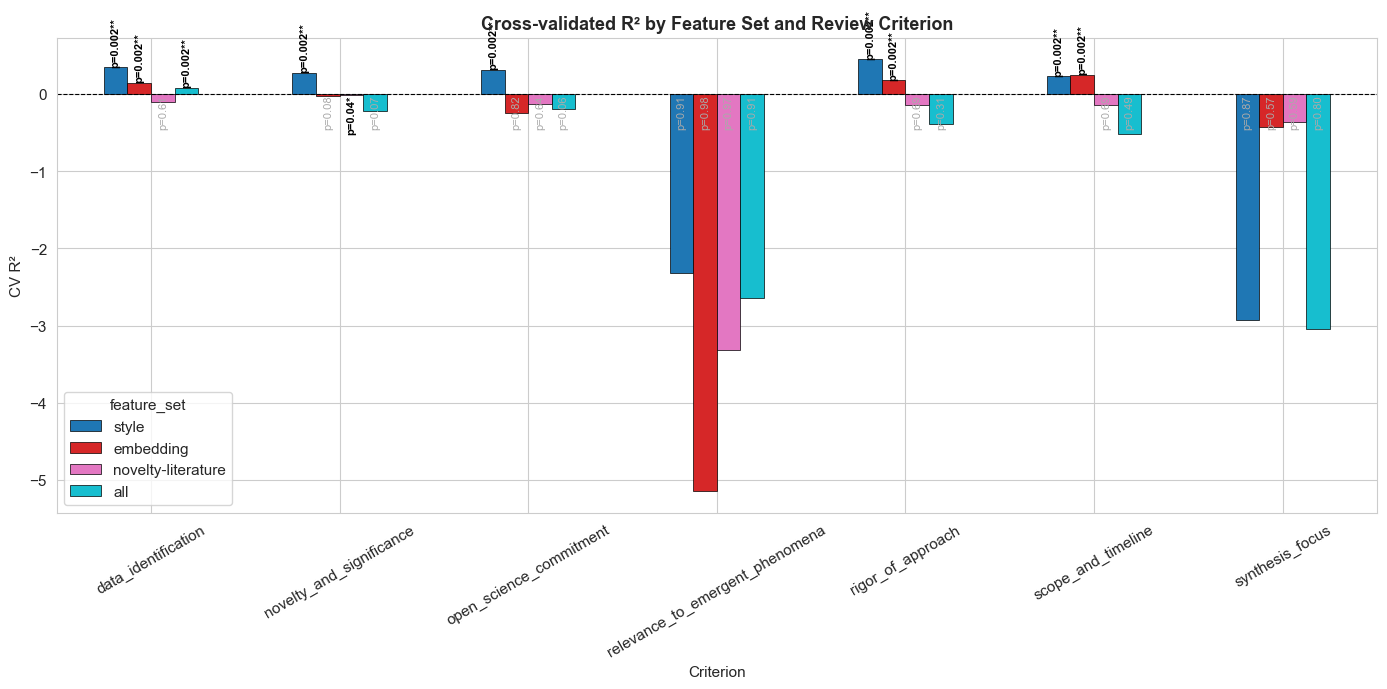

Saved results/figures/baseline/metric_score_r2_by_criterion.png


In [65]:
pivot = pred_df.pivot(index='criterion', columns='feature_set', values='cv_r2')
p_pivot = pred_df.pivot(index='criterion', columns='feature_set', values='p_value')
col_order = [c for c in ['style', 'embedding', 'novelty-literature', 'all'] if c in pivot.columns]
pivot = pivot[col_order]
p_pivot = p_pivot[col_order]

fig, ax = plt.subplots(figsize=(14, 7))
pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cross-validated R² by Feature Set and Review Criterion', fontsize=13, fontweight='bold')
ax.set_xlabel('Criterion', fontsize=11)
ax.set_ylabel('CV R²', fontsize=11)
ax.tick_params(axis='x', rotation=30)

criteria_list = list(pivot.index)
feat_list = list(pivot.columns)
n_crit = len(criteria_list)
for j, feat in enumerate(feat_list):
    for i, crit in enumerate(criteria_list):
        patch = ax.patches[j * n_crit + i]
        p = p_pivot.loc[crit, feat] if (crit in p_pivot.index and feat in p_pivot.columns) else np.nan
        r2 = pivot.loc[crit, feat]
        if np.isnan(p) or np.isnan(r2):
            continue
        if p < 0.001:
            p_label = 'p<.001***'
        elif p < 0.01:
            p_label = f'p={p:.3f}**'
        elif p < 0.05:
            p_label = f'p={p:.2f}*'
        else:
            p_label = f'p={p:.2f}'
        bar_top = patch.get_y() + patch.get_height()
        bar_bot = patch.get_y()
        if r2 >= 0:
            y_pos, va = bar_top + 0.004, 'bottom'
        else:
            y_pos, va = bar_bot - 0.004, 'top'
        ax.text(patch.get_x() + patch.get_width() / 2, y_pos, p_label, ha='center', va=va, fontsize=8, rotation=90, color='black' if p < 0.05 else '#aaaaaa', fontweight='bold' if p < 0.05 else 'normal')

plt.tight_layout()
out_path = BASELINE_FIGURES_DIR / 'metric_score_r2_by_criterion.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {out_path}")


---
## Analysis 5.3: Outlier Validation

Test whether semantic outliers (top-10% nearest-neighbor distance) receive higher review scores.


Outlier threshold: 0.2000  |  Outliers in merged: 10 / 92
data_identification                      outlier=3.00  non-outlier=3.87  δ=-0.698  p=0.9999
novelty_and_significance                 outlier=3.93  non-outlier=4.24  δ=-0.683  p=0.9999
open_science_commitment                  outlier=2.97  non-outlier=4.20  δ=-0.720  p=0.9999
relevance_to_emergent_phenomena          outlier=4.57  non-outlier=4.70  δ=-0.176  p=0.8920
rigor_of_approach                        outlier=2.47  non-outlier=3.80  δ=-0.771  p=1.0000
scope_and_timeline                       outlier=2.17  non-outlier=3.12  δ=-0.659  p=0.9999
synthesis_focus                          outlier=4.83  non-outlier=4.82  δ=-0.244  p=0.9571

Saved outlier_score_comparison.csv


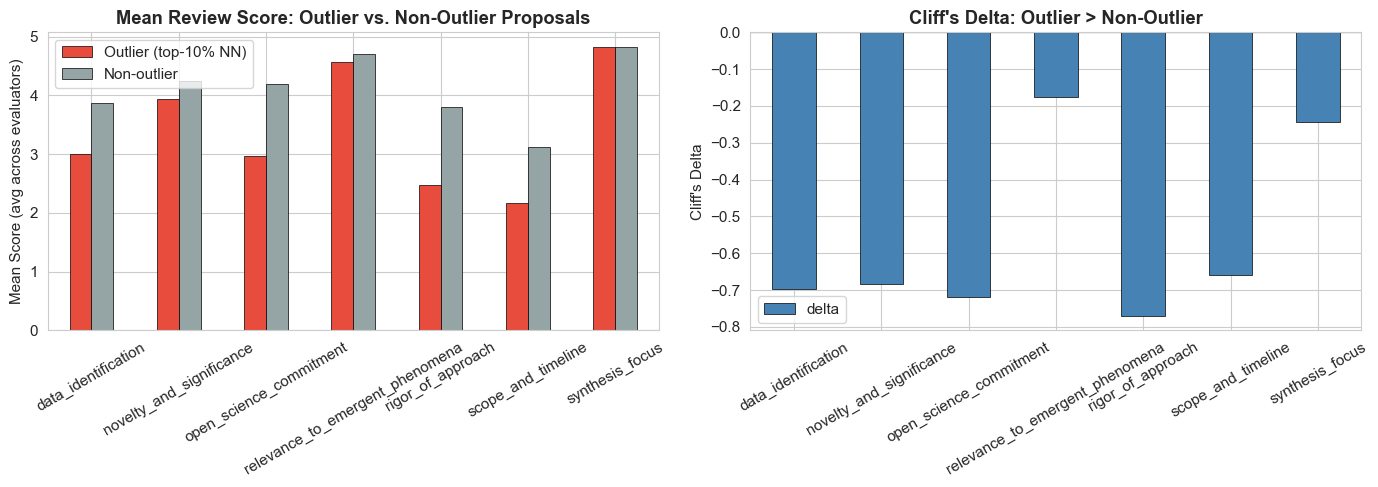

Saved results/figures/baseline/outlier_score_comparison.png
                      criterion  outlier_mean  nonout_mean     delta  p_value  p_holm
            data_identification      3.000000     3.865854 -0.697561 0.999897     1.0
       novelty_and_significance      3.933333     4.243902 -0.682927 0.999932     1.0
        open_science_commitment      2.966667     4.199187 -0.719512 0.999930     1.0
relevance_to_emergent_phenomena      4.566667     4.699187 -0.175610 0.892049     1.0
              rigor_of_approach      2.466667     3.804878 -0.770732 0.999980     1.0
             scope_and_timeline      2.166667     3.121951 -0.658537 0.999937     1.0
                synthesis_focus      4.833333     4.821138 -0.243902 0.957091     1.0


In [66]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def cliffs_delta_simple(x, y):
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
    return dom / (len(x) * len(y))

if 'merged' not in globals():
    raise RuntimeError("Run Analysis 5.1 first to build 'merged'.")

tables = BASELINE_TABLES_DIR
threshold_val = merged['threshold'].iloc[0]
n_outliers = int(merged['is_outlier'].sum())
print(f"Outlier threshold: {threshold_val:.4f}  |  Outliers in merged: {n_outliers} / {len(merged)}")

if n_outliers < 2:
    print("\n⚠️ Fewer than 2 outliers. nn_dist summary:")
    print(merged[['group', 'nn_dist', 'is_outlier']].groupby('group').agg({'nn_dist': 'mean', 'is_outlier': 'sum'}))
else:
    outlier_results = []
    for criterion in score_cols:
        out_scores = merged.loc[merged['is_outlier'], criterion].dropna()
        nonout_scores = merged.loc[~merged['is_outlier'], criterion].dropna()
        if len(out_scores) < 2 or len(nonout_scores) < 2:
            continue
        u_stat, p_val = mannwhitneyu(out_scores, nonout_scores, alternative='greater')
        delta = cliffs_delta_simple(out_scores, nonout_scores)
        outlier_results.append({
            'criterion': criterion,
            'outlier_mean': out_scores.mean(),
            'nonout_mean': nonout_scores.mean(),
            'delta': delta,
            'p_value': p_val,
            'n_outlier': len(out_scores),
            'n_nonout': len(nonout_scores),
        })
        print(f"{criterion:<40} outlier={out_scores.mean():.2f}  non-outlier={nonout_scores.mean():.2f}  δ={delta:+.3f}  p={p_val:.4f}")

    if not outlier_results:
        print("\n⚠️ No criteria had enough observations.")
    else:
        outlier_df = pd.DataFrame(outlier_results)
        _, outlier_df['p_holm'], _, _ = multipletests(outlier_df['p_value'], method='holm')
        outlier_df.to_csv(tables / 'outlier_score_comparison.csv', index=False)
        print('\nSaved outlier_score_comparison.csv')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        outlier_df.plot(x='criterion', y=['outlier_mean', 'nonout_mean'], kind='bar', ax=axes[0], color=['#E74C3C', '#95A5A6'], edgecolor='black', linewidth=0.5)
        axes[0].set_title('Mean Review Score: Outlier vs. Non-Outlier Proposals', fontweight='bold')
        axes[0].set_xlabel('')
        axes[0].set_ylabel('Mean Score (avg across evaluators)')
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].legend(['Outlier (top-10% NN)', 'Non-outlier'])

        outlier_df.plot(x='criterion', y='delta', kind='bar', ax=axes[1], color='steelblue', edgecolor='black', linewidth=0.5)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_title("Cliff's Delta: Outlier > Non-Outlier", fontweight='bold')
        axes[1].set_xlabel('')
        axes[1].set_ylabel("Cliff's Delta")
        axes[1].tick_params(axis='x', rotation=30)
        for i, (_, row) in enumerate(outlier_df.iterrows()):
            if row['p_holm'] < 0.05:
                axes[1].text(i, row['delta'] + 0.01, '*', ha='center', fontsize=14, fontweight='bold')

        plt.tight_layout()
        out_path = BASELINE_FIGURES_DIR / 'outlier_score_comparison.png'
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved {out_path}")
        print(outlier_df[['criterion', 'outlier_mean', 'nonout_mean', 'delta', 'p_value', 'p_holm']].to_string(index=False))


Matched proposals: 92  |  Lit-most-novel (top-10%): 10
Novelty threshold (90th pct): 0.2085

Key criterion to watch: 'novelty_and_significance'

ANALYSIS 5.3b: LIT-NOVEL (top-10%) vs REST — REVIEW SCORES
H1 (one-sided): literature-novel proposals score HIGHER (alternative='greater')
  data_identification                        novel=3.87  rest=3.76  δ=+0.088  p=0.3228
  novelty_and_significance                   novel=4.10  rest=4.22  δ=-0.104  p=0.7208  <- NOVELTY CRITERION
  open_science_commitment                    novel=3.87  rest=4.09  δ=+0.012  p=0.4769
  relevance_to_emergent_phenomena            novel=4.13  rest=4.75  δ=-0.309  p=0.9849
  rigor_of_approach                          novel=3.87  rest=3.63  δ=+0.159  p=0.2010
  scope_and_timeline                         novel=3.20  rest=3.00  δ=+0.076  p=0.3328
  synthesis_focus                            novel=4.47  rest=4.87  δ=-0.212  p=0.9326

Saved lit_novel_score_comparison_33b.csv


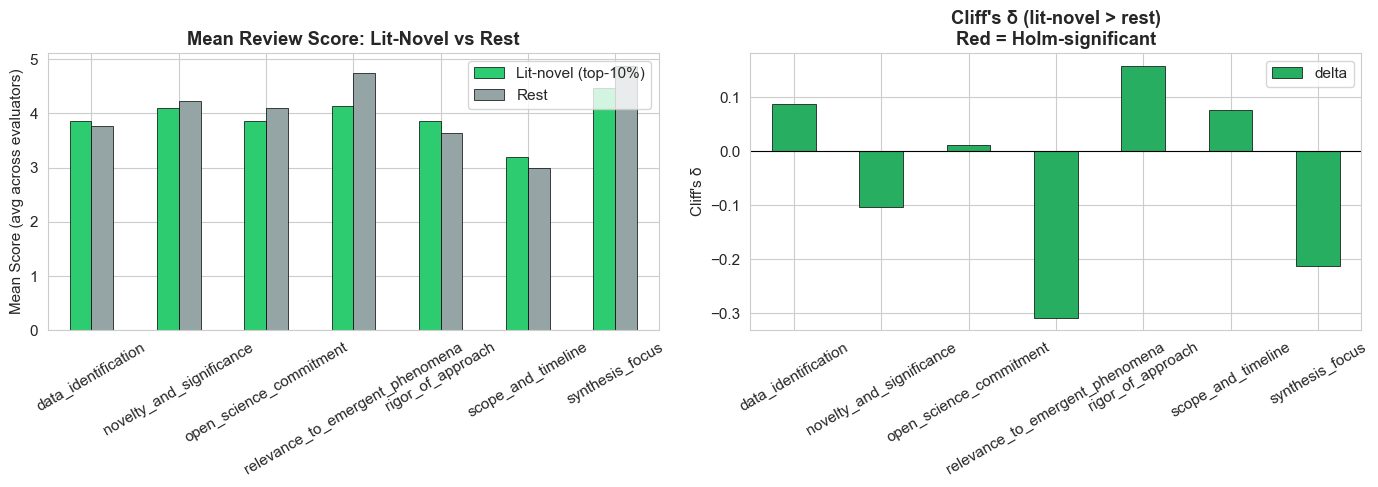

Saved results/figures/baseline/lit_novel_score_comparison_33b.png


In [67]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def cliffs_delta_simple(x, y):
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
    return dom / (len(x) * len(y))

tables = BASELINE_TABLES_DIR
nov_df = pd.read_csv(tables / 'novelty_scores_from_literature.csv')
scores_df = pd.read_csv(tables / 'review_scores_wide.csv')

def norm(s):
    return str(s).strip().lower()

nov_df['title_norm'] = nov_df['title'].map(norm)
scores_df['title_norm'] = scores_df['title'].map(norm)
score_cols_local = [c for c in scores_df.columns if c not in {'title', 'title_norm', 'author'}]
merged_33b = nov_df[['title_norm', 'raw_novelty', 'is_most_novel_raw']].merge(scores_df[['title_norm'] + score_cols_local], on='title_norm', how='inner')
n_novel = int(merged_33b['is_most_novel_raw'].sum())
print(f"Matched proposals: {len(merged_33b)}  |  Lit-most-novel (top-10%): {n_novel}")
lit_threshold = np.percentile(nov_df['raw_novelty'], 90)
print(f"Novelty threshold (90th pct): {lit_threshold:.4f}\n")

novelty_col = next((c for c in score_cols_local if 'novelty' in c.lower()), None)
if novelty_col:
    print(f"Key criterion to watch: '{novelty_col}'\n")

if n_novel < 2:
    print('⚠️ Fewer than 2 literature-most-novel proposals in merged set; cannot run test.')
else:
    print('=' * 70)
    print('ANALYSIS 5.3b: LIT-NOVEL (top-10%) vs REST — REVIEW SCORES')
    print("H1 (one-sided): literature-novel proposals score HIGHER (alternative='greater')")
    print('=' * 70)

    lit_results = []
    for criterion in score_cols_local:
        novel_scores = merged_33b.loc[merged_33b['is_most_novel_raw'], criterion].dropna()
        rest_scores = merged_33b.loc[~merged_33b['is_most_novel_raw'], criterion].dropna()
        if len(novel_scores) < 2 or len(rest_scores) < 2:
            continue
        u_stat, p_val = mannwhitneyu(novel_scores, rest_scores, alternative='greater')
        delta = cliffs_delta_simple(novel_scores, rest_scores)
        marker = '  <- NOVELTY CRITERION' if criterion == novelty_col else ''
        print(f"  {criterion:<42} novel={novel_scores.mean():.2f}  rest={rest_scores.mean():.2f}  δ={delta:+.3f}  p={p_val:.4f}{marker}")
        lit_results.append({
            'criterion': criterion,
            'novel_mean': novel_scores.mean(),
            'rest_mean': rest_scores.mean(),
            'delta': delta,
            'p_value': p_val,
            'n_novel': len(novel_scores),
            'n_rest': len(rest_scores),
        })

    if lit_results:
        lit_df = pd.DataFrame(lit_results)
        _, lit_df['p_holm'], _, _ = multipletests(lit_df['p_value'], method='holm')
        lit_df.to_csv(tables / 'lit_novel_score_comparison_33b.csv', index=False)
        print('\nSaved lit_novel_score_comparison_33b.csv')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        lit_df.plot(x='criterion', y=['novel_mean', 'rest_mean'], kind='bar', ax=axes[0], color=['#2ECC71', '#95A5A6'], edgecolor='black', linewidth=0.5)
        axes[0].set_title('Mean Review Score: Lit-Novel vs Rest', fontweight='bold')
        axes[0].set_xlabel('')
        axes[0].set_ylabel('Mean Score (avg across evaluators)')
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].legend(['Lit-novel (top-10%)', 'Rest'])

        colors_33b = ['#E74C3C' if sig else '#27AE60' for sig in (lit_df['p_holm'] < 0.05)]
        lit_df.plot(x='criterion', y='delta', kind='bar', ax=axes[1], color=colors_33b, edgecolor='black', linewidth=0.5)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_title("Cliff's δ (lit-novel > rest)\nRed = Holm-significant", fontweight='bold')
        axes[1].set_xlabel('')
        axes[1].set_ylabel("Cliff's δ")
        axes[1].tick_params(axis='x', rotation=30)
        plt.tight_layout()
        out_path = BASELINE_FIGURES_DIR / 'lit_novel_score_comparison_33b.png'
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved {out_path}")


---
## Analysis 5.4: Human vs AI Outlier Comparison

Among outlier proposals only, compare novelty-related review scores between human and AI outliers and compute within-group NN-distance correlations.


Using criterion: novelty_and_significance

=== Among outlier proposals: Human vs AI Novelty & Significance ===
  Human outliers  n=3  mean=4.00
  AI outliers     n=7  mean=3.90
  Mann-Whitney U=14  p=0.4132  Cliff's δ=+0.286

=== Spearman: NN distance ~ Novelty score by group ===
  Human                     n=23  r=-0.322  p=0.1338
  gpt-5.2                   n=23  r=-0.299  p=0.1651
  gemini-3-pro-preview      n=23  r=-0.137  p=0.5323
  claude-opus-4-5           n=23  r=-0.762  p=0.0000

Saved nn_novelty_correlation_by_group.csv


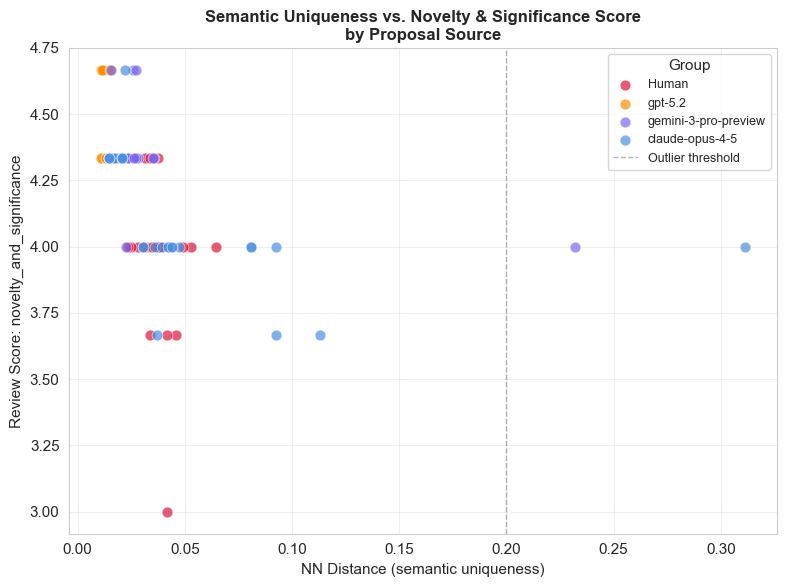

Saved results/figures/baseline/nn_dist_vs_novelty_score.png


In [68]:
from scipy.stats import mannwhitneyu
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'merged' not in globals():
    raise RuntimeError("Run Analysis 5.1 first to build 'merged'.")
if 'cliffs_delta_simple' not in globals():
    def cliffs_delta_simple(x, y):
        x, y = np.asarray(x), np.asarray(y)
        dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
        return dom / (len(x) * len(y))

novelty_col = next((c for c in score_cols if 'novelty' in c.lower()), None)
if not novelty_col:
    print("Could not find 'Novelty' column. Available:", score_cols)
else:
    print(f"Using criterion: {novelty_col}\n")
    outliers_only = merged[merged['is_outlier']].copy()
    outliers_only['is_human'] = outliers_only['group'].str.lower().str.startswith('human')
    human_scores = outliers_only.loc[outliers_only['is_human'], novelty_col].dropna()
    ai_scores = outliers_only.loc[~outliers_only['is_human'], novelty_col].dropna()

    print('=== Among outlier proposals: Human vs AI Novelty & Significance ===')
    print(f"  Human outliers  n={len(human_scores)}  mean={human_scores.mean():.2f}" if len(human_scores) else '  No human outliers.')
    print(f"  AI outliers     n={len(ai_scores)}  mean={ai_scores.mean():.2f}" if len(ai_scores) else '  No AI outliers.')
    if len(human_scores) >= 2 and len(ai_scores) >= 2:
        u_stat, p_val = mannwhitneyu(human_scores, ai_scores, alternative='two-sided')
        delta = cliffs_delta_simple(human_scores, ai_scores)
        print(f"  Mann-Whitney U={u_stat:.0f}  p={p_val:.4f}  Cliff's δ={delta:+.3f}")

    print('\n=== Spearman: NN distance ~ Novelty score by group ===')
    group_corr_rows = []
    for grp in merged['group'].unique():
        subset = merged[merged['group'] == grp][[novelty_col, 'nn_dist']].dropna()
        if len(subset) < 4:
            continue
        r, p = stats.spearmanr(subset['nn_dist'], subset[novelty_col])
        group_corr_rows.append({'group': grp, 'n': len(subset), 'r': r, 'p': p})
        print(f"  {grp:<25} n={len(subset):2d}  r={r:+.3f}  p={p:.4f}")
    pd.DataFrame(group_corr_rows).to_csv((BASELINE_TABLES_DIR) / 'nn_novelty_correlation_by_group.csv', index=False)
    print('\nSaved nn_novelty_correlation_by_group.csv')

    group_colors = {'Human': '#DC143C', 'human-y1': '#DC143C', 'human-y2': '#DC143C', 'claude-opus-4-5': '#4A90E2', 'gemini-3-pro-preview': '#7B68EE', 'gpt-5.2': '#FF8C00'}
    fig, ax = plt.subplots(figsize=(8, 6))
    for grp in merged['group'].unique():
        subset = merged[merged['group'] == grp]
        ax.scatter(subset['nn_dist'], subset[novelty_col], color=group_colors.get(grp, 'gray'), label='Human' if 'human' in grp.lower() else grp, alpha=0.7, edgecolors='white', linewidth=0.5, s=60)
    ax.axvline(merged['threshold'].iloc[0], color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Outlier threshold')
    ax.set_xlabel('NN Distance (semantic uniqueness)', fontsize=11)
    ax.set_ylabel(f'Review Score: {novelty_col}', fontsize=11)
    ax.set_title('Semantic Uniqueness vs. Novelty & Significance Score\nby Proposal Source', fontsize=12, fontweight='bold')
    ax.legend(title='Group', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    out_path = BASELINE_FIGURES_DIR / 'nn_dist_vs_novelty_score.png'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {out_path}")


---
## Analysis 5.5: NN Outliers vs Literature-Most-Novel Proposals

Compare within-corpus NN outliers to proposals that are most novel relative to the literature corpus.


Merged rows: 92
OVERLAP: NN OUTLIERS (within-corpus) vs MOST NOVEL (vs literature)
  NN outliers:                     10 proposals
  Most novel vs literature:       10 proposals
  Shared:                          1 proposals
  Jaccard similarity:            0.053

Proposals in BOTH sets:
                           title_norm group  nn_dist  raw_novelty  novelty_z
cytokinetic bottlenecks of heat waves Human  0.06456     0.236753   2.076972

NN outliers NOT in top-10% lit-novelty:
                                                                                                                                title_norm                group  nn_dist  raw_novelty  novelty_z
    emergent mechanics of bacterial microcompartments: synthesizing structural and metabolic data to model encapsulated pathway efficiency      claude-opus-4-5 0.311175     0.157741   0.801953
                                          the emergence of metabolic channeling: mapping transient metabolons via integrated inter

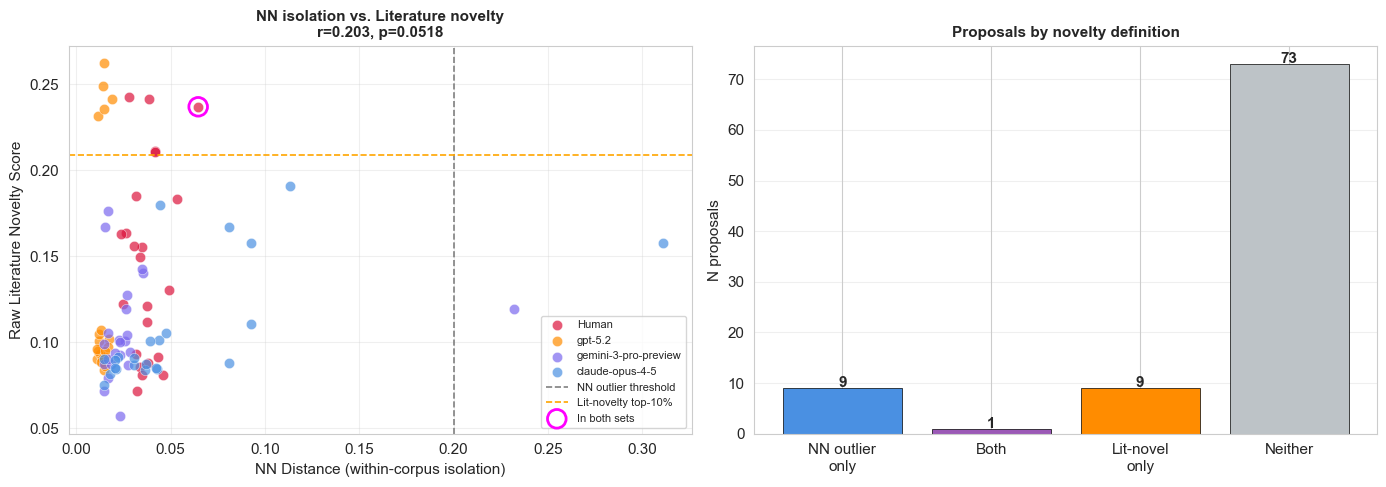

Saved results/figures/baseline/nn_vs_lit_novelty_overlap.png


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


tables = BASELINE_TABLES_DIR

nn_df = pd.read_csv(tables / 'nn_distances.csv')
nov_df = pd.read_csv(tables / 'novelty_scores_from_literature.csv')
scores_df = pd.read_csv(tables / 'review_scores_wide.csv')

def norm(s):
    return str(s).strip().lower()

for df in [nn_df, nov_df, scores_df]:
    df['title_norm'] = df['title'].map(norm)

score_cols = [c for c in scores_df.columns if c not in {'title', 'title_norm', 'author'}]
merged = (
    nn_df[['title_norm', 'group', 'nn_dist', 'is_outlier', 'threshold']]
    .merge(nov_df[['title_norm', 'raw_novelty', 'novelty_z', 'novelty_ratio', 'is_most_novel_raw', 'is_most_novel_z']], on='title_norm', how='left')
    .merge(scores_df[['title_norm'] + score_cols], on='title_norm', how='inner')
)
print(f"Merged rows: {len(merged)}")

nn_set = set(merged.loc[merged['is_outlier'], 'title_norm'])
lit_set = set(merged.loc[merged['is_most_novel_raw'], 'title_norm'])
overlap = nn_set & lit_set
jaccard = len(overlap) / len(nn_set | lit_set) if (nn_set | lit_set) else 0

print('=' * 70)
print('OVERLAP: NN OUTLIERS (within-corpus) vs MOST NOVEL (vs literature)')
print('=' * 70)
print(f"  NN outliers:                    {len(nn_set):3d} proposals")
print(f"  Most novel vs literature:      {len(lit_set):3d} proposals")
print(f"  Shared:                        {len(overlap):3d} proposals")
print(f"  Jaccard similarity:            {jaccard:.3f}")
print()

if overlap:
    both = merged[merged['title_norm'].isin(overlap)][['title_norm', 'group', 'nn_dist', 'raw_novelty', 'novelty_z']].sort_values('raw_novelty', ascending=False)
    print('Proposals in BOTH sets:')
    print(both.to_string(index=False))
else:
    print('No overlap — the two definitions identify different proposals.')
print()

only_nn = merged[merged['is_outlier'] & ~merged['is_most_novel_raw']][['title_norm', 'group', 'nn_dist', 'raw_novelty', 'novelty_z']].sort_values('nn_dist', ascending=False)
only_lit = merged[~merged['is_outlier'] & merged['is_most_novel_raw']][['title_norm', 'group', 'nn_dist', 'raw_novelty', 'novelty_z']].sort_values('raw_novelty', ascending=False)
print('NN outliers NOT in top-10% lit-novelty:')
print(only_nn.to_string(index=False))
print()
print('Top-10% lit-novelty NOT in NN outliers:')
print(only_lit.to_string(index=False))

r, p = spearmanr(merged['nn_dist'], merged['raw_novelty'])
print(f"\nSpearman(nn_dist, raw_novelty): r={r:.3f}, p={p:.4f}")
print('  -> If low/non-significant, the two novelty metrics are measuring different things.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
group_colors = {'Human': '#DC143C', 'human-y1': '#DC143C', 'human-y2': '#DC143C', 'claude-opus-4-5': '#4A90E2', 'gemini-3-pro-preview': '#7B68EE', 'gpt-5.2': '#FF8C00'}
for grp in merged['group'].unique():
    subset = merged[merged['group'] == grp]
    axes[0].scatter(subset['nn_dist'], subset['raw_novelty'], color=group_colors.get(grp, 'gray'), label='Human' if 'human' in grp.lower() else grp, alpha=0.7, s=55, edgecolors='white', linewidth=0.4)

threshold_val = merged['threshold'].iloc[0]
lit_thresh = np.percentile(merged['raw_novelty'], 90)
axes[0].axvline(threshold_val, color='gray', linestyle='--', lw=1.2, label='NN outlier threshold')
axes[0].axhline(lit_thresh, color='orange', linestyle='--', lw=1.2, label='Lit-novelty top-10%')
if overlap:
    ov_pts = merged[merged['title_norm'].isin(overlap)]
    axes[0].scatter(ov_pts['nn_dist'], ov_pts['raw_novelty'], s=180, facecolors='none', edgecolors='magenta', linewidth=2, zorder=10, label='In both sets')
axes[0].set_xlabel('NN Distance (within-corpus isolation)', fontsize=11)
axes[0].set_ylabel('Raw Literature Novelty Score', fontsize=11)
axes[0].set_title(f'NN isolation vs. Literature novelty\nr={r:.3f}, p={p:.4f}', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

cats = ['NN outlier\nonly', 'Both', 'Lit-novel\nonly', 'Neither']
counts = [len(only_nn), len(overlap), len(only_lit), len(merged) - len(nn_set | lit_set)]
bars = axes[1].bar(cats, counts, color=['#4A90E2', '#9B59B6', '#FF8C00', '#BDC3C7'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Proposals by novelty definition', fontsize=11, fontweight='bold')
axes[1].set_ylabel('N proposals')
axes[1].grid(alpha=0.3, axis='y')
for bar, value in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.15, str(value), ha='center', fontweight='bold')

plt.tight_layout()
out_path = BASELINE_FIGURES_DIR / 'nn_vs_lit_novelty_overlap.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {out_path}")


In [70]:
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np


tables = BASELINE_TABLES_DIR

if 'merged' not in globals():
    raise RuntimeError("Run Analysis 5.5 first to build 'merged'.")


def cliffs_delta_simple(x, y):
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
    return dom / (len(x) * len(y))

print('=' * 70)
print('(5.5a) REVIEW SCORES: LIT-MOST-NOVEL vs REST')
print("(same test as 5.3 but using literature-based novelty top-10%)")
print('=' * 70)
lit_results = []
for criterion in score_cols:
    novel_scores = merged.loc[merged['is_most_novel_raw'], criterion].dropna()
    rest_scores = merged.loc[~merged['is_most_novel_raw'], criterion].dropna()
    if len(novel_scores) < 2 or len(rest_scores) < 2:
        continue
    u_stat, p_val = mannwhitneyu(novel_scores, rest_scores, alternative='greater')
    delta = cliffs_delta_simple(novel_scores, rest_scores)
    lit_results.append({'criterion': criterion, 'novel_mean': novel_scores.mean(), 'rest_mean': rest_scores.mean(), 'delta': delta, 'p_value': p_val, 'n_novel': len(novel_scores), 'n_rest': len(rest_scores)})

lit_df = pd.DataFrame(lit_results)
if not lit_df.empty:
    _, lit_df['p_holm'], _, _ = multipletests(lit_df['p_value'], method='holm')
    print(lit_df[['criterion', 'novel_mean', 'rest_mean', 'delta', 'p_value', 'p_holm']].to_string(index=False))
    lit_df.to_csv(tables / 'lit_novel_score_comparison.csv', index=False)
    print('\nSaved lit_novel_score_comparison.csv')

print('\n' + '=' * 70)
print('(5.5b) SPEARMAN: RAW LIT-NOVELTY SCORE vs EACH REVIEW CRITERION')
print('=' * 70)
corr_rows = []
for criterion in score_cols:
    valid = merged[['raw_novelty', criterion]].dropna()
    if len(valid) < 5:
        continue
    r, p = spearmanr(valid['raw_novelty'], valid[criterion])
    corr_rows.append({'criterion': criterion, 'r': r, 'p': p})
    print(f"  {criterion:<42} r={r:+.3f}  p={p:.4f}")

corr_df = pd.DataFrame(corr_rows)
if not corr_df.empty:
    _, corr_df['p_holm'], _, _ = multipletests(corr_df['p'], method='holm')
    corr_df.to_csv(tables / 'lit_novelty_score_correlations.csv', index=False)
    print('\nSaved lit_novelty_score_correlations.csv')


(5.5a) REVIEW SCORES: LIT-MOST-NOVEL vs REST
(same test as 5.3 but using literature-based novelty top-10%)
                      criterion  novel_mean  rest_mean     delta  p_value  p_holm
            data_identification    3.866667   3.760163  0.087805 0.322766     1.0
       novelty_and_significance    4.100000   4.223577 -0.103659 0.720774     1.0
        open_science_commitment    3.866667   4.089431  0.012195 0.476877     1.0
relevance_to_emergent_phenomena    4.133333   4.752033 -0.308537 0.984911     1.0
              rigor_of_approach    3.866667   3.634146  0.158537 0.200959     1.0
             scope_and_timeline    3.200000   2.995935  0.075610 0.332829     1.0
                synthesis_focus    4.466667   4.865854 -0.212195 0.932630     1.0

Saved lit_novel_score_comparison.csv

(5.5b) SPEARMAN: RAW LIT-NOVELTY SCORE vs EACH REVIEW CRITERION
  data_identification                        r=-0.156  p=0.1371
  novelty_and_significance                   r=-0.100  p=0.3409
  open

---
## Analysis 5.6: Export Full Proposals for NN Outliers and Literature-Most-Novel Proposals


In [71]:
import json
import pandas as pd
import numpy as np
from pathlib import Path


tables = BASELINE_TABLES_DIR
out_dir = tables
nov_df = pd.read_csv(tables / 'novelty_scores_from_literature.csv')
nn_df = pd.read_csv(tables / 'nn_distances.csv')
scores_wide = pd.read_csv(tables / 'review_scores_wide.csv')

def norm(s):
    return str(s).strip().lower()

for df in [nov_df, nn_df, scores_wide]:
    df['title_norm'] = df['title'].map(norm)

score_cols_local = [c for c in scores_wide.columns if c not in {'title', 'title_norm', 'author'}]
combined = nn_df[['title_norm', 'group', 'nn_dist', 'is_outlier', 'threshold']].merge(
    nov_df[['title_norm', 'raw_novelty', 'novelty_z', 'novelty_ratio', 'is_most_novel_raw', 'is_most_novel_z']],
    on='title_norm',
    how='left'
)

target_norms = set(combined.loc[combined['is_outlier'] | combined['is_most_novel_raw'], 'title_norm'])
print(f"Target proposals (NN outlier OR lit-most-novel): {len(target_norms)}")

review_dir = Path('data/reviews/ai_reviews')
review_files = sorted(review_dir.glob('ai_reviews_ncems_criteria_*.json'))
if not review_files:
    raise FileNotFoundError('No baseline review files found.')
with open(review_files[-1]) as f:
    reviews_raw = json.load(f)['reviews']

review_lookup = {}
for entry in reviews_raw:
    title_norm = norm(entry.get('title', ''))
    evaluator = entry.get('evaluator', '')
    evaluation = entry.get('evaluations', {}).get('evaluation', {})
    criteria = [
        {
            'category': cat['category'],
            'criterion': sub['criterion'],
            'score': sub['score'],
            'justification': sub.get('justification', ''),
        }
        for cat in evaluation.get('criteria_scores', [])
        for sub in cat.get('subcriteria', [])
    ]
    review_lookup.setdefault(title_norm, []).append({'evaluator': evaluator, 'criteria': criteria})

human_orig = {}
for cohort, filename in [('y1', 'human-proposals-y1.json'), ('y2', 'human-proposals-y2.json')]:
    fpath = Path('data/human-proposals') / filename
    if not fpath.exists():
        continue
    with open(fpath) as f:
        for proposal in json.load(f).get('proposals', []):
            human_orig[norm(proposal.get('proposal_title', ''))] = {'cohort': cohort, **proposal}

ai_baseline_path = sorted(Path('data/ai-proposals/baseline').glob('ai_proposals_baseline_complete_*.csv'))[-1]
ai_df_export = pd.read_csv(ai_baseline_path)
ai_df_export['title_norm'] = ai_df_export['title'].map(norm)

output_records = []
for _, row in combined.iterrows():
    title_norm = row['title_norm']
    if title_norm not in target_norms:
        continue

    group_label = row['group']
    record = {
        'title_norm': title_norm,
        'group': group_label,
        'is_nn_outlier': bool(row['is_outlier']),
        'is_lit_most_novel': bool(row['is_most_novel_raw']),
        'nn_dist': float(row['nn_dist']) if pd.notna(row['nn_dist']) else None,
        'raw_novelty': float(row['raw_novelty']) if pd.notna(row['raw_novelty']) else None,
        'novelty_z': float(row['novelty_z']) if pd.notna(row['novelty_z']) else None,
        'novelty_ratio': float(row['novelty_ratio']) if pd.notna(row['novelty_ratio']) else None,
    }

    if 'human' in str(group_label).lower():
        original = human_orig.get(title_norm, {})
        record.update({
            'title': original.get('proposal_title', title_norm),
            'author': group_label,
            'authors': original.get('authors', []),
            'authors_departments': original.get('authors_departments', ''),
            'proposal_status': original.get('proposal_status', ''),
            'ranking': original.get('ranking', None),
            'abstract_original': original.get('abstract', ''),
            'full_draft_original': original.get('full_draft', ''),
        })
    else:
        ai_match = ai_df_export[ai_df_export['title_norm'] == title_norm]
        if not ai_match.empty:
            proposal = ai_match.iloc[0]
            full_sections = [
                f"Title: {proposal.get('title', '')}",
                f"Abstract: {proposal.get('abstract', '')}",
                f"Background: {proposal.get('background_and_significance', '')}",
                f"Research Questions: {proposal.get('research_questions_and_hypotheses', '')}",
                f"Methods: {proposal.get('methods_and_approach', '')}",
                f"Expected Outcomes: {proposal.get('expected_outcomes_and_impact', '')}",
                f"Budget and Resources: {proposal.get('budget_and_resources', '')}",
            ]
            record.update({
                'title': proposal.get('title', title_norm),
                'author': proposal.get('model', group_label),
                'authors': [proposal.get('model', group_label)],
                'abstract_original': str(proposal.get('abstract', '')),
                'full_draft_original': '\n\n'.join(part for part in full_sections if part.split(': ', 1)[-1]),
            })
        else:
            record.update({'title': title_norm, 'author': group_label, 'authors': [group_label]})

    record['ai_reviews'] = review_lookup.get(title_norm, [])
    score_row = scores_wide[scores_wide['title_norm'] == title_norm]
    record['avg_review_scores'] = (
        {col: (float(score_row.iloc[0][col]) if pd.notna(score_row.iloc[0][col]) else None) for col in score_cols_local}
        if not score_row.empty else {}
    )
    output_records.append(record)

output_records.sort(key=lambda rec: -(rec['raw_novelty'] or 0))
out_path = out_dir / 'outlier_and_novel_proposals.json'
with open(out_path, 'w') as f:
    json.dump(output_records, f, indent=2, ensure_ascii=False)

print(f"Saved {len(output_records)} proposals -> {out_path.name}")
for rec in output_records:
    tag = 'NN+LIT' if rec['is_nn_outlier'] and rec['is_lit_most_novel'] else 'NN only' if rec['is_nn_outlier'] else 'LIT only'
    print(f"  {tag:<8}  {rec['group']:<25}  z={rec['novelty_z'] or 0:+.2f}  nn={rec['nn_dist'] or 0:.4f}  {rec.get('title', '')[:55]}")


Target proposals (NN outlier OR lit-most-novel): 19
Saved 19 proposals -> outlier_and_novel_proposals.json
  LIT only  gpt-5.2                    z=+2.49  nn=0.0144  Emergent Chromatin Nanodomain Topology: Integrating Hi-
  LIT only  gpt-5.2                    z=+2.27  nn=0.0140  A Cross-Cell-Type Atlas of Biomolecular Condensate Mate
  LIT only  Human                      z=+2.17  nn=0.0279  Emergent Order Parameters of Allostery: An AI Framework
  LIT only  Human                      z=+2.15  nn=0.0387  Energetic Origins of Connectivity within Protein Intera
  LIT only  gpt-5.2                    z=+2.15  nn=0.0191  Mesoscale Assembly of Viral Replication Compartments: A
  NN+LIT    Human                      z=+2.08  nn=0.0646  CYTOKINETIC BOTTLENECKS OF HEAT WAVES
  LIT only  gpt-5.2                    z=+2.05  nn=0.0145  Emergent Ribosome Assembly Landscapes: Integrating Cryo
  LIT only  gpt-5.2                    z=+1.99  nn=0.0114  Protein Crowding as an Emergent Mesoscale Regul